In [1]:
from pathlib import Path
import pandas as pd
import numpy as np

# Project paths
PROJECT_ROOT = Path.cwd().resolve().parent
DATA_DIR = PROJECT_ROOT / "data" / "raw"

print("Current working directory:", Path.cwd())
print("Project root:", PROJECT_ROOT)
print("Data directory:", DATA_DIR)
print("CSV files found:", len(list(DATA_DIR.glob("*.csv"))))

Current working directory: /Users/krith/Documents/credresolve-data-analyst-assignment/notebooks
Project root: /Users/krith/Documents/credresolve-data-analyst-assignment
Data directory: /Users/krith/Documents/credresolve-data-analyst-assignment/data/raw
CSV files found: 18


In [2]:
# Find all CSV files
csv_files = sorted(DATA_DIR.glob("*.csv"))

print(f"Total CSV files: {len(csv_files)}")
print("\nFiles found:")

for file in csv_files:
    print("-", file.name)

Total CSV files: 18

Files found:
- account_status_history.csv
- accounts.csv
- agent_sessions.csv
- agents.csv
- borrowers.csv
- call_attempts.csv
- call_dispositions.csv
- calls.csv
- campaigns.csv
- complaints.csv
- daily_targeting.csv
- data_dictionary.csv
- field_visits.csv
- payments.csv
- promises_to_pay.csv
- sms_events.csv
- vendor_telephony.csv
- whatsapp_events.csv


In [3]:
# Load all datasets into a dictionary

datasets = {}

for file in csv_files:
    table_name = file.stem
    
    try:
        df = pd.read_csv(file)
        datasets[table_name] = df
        
        print(
            f"Loaded: {table_name:<30} "
            f"Rows: {df.shape[0]:>8,} | "
            f"Columns: {df.shape[1]:>3}"
        )
        
    except Exception as e:
        print(f"ERROR loading {file.name}: {e}")

Loaded: account_status_history         Rows:   60,000 | Columns:   8
Loaded: accounts                       Rows:   30,000 | Columns:  11
Loaded: agent_sessions                 Rows:   15,000 | Columns:   7
Loaded: agents                         Rows:   30,000 | Columns:   8
Loaded: borrowers                      Rows:   30,600 | Columns:   8
Loaded: call_attempts                  Rows:  120,000 | Columns:   9
Loaded: call_dispositions              Rows:   35,000 | Columns:   8
Loaded: calls                          Rows:   91,350 | Columns:  11
Loaded: campaigns                      Rows:      120 | Columns:   7
Loaded: complaints                     Rows:    8,000 | Columns:   9
Loaded: daily_targeting                Rows:   45,000 | Columns:   7
Loaded: data_dictionary                Rows:      143 | Columns:   3
Loaded: field_visits                   Rows:   25,000 | Columns:  10
Loaded: payments                       Rows:   25,500 | Columns:   9
Loaded: promises_to_pay           

In [4]:
inventory = []

for table_name, df in datasets.items():
    inventory.append({
        "table_name": table_name,
        "rows": df.shape[0],
        "columns": df.shape[1],
        "missing_values": int(df.isna().sum().sum()),
        "duplicate_rows": int(df.duplicated().sum())
    })

inventory_df = pd.DataFrame(inventory).sort_values(
    "rows",
    ascending=False
).reset_index(drop=True)

inventory_df

,table_name,rows,columns,missing_values,duplicate_rows
0,call_attempts,120000,9,2400,0
1,calls,91350,11,1827,1271
2,whatsapp_events,60600,8,0,600
3,account_status_history,60000,8,0,0
4,daily_targeting,45000,7,0,0
5,sms_events,45000,8,0,0
6,call_dispositions,35000,8,0,0
7,borrowers,30600,8,1509,600
8,agents,30000,8,0,0
9,accounts,30000,11,455,0


In [5]:
# Inspect all datasets: columns, data types and sample records

for table_name, df in datasets.items():
    print("\n" + "=" * 100)
    print(f"TABLE: {table_name.upper()}")
    print("=" * 100)
    
    print("\nColumns:")
    print(list(df.columns))
    
    print("\nData Types:")
    print(df.dtypes)
    
    print("\nSample Records:")
    display(df.head(3))


TABLE: ACCOUNT_STATUS_HISTORY

Columns:
['history_id', 'account_id', 'borrower_id', 'event_at', 'status', 'changed_by', 'source', 'recorded_at']

Data Types:
history_id     str
account_id     str
borrower_id    str
event_at       str
status         str
changed_by     str
source         str
recorded_at    str
dtype: object

Sample Records:


,history_id,account_id,borrower_id,event_at,status,changed_by,source,recorded_at
0,HISTORY0000001,ACC0004322,BRW0005490,2026-07-03 04:28:38,WRITEOFF,AGT0000039,CALL,2026-07-03 00:41:54
1,HISTORY0000002,ACC0024644,BRW0005343,2026-07-18 02:03:23,DELINQUENT,AGT0000059,CALL,2026-07-18 22:42:02
2,HISTORY0000003,ACC0020233,BRW0003150,2026-04-15 09:17:47,CLOSED,AGT0000080,PAYMENT,2026-04-15 19:40:51



TABLE: ACCOUNTS

Columns:
['account_id', 'borrower_id', 'loan_type', 'principal_amount', 'outstanding_amount', 'dpd', 'risk_segment', 'status', 'opened_at', 'timezone', 'schema_version']

Data Types:
account_id                str
borrower_id               str
loan_type                 str
principal_amount      float64
outstanding_amount    float64
dpd                     int64
risk_segment              str
status                    str
opened_at                 str
timezone                  str
schema_version            str
dtype: object

Sample Records:


,account_id,borrower_id,loan_type,principal_amount,outstanding_amount,dpd,risk_segment,status,opened_at,timezone,schema_version
0,ACC0000001,BRW0010742,CONSUMER,603443.40,678074.03,15,MEDIUM,CLOSED,2025-11-11 04:37:00,Asia/Dubai,v1
1,ACC0000002,BRW0009382,BNPL,277190.14,464893.44,5,LOW,ACTIVE,2025-11-13 15:59:44,UTC,v3
2,ACC0000003,BRW0003966,CREDIT_CARD,628658.43,22565.37,60,NPA,WRITEOFF,2025-09-12 04:59:20,Asia/Dubai,v2



TABLE: AGENT_SESSIONS

Columns:
['session_id', 'agent_id', 'login_at', 'channel', 'device_id', 'timezone', 'logout_at']

Data Types:
session_id    str
agent_id      str
login_at      str
channel       str
device_id     str
timezone      str
logout_at     str
dtype: object

Sample Records:


...

,sms_event_id,account_id,borrower_id,event_at,message_id,event_type,template_code,provider_id
0,SMS_EVENT0000001,ACC0010751,BRW0009574,2026-04-24 20:57:06,SMS000022764,CLICKED,PAYMENT_LINK,VND0000010
1,SMS_EVENT0000002,ACC0005842,BRW0003619,2026-05-24 11:28:20,SMS000015050,DELIVERED,NOTICE,VND0000003
2,SMS_EVENT0000003,ACC0014253,BRW0003018,2026-03-05 20:23:20,SMS000028337,CLICKED,NOTICE,VND0000008



TABLE: VENDOR_TELEPHONY

Columns:
['vendor_id', 'vendor_name', 'vendor_account_id', 'timezone', 'status', 'schema_version']

Data Types:
vendor_id            str
vendor_name          str
vendor_account_id    str
timezone             str
status               str
schema_version       str
dtype: object

Sample Records:


,vendor_id,vendor_name,vendor_account_id,timezone,status,schema_version
0,VND0000001,Airtel,VAC342762,Asia/Kolkata,INACTIVE,v3
1,VND0000002,Exotel,VAC456766,UTC,INACTIVE,v3
2,VND0000003,Twilio,VAC074211,UTC,INACTIVE,v3



TABLE: WHATSAPP_EVENTS

Columns:
['whatsapp_event_id', 'account_id', 'borrower_id', 'event_at', 'message_id', 'event_type', 'template_code', 'provider_id']

Data Types:
whatsapp_event_id    str
account_id           str
borrower_id          str
event_at             str
message_id           str
event_type           str
template_code        str
provider_id          str
dtype: object

Sample Records:


,whatsapp_event_id,account_id,borrower_id,event_at,message_id,event_type,template_code,provider_id
0,WHATSAPP_EVENT0000001,ACC0006134,BRW0007859,2026-02-27 17:49:38,MSG000008171,FAILED,FIELD_VISIT,VND0000008
1,WHATSAPP_EVENT0000002,ACC0027479,BRW0003963,2026-02-09 11:55:18,MSG000000667,FAILED,PTP_01,VND0000003
2,WHATSAPP_EVENT0000003,ACC0008356,BRW0008340,2026-07-08 05:16:13,MSG000023608,DELIVERED,PAYMENT_LINK,VND0000001


In [6]:
display(datasets["data_dictionary"])

,dataset,column,dtype
0,borrowers,borrower_id,object
1,borrowers,name,object
2,borrowers,phone,object
3,borrowers,email,object
4,borrowers,city,object
...,...,...,...
138,account_status_history,event_at,datetime64[ns]
139,account_status_history,status,object
140,account_status_history,changed_by,object
141,account_status_history,source,object


In [7]:
# Inspect key datasets in detail

key_tables = [
    "borrowers",
    "accounts",
    "payments",
    "calls",
    "call_attempts",
    "daily_targeting",
    "campaigns",
    "field_visits",
    "promises_to_pay",
    "sms_events",
    "whatsapp_events",
    "account_status_history"
]

for table in key_tables:
    if table in datasets:
        df = datasets[table]

        print("\n" + "=" * 100)
        print(f"TABLE: {table.upper()} | Shape: {df.shape}")
        print("=" * 100)

        print("\nColumns:")
        print(df.columns.tolist())

        print("\nSample data:")
        display(df.head(5))


TABLE: BORROWERS | Shape: (30600, 8)

Columns:
['borrower_id', 'name', 'phone', 'email', 'city', 'created_at', 'updated_at', 'state']

Sample data:


,borrower_id,name,phone,email,city,created_at,updated_at,state
0,BRW0001072,Rahul Verma,9.037419e+09,user9183@example.com,Bhubaneswar,2025-09-25 08:02:29,2026-07-25 22:25:48,Odisha
1,BRW0009288,Neha Singh,9.154913e+09,user9581@example.com,Gurugram,2025-06-29 04:32:01,2025-03-04 12:15:30,Haryana
2,BRW0007855,Vikram Shah,9.986755e+09,user19407@example.com,Hyderabad,2025-11-23 20:30:50,2025-01-07 21:07:17,Telangana
3,BRW0005267,Priya Mehta,9.145160e+09,user4619@example.com,Jaipur,2026-05-09 11:34:12,2025-04-24 21:35:48,Rajasthan
4,BRW0005197,Priya Mehta,9.655567e+09,user4597@example.com,Mumbai,2025-02-13 03:53:20,2026-03-29 19:42:02,Maharashtra



TABLE: ACCOUNTS | Shape: (30000, 11)

Columns:
['account_id', 'borrower_id', 'loan_type', 'principal_amount', 'outstanding_amount', 'dpd', 'risk_segment', 'status', 'opened_at', 'timezone', 'schema_version']

Sample data:


,account_id,borrower_id,loan_type,principal_amount,outstanding_amount,dpd,risk_segment,status,opened_at,timezone,schema_version
0,ACC0000001,BRW0010742,CONSUMER,603443.40,678074.03,15,MEDIUM,CLOSED,2025-11-11 04:37:00,Asia/Dubai,v1
1,ACC0000002,BRW0009382,BNPL,277190.14,464893.44,5,LOW,ACTIVE,2025-11-13 15:59:44,UTC,v3
2,ACC0000003,BRW0003966,CREDIT_CARD,628658.43,22565.37,60,NPA,WRITEOFF,2025-09-12 04:59:20,Asia/Dubai,v2
3,ACC0000004,BRW0001993,PERSONAL,76435.07,508427.73,30,LOW,CLOSED,2025-05-25 19:29:38,UTC,v2
4,ACC0000005,BRW0009976,CONSUMER,646797.08,563858.01,180,LOW,WRITEOFF,2025-09-07 14:59:13,Asia/Dubai,v2



TABLE: PAYMENTS | Shape: (25500, 9)

Columns:
['payment_id', 'account_id', 'borrower_id', 'event_at', 'payment_reference', 'amount', 'payment_status', 'payment_method', 'provider_id']

Sample data:


...

,sms_event_id,account_id,borrower_id,event_at,message_id,event_type,template_code,provider_id
0,SMS_EVENT0000001,ACC0010751,BRW0009574,2026-04-24 20:57:06,SMS000022764,CLICKED,PAYMENT_LINK,VND0000010
1,SMS_EVENT0000002,ACC0005842,BRW0003619,2026-05-24 11:28:20,SMS000015050,DELIVERED,NOTICE,VND0000003
2,SMS_EVENT0000003,ACC0014253,BRW0003018,2026-03-05 20:23:20,SMS000028337,CLICKED,NOTICE,VND0000008
3,SMS_EVENT0000004,ACC0016374,BRW0002587,2026-05-11 04:56:15,SMS000004875,DELIVERED,DUE_REMINDER,VND0000010
4,SMS_EVENT0000005,ACC0000796,BRW0010499,2026-03-24 08:41:53,SMS000008899,SENT,PTP_REMINDER,VND0000007



TABLE: WHATSAPP_EVENTS | Shape: (60600, 8)

Columns:
['whatsapp_event_id', 'account_id', 'borrower_id', 'event_at', 'message_id', 'event_type', 'template_code', 'provider_id']

Sample data:


,whatsapp_event_id,account_id,borrower_id,event_at,message_id,event_type,template_code,provider_id
0,WHATSAPP_EVENT0000001,ACC0006134,BRW0007859,2026-02-27 17:49:38,MSG000008171,FAILED,FIELD_VISIT,VND0000008
1,WHATSAPP_EVENT0000002,ACC0027479,BRW0003963,2026-02-09 11:55:18,MSG000000667,FAILED,PTP_01,VND0000003
2,WHATSAPP_EVENT0000003,ACC0008356,BRW0008340,2026-07-08 05:16:13,MSG000023608,DELIVERED,PAYMENT_LINK,VND0000001
3,WHATSAPP_EVENT0000004,ACC0024727,BRW0001572,2026-05-20 19:48:52,MSG000045438,DELIVERED,PAYMENT_LINK,VND0000010
4,WHATSAPP_EVENT0000005,ACC0024918,BRW0003130,2026-01-10 10:37:24,MSG000041041,READ,LEGAL_NOTICE,VND0000015



TABLE: ACCOUNT_STATUS_HISTORY | Shape: (60000, 8)

Columns:
['history_id', 'account_id', 'borrower_id', 'event_at', 'status', 'changed_by', 'source', 'recorded_at']

Sample data:


,history_id,account_id,borrower_id,event_at,status,changed_by,source,recorded_at
0,HISTORY0000001,ACC0004322,BRW0005490,2026-07-03 04:28:38,WRITEOFF,AGT0000039,CALL,2026-07-03 00:41:54
1,HISTORY0000002,ACC0024644,BRW0005343,2026-07-18 02:03:23,DELINQUENT,AGT0000059,CALL,2026-07-18 22:42:02
2,HISTORY0000003,ACC0020233,BRW0003150,2026-04-15 09:17:47,CLOSED,AGT0000080,PAYMENT,2026-04-15 19:40:51
3,HISTORY0000004,ACC0004384,BRW0008483,2026-01-16 10:52:04,WRITEOFF,SYSTEM,CORE,2026-01-16 23:05:28
4,HISTORY0000005,ACC0022967,BRW0009477,2026-05-22 04:13:04,PTP,AGT0000073,CORE,2026-05-22 07:08:28


In [8]:
# Inspect the most critical tables for recovery analysis

critical_tables = [
    "accounts",
    "payments",
    "daily_targeting",
    "campaigns",
    "calls"
]

for table in critical_tables:
    df = datasets[table]

    print("\n" + "=" * 100)
    print(f"TABLE: {table.upper()}")
    print("=" * 100)

    display(df.head(10))

    print("\nData types:")
    print(df.dtypes)

    print("\nMissing values:")
    print(df.isna().sum()[df.isna().sum() > 0])


TABLE: ACCOUNTS


,account_id,borrower_id,loan_type,principal_amount,outstanding_amount,dpd,risk_segment,status,opened_at,timezone,schema_version
0,ACC0000001,BRW0010742,CONSUMER,603443.40,678074.03,15,MEDIUM,CLOSED,2025-11-11 04:37:00,Asia/Dubai,v1
1,ACC0000002,BRW0009382,BNPL,277190.14,464893.44,5,LOW,ACTIVE,2025-11-13 15:59:44,UTC,v3
2,ACC0000003,BRW0003966,CREDIT_CARD,628658.43,22565.37,60,NPA,WRITEOFF,2025-09-12 04:59:20,Asia/Dubai,v2
3,ACC0000004,BRW0001993,PERSONAL,76435.07,508427.73,30,LOW,CLOSED,2025-05-25 19:29:38,UTC,v2
4,ACC0000005,BRW0009976,CONSUMER,646797.08,563858.01,180,LOW,WRITEOFF,2025-09-07 14:59:13,Asia/Dubai,v2
5,ACC0000006,NaN,BNPL,502458.93,326675.14,45,MEDIUM,CLOSED,2024-03-05 22:30:43,Asia/Kolkata,v1
6,ACC0000007,BRW0000727,BNPL,264110.65,438792.97,45,MEDIUM,CLOSED,2025-01-12 08:52:01,Asia/Kolkata,v1
7,ACC0000008,BRW0011565,PERSONAL,25601.77,413180.65,1,MEDIUM,WRITEOFF,2025-03-15 08:55:08,UTC,v2
8,ACC0000009,BRW0009929,AUTO,468473.94,546432.13,0,NPA,PAID,2024-07-03 01:36:33,UTC,v2
9,ACC0000010,BRW0010210,CREDIT_CARD,503912.27,480229.21,120,NPA,ACTIVE,2025-03-18 02:20:35,Asia/Dubai,v1



Data types:
account_id                str
borrower_id               str
loan_type                 str
principal_amount      float64
outstanding_amount    float64
dpd                     int64
risk_segment              str
status                    str
opened_at                 str
timezone                  str
schema_version            str
dtype: object

Missing values:
borrower_id    455
dtype: int64

TABLE: PAYMENTS


,payment_id,account_id,borrower_id,event_at,payment_reference,amount,payment_status,payment_method,provider_id
0,PAYMENT0000001,ACC0015539,BRW0011363,2026-02-27 01:28:12,TXN0000007457,22433.23,FAILED,CARD,VND0000001
1,PAYMENT0000002,ACC0004445,BRW0011306,2026-07-23 20:25:20,TXN0000030016,23295.11,FAILED,UPI,VND0000004
2,PAYMENT0000003,ACC0003853,BRW0002549,2026-01-11 21:27:46,TXN0000010466,118814.97,FAILED,NACH,VND0000013
3,PAYMENT0000004,ACC0017531,BRW0006618,2026-06-16 02:35:21,TXN0000031781,145082.17,REVERSED,CASH,VND0000013
4,PAYMENT0000005,ACC0001770,BRW0011492,2026-03-03 06:08:23,TXN0000059257,115148.46,SUCCESS,NETBANKING,VND0000013
5,PAYMENT0000006,ACC0002408,BRW0009136,2026-05-25 10:59:51,TXN0000052202,142468.84,SUCCESS,CARD,VND0000012
6,PAYMENT0000007,ACC0017147,BRW0004710,2026-05-08 11:45:34,TXN0000050767,79641.72,SUCCESS,NETBANKING,VND0000008
7,PAYMENT0000008,ACC0027360,BRW0008644,2026-01-16 08:37:42,TXN0000061682,80638.15,SUCCESS,CARD,VND0000009
8,PAYMENT0000009,ACC0005092,BRW0003019,2026-03-31 08:11:38,TXN0000046720,75028.44,SUCCESS,CASH,VND0000003
9,PAYMENT0000010,ACC0011343,BRW0010947,2026-07-20 20:51:33,TXN0000031163,80004.84,SUCCESS,UPI,VND0000005



Data types:
payment_id               str
account_id               str
borrower_id              str
event_at                 str
payment_reference        str
amount               float64
payment_status           str
payment_method           str
provider_id              str
dtype: object

Missing values:
payment_reference    382
dtype: int64

TABLE: DAILY_TARGETING


...


Data types:
target_id                str
account_id               str
campaign_id              str
target_date              str
priority               int64
recommended_channel      str
status                   str
dtype: object

Missing values:
Series([], dtype: int64)

TABLE: CAMPAIGNS


,campaign_id,campaign_name,channel,strategy_version,start_at,target_definition,end_at
0,CMP0000001,DIGITAL_FOLLOWUP,FIELD,legacy,2026-02-17 06:56:01,DPD>=30,2026-04-24 06:56:01
1,CMP0000002,BOUNCE,MIXED,v2,2026-04-30 17:51:31,DPD>=60,2026-05-18 17:51:31
2,CMP0000003,30DPD_W1,MIXED,v1,2026-04-11 16:02:51,DPD>=30,2026-05-18 16:02:51
3,CMP0000004,BOUNCE,VOICE,legacy,2026-04-28 06:15:30,DPD>=60,2026-05-29 06:15:30
4,CMP0000005,60DPD_INTENT,WHATSAPP,legacy,2026-05-04 04:16:21,DPD>=60,2026-07-08 04:16:21
5,CMP0000006,BOUNCE,MIXED,legacy,2026-01-23 09:30:10,DPD>=60,2026-04-13 09:30:10
6,CMP0000007,DIGITAL_FOLLOWUP,MIXED,v2,2026-02-14 15:20:05,PROMISE_BROKEN,2026-04-22 15:20:05
7,CMP0000008,NPA_RECOVERY,SMS,v2,2026-05-21 10:58:25,PROMISE_BROKEN,2026-06-27 10:58:25
8,CMP0000009,60DPD_INTENT,WHATSAPP,v1,2026-04-18 15:47:29,HIGH_RISK,2026-06-07 15:47:29
9,CMP0000010,30DPD_W1,FIELD,v1,2026-02-14 13:09:24,DPD>=30,2026-04-30 13:09:24



Data types:
campaign_id          str
campaign_name        str
channel              str
strategy_version     str
start_at             str
target_definition    str
end_at               str
dtype: object

Missing values:
Series([], dtype: int64)

TABLE: CALLS


,call_id,account_id,borrower_id,event_at,agent_id,campaign_id,direction,vendor_id,call_status,duration_sec,timezone
0,CALL0000001,ACC0011505,BRW0007139,2026-07-15 15:36:22,AGT0000955,CMP0000015,OUTBOUND,VND0000013,NO_ANSWER,601,Asia/Dubai
1,CALL0000002,ACC0002025,BRW0006253,2026-06-10 06:48:27,AGT0000853,CMP0000060,OUTBOUND,VND0000001,ANSWERED,224,Asia/Kolkata
2,CALL0000003,ACC0013375,BRW0007663,2026-04-07 00:35:35,AGT0000525,CMP0000060,OUTBOUND,VND0000008,FAILED,7,Asia/Dubai
3,CALL0000004,ACC0021534,BRW0008873,2026-02-12 14:16:57,AGT0000945,CMP0000060,OUTBOUND,VND0000001,VOICEMAIL,896,Asia/Dubai
4,CALL0000005,ACC0018502,BRW0004996,2026-05-24 15:33:12,AGT0000966,CMP0000053,OUTBOUND,VND0000006,ANSWERED,711,Asia/Kolkata
5,CALL0000006,ACC0011855,BRW0010726,2026-02-04 11:37:08,AGT0000864,CMP0000082,OUTBOUND,VND0000011,NO_ANSWER,18,Asia/Dubai
6,CALL0000007,ACC0027278,BRW0005268,2026-02-10 10:59:05,AGT0000524,CMP0000001,OUTBOUND,VND0000009,VOICEMAIL,825,Asia/Kolkata
7,CALL0000008,ACC0007144,BRW0001246,2026-06-14 23:37:56,AGT0000615,CMP0000115,OUTBOUND,VND0000003,VOICEMAIL,437,Asia/Dubai
8,CALL0000009,ACC0003902,BRW0010076,2026-03-17 16:24:42,AGT0000585,CMP0000090,OUTBOUND,VND0000012,VOICEMAIL,318,UTC
9,CALL0000010,ACC0009188,BRW0010503,2026-06-24 04:26:34,AGT0000238,CMP0000092,OUTBOUND,VND0000014,ANSWERED,260,UTC



Data types:
call_id           str
account_id        str
borrower_id       str
event_at          str
agent_id          str
campaign_id       str
direction         str
vendor_id         str
call_status       str
duration_sec    int64
timezone          str
dtype: object

Missing values:
agent_id    1827
dtype: int64


In [9]:
# ============================================================
# DATA QUALITY AUDIT
# ============================================================

quality_summary = []

for table, df in datasets.items():
    
    quality_summary.append({
        "table": table,
        "rows": len(df),
        "columns": len(df.columns),
        "duplicate_rows": df.duplicated().sum(),
        "total_missing_values": df.isna().sum().sum(),
        "columns_with_missing": (df.isna().sum() > 0).sum()
    })

quality_df = pd.DataFrame(quality_summary)

display(
    quality_df.sort_values(
        ["total_missing_values", "duplicate_rows"],
        ascending=False
    )
)

,table,rows,columns,duplicate_rows,total_missing_values,columns_with_missing
5,call_attempts,120000,9,0,2400,1
7,calls,91350,11,1271,1827,1
4,borrowers,30600,8,600,1509,2
1,accounts,30000,11,0,455,1
13,payments,25500,9,486,382,1
12,field_visits,25000,10,0,250,1
17,whatsapp_events,60600,8,600,0,0
0,account_status_history,60000,8,0,0,0
2,agent_sessions,15000,7,0,0,0
3,agents,30000,8,0,0,0


In [10]:
# ============================================================
# COLUMN-WISE MISSING VALUE DETAILS
# ============================================================

for table, df in datasets.items():
    
    missing = df.isna().sum()
    missing = missing[missing > 0].sort_values(ascending=False)
    
    if len(missing) > 0:
        print("\n" + "=" * 80)
        print(f"MISSING VALUES: {table.upper()}")
        print("=" * 80)
        
        missing_pct = (missing / len(df) * 100).round(2)
        
        display(
            pd.DataFrame({
                "missing_count": missing,
                "missing_percentage": missing_pct
            })
        )


MISSING VALUES: ACCOUNTS


,missing_count,missing_percentage
borrower_id,455,1.52



MISSING VALUES: BORROWERS


,missing_count,missing_percentage
email,895,2.92
phone,614,2.01



MISSING VALUES: CALL_ATTEMPTS


...

,missing_count,missing_percentage
agent_id,1827,2.0



MISSING VALUES: FIELD_VISITS


,missing_count,missing_percentage
scheduled_at,250,1.0



MISSING VALUES: PAYMENTS


,missing_count,missing_percentage
payment_reference,382,1.5


In [11]:
# ============================================================
# REFERENTIAL INTEGRITY: ACCOUNTS ↔ BORROWERS
# ============================================================

accounts_df = datasets["accounts"]
borrowers_df = datasets["borrowers"]

orphan_accounts = accounts_df[
    ~accounts_df["borrower_id"].isin(borrowers_df["borrower_id"])
]

print("Total accounts:", len(accounts_df))
print("Accounts with borrower_id not found in borrowers:", len(orphan_accounts))

display(orphan_accounts.head(10))

Total accounts: 30000
Accounts with borrower_id not found in borrowers: 2913


,account_id,borrower_id,loan_type,principal_amount,outstanding_amount,dpd,risk_segment,status,opened_at,timezone,schema_version
5,ACC0000006,NaN,BNPL,502458.93,326675.14,45,MEDIUM,CLOSED,2024-03-05 22:30:43,Asia/Kolkata,v1
7,ACC0000008,BRW0011565,PERSONAL,25601.77,413180.65,1,MEDIUM,WRITEOFF,2025-03-15 08:55:08,UTC,v2
14,ACC0000015,NaN,CREDIT_CARD,458992.65,571588.51,180,NPA,PAID,2024-01-17 21:15:07,Asia/Kolkata,v1
42,ACC0000043,BRW0000499,PERSONAL,458168.93,10596.55,45,MEDIUM,ACTIVE,2024-07-27 09:43:18,Asia/Kolkata,v3
48,ACC0000049,BRW0010045,BNPL,303559.08,418724.32,15,MEDIUM,CLOSED,2025-02-04 00:25:07,UTC,v2
68,ACC0000069,BRW0001302,PERSONAL,175340.78,37141.89,120,NPA,WRITEOFF,2025-11-29 04:39:09,Asia/Dubai,v1
74,ACC0000075,BRW0004666,PERSONAL,677059.10,484217.05,60,LOW,WRITEOFF,2024-09-03 23:49:42,Asia/Kolkata,v2
85,ACC0000086,BRW0006116,CREDIT_CARD,278951.75,124807.97,15,LOW,ACTIVE,2025-09-22 07:23:55,Asia/Dubai,v3
110,ACC0000111,NaN,AUTO,573347.79,512264.37,5,MEDIUM,PAID,2025-07-12 05:08:01,Asia/Dubai,v1
116,ACC0000117,NaN,AUTO,597384.76,677879.66,0,NPA,ACTIVE,2025-08-13 08:36:51,Asia/Dubai,v1


In [12]:
# ============================================================
# REFERENTIAL INTEGRITY: PAYMENTS ↔ ACCOUNTS
# ============================================================

payments_df = datasets["payments"]

orphan_payments = payments_df[
    ~payments_df["account_id"].isin(accounts_df["account_id"])
]

print("Total payments:", len(payments_df))
print("Payments with account_id not found in accounts:", len(orphan_payments))

display(orphan_payments.head(10))

Total payments: 25500
Payments with account_id not found in accounts: 0


,payment_id,account_id,borrower_id,event_at,payment_reference,amount,payment_status,payment_method,provider_id


In [13]:
# ============================================================
# REFERENTIAL INTEGRITY: CALLS ↔ ACCOUNTS
# ============================================================

calls_df = datasets["calls"]

orphan_calls = calls_df[
    ~calls_df["account_id"].isin(accounts_df["account_id"])
]

print("Total calls:", len(calls_df))
print("Calls with account_id not found in accounts:", len(orphan_calls))

display(orphan_calls.head(10))

Total calls: 91350
Calls with account_id not found in accounts: 0


,call_id,account_id,borrower_id,event_at,agent_id,campaign_id,direction,vendor_id,call_status,duration_sec,timezone


In [14]:
# ============================================================
# REFERENTIAL INTEGRITY: DAILY TARGETING
# ============================================================

targeting_df = datasets["daily_targeting"]
campaigns_df = datasets["campaigns"]

orphan_target_accounts = targeting_df[
    ~targeting_df["account_id"].isin(accounts_df["account_id"])
]

orphan_target_campaigns = targeting_df[
    ~targeting_df["campaign_id"].isin(campaigns_df["campaign_id"])
]

print("Total targeting records:", len(targeting_df))

print("\nTargeting records with invalid account_id:",
      len(orphan_target_accounts))

print("Targeting records with invalid campaign_id:",
      len(orphan_target_campaigns))

display(orphan_target_accounts.head(5))
display(orphan_target_campaigns.head(5))

Total targeting records: 45000

Targeting records with invalid account_id: 0
Targeting records with invalid campaign_id: 0


,target_id,account_id,campaign_id,target_date,priority,recommended_channel,status


,target_id,account_id,campaign_id,target_date,priority,recommended_channel,status


In [15]:
# ============================================================
# REFERENTIAL INTEGRITY: CALLS ↔ CAMPAIGNS
# ============================================================

orphan_call_campaigns = calls_df[
    ~calls_df["campaign_id"].isin(campaigns_df["campaign_id"])
]

print("Calls with campaign_id not found in campaigns:",
      len(orphan_call_campaigns))

display(orphan_call_campaigns.head(10))

Calls with campaign_id not found in campaigns: 0


,call_id,account_id,borrower_id,event_at,agent_id,campaign_id,direction,vendor_id,call_status,duration_sec,timezone


In [16]:
# ============================================================
# TIMESTAMP PARSING
# ============================================================

timestamp_columns = {
    "accounts": ["opened_at"],
    "payments": ["event_at"],
    "calls": ["event_at"],
    "daily_targeting": ["target_date"],
    "campaigns": ["start_at", "end_at"],
    "field_visits": ["event_at"],
    "promises_to_pay": ["event_at"],
    "sms_events": ["event_at"],
    "whatsapp_events": ["event_at"],
    "account_status_history": ["event_at"]
}

for table, columns in timestamp_columns.items():
    
    if table in datasets:
        for col in columns:
            
            if col in datasets[table].columns:
                
                parsed_col = f"{col}_parsed"
                
                datasets[table][parsed_col] = pd.to_datetime(
                    datasets[table][col],
                    errors="coerce",
                    utc=True
                )

print("Timestamp parsing completed.")

Timestamp parsing completed.


In [17]:
# ============================================================
# TIMESTAMP QUALITY CHECK
# ============================================================

timestamp_quality = []

for table, columns in timestamp_columns.items():
    
    if table in datasets:
        
        df = datasets[table]
        
        for col in columns:
            
            parsed_col = f"{col}_parsed"
            
            if col in df.columns and parsed_col in df.columns:
                
                timestamp_quality.append({
                    "table": table,
                    "column": col,
                    "total_rows": len(df),
                    "original_missing": df[col].isna().sum(),
                    "parse_failures": (
                        df[col].notna() & df[parsed_col].isna()
                    ).sum(),
                    "min_timestamp": df[parsed_col].min(),
                    "max_timestamp": df[parsed_col].max()
                })

timestamp_quality_df = pd.DataFrame(timestamp_quality)

display(timestamp_quality_df)

,table,column,total_rows,original_missing,parse_failures,min_timestamp,max_timestamp
0,accounts,opened_at,30000,0,0,2024-01-01 00:02:27+00:00,2025-11-30 23:52:36+00:00
1,payments,event_at,25500,0,0,2026-01-01 00:14:40+00:00,2026-08-08 23:50:23+00:00
2,calls,event_at,91350,0,0,2025-12-29 06:52:37+00:00,2026-08-12 15:43:05+00:00
3,daily_targeting,target_date,45000,0,0,2026-01-01 00:00:00+00:00,2026-08-08 00:00:00+00:00
4,campaigns,start_at,120,0,0,2026-01-01 09:34:51+00:00,2026-05-29 20:31:27+00:00
5,campaigns,end_at,120,0,0,2026-01-16 12:12:50+00:00,2026-08-16 18:13:39+00:00
6,field_visits,event_at,25000,0,0,2026-01-01 00:07:53+00:00,2026-08-08 23:50:03+00:00
7,promises_to_pay,event_at,18000,0,0,2026-01-01 00:24:14+00:00,2026-08-08 23:59:33+00:00
8,sms_events,event_at,45000,0,0,2026-01-01 00:04:16+00:00,2026-08-08 23:46:06+00:00
9,whatsapp_events,event_at,60600,0,0,2026-01-01 00:01:49+00:00,2026-08-08 23:56:16+00:00


In [18]:
# ============================================================
# PAYMENT ↔ TARGETING ATTRIBUTION AUDIT
# ============================================================

payments_df = datasets["payments"].copy()
targeting_df = datasets["daily_targeting"].copy()

# Keep only required columns
payment_events = payments_df[
    ["payment_id", "account_id", "event_at_parsed", "amount"]
].copy()

payment_events = payment_events.rename(
    columns={"event_at_parsed": "payment_time"}
)

target_events = targeting_df[
    ["target_id", "account_id", "campaign_id", "target_date_parsed"]
].copy()

target_events = target_events.rename(
    columns={"target_date_parsed": "target_time"}
)

print("Payments:", len(payment_events))
print("Targeting records:", len(target_events))

Payments: 25500
Targeting records: 45000


In [19]:
# ============================================================
# WERE PAYMENT ACCOUNTS EVER TARGETED?
# ============================================================

targeted_accounts = set(target_events["account_id"].dropna())

payment_events["was_ever_targeted"] = (
    payment_events["account_id"]
    .isin(targeted_accounts)
)

payment_target_summary = (
    payment_events
    .groupby("was_ever_targeted")
    .agg(
        payments=("payment_id", "count"),
        recovered_amount=("amount", "sum")
    )
    .reset_index()
)

payment_target_summary["payment_percentage"] = (
    payment_target_summary["payments"]
    / payment_target_summary["payments"].sum()
    * 100
).round(2)

payment_target_summary["recovery_percentage"] = (
    payment_target_summary["recovered_amount"]
    / payment_target_summary["recovered_amount"].sum()
    * 100
).round(2)

display(payment_target_summary)

,was_ever_targeted,payments,recovered_amount,payment_percentage,recovery_percentage
0,False,5749,4.286747e+08,22.55,22.36
1,True,19751,1.488584e+09,77.45,77.64


In [20]:
# ============================================================
# PAYMENT ↔ CAMPAIGN MATCHING BY ACCOUNT
# ============================================================

payment_target_matches = payment_events.merge(
    target_events,
    on="account_id",
    how="left"
)

print("Total payment-target combinations:",
      len(payment_target_matches))

display(payment_target_matches.head(10))

Total payment-target combinations: 43943


,payment_id,account_id,payment_time,amount,was_ever_targeted,target_id,campaign_id,target_time
0,PAYMENT0000001,ACC0015539,2026-02-27 01:28:12+00:00,22433.23,True,TGT0000074,CMP0000119,2026-05-19 00:00:00+00:00
1,PAYMENT0000001,ACC0015539,2026-02-27 01:28:12+00:00,22433.23,True,TGT0044608,CMP0000103,2026-07-12 00:00:00+00:00
2,PAYMENT0000002,ACC0004445,2026-07-23 20:25:20+00:00,23295.11,True,TGT0017687,CMP0000115,2026-01-10 00:00:00+00:00
3,PAYMENT0000002,ACC0004445,2026-07-23 20:25:20+00:00,23295.11,True,TGT0025677,CMP0000092,2026-05-27 00:00:00+00:00
4,PAYMENT0000002,ACC0004445,2026-07-23 20:25:20+00:00,23295.11,True,TGT0036086,CMP0000051,2026-06-10 00:00:00+00:00
5,PAYMENT0000003,ACC0003853,2026-01-11 21:27:46+00:00,118814.97,True,TGT0019421,CMP0000102,2026-03-30 00:00:00+00:00
6,PAYMENT0000004,ACC0017531,2026-06-16 02:35:21+00:00,145082.17,True,TGT0003705,CMP0000109,2026-05-14 00:00:00+00:00
7,PAYMENT0000004,ACC0017531,2026-06-16 02:35:21+00:00,145082.17,True,TGT0037443,CMP0000104,2026-07-13 00:00:00+00:00
8,PAYMENT0000005,ACC0001770,2026-03-03 06:08:23+00:00,115148.46,True,TGT0037953,CMP0000079,2026-03-11 00:00:00+00:00
9,PAYMENT0000006,ACC0002408,2026-05-25 10:59:51+00:00,142468.84,True,TGT0010356,CMP0000056,2026-07-17 00:00:00+00:00


In [21]:
# ============================================================
# TEMPORAL ATTRIBUTION CHECK
# WAS THE ACCOUNT TARGETED BEFORE THE PAYMENT?
# ============================================================

payment_target_matches["target_before_payment"] = (
    payment_target_matches["target_time"]
    <= payment_target_matches["payment_time"]
)

temporal_summary = (
    payment_target_matches
    .groupby("target_before_payment", dropna=False)
    .agg(
        payment_target_combinations=("payment_id", "count"),
        unique_payments=("payment_id", "nunique"),
        recovered_amount=("amount", "sum")
    )
    .reset_index()
)

display(temporal_summary)

,target_before_payment,payment_target_combinations,unique_payments,recovered_amount
0,False,24871,17707,1.868534e+09
1,True,19072,12051,1.426044e+09


In [22]:
# ============================================================
# LATEST VALID TARGET BEFORE EACH PAYMENT
# ============================================================

valid_target_matches = payment_target_matches[
    payment_target_matches["target_before_payment"] == True
].copy()

valid_target_matches = valid_target_matches.sort_values(
    ["payment_id", "target_time"],
    ascending=[True, False]
)

latest_target_before_payment = (
    valid_target_matches
    .drop_duplicates(subset=["payment_id"], keep="first")
    .copy()
)

print("Total unique payments:",
      payment_events["payment_id"].nunique())

print("Payments with at least one prior target:",
      latest_target_before_payment["payment_id"].nunique())

print("Payments without a prior target:",
      payment_events["payment_id"].nunique()
      - latest_target_before_payment["payment_id"].nunique())

display(latest_target_before_payment.head(10))

Total unique payments: 25000
Payments with at least one prior target: 12051
Payments without a prior target: 12949


,payment_id,account_id,payment_time,amount,was_ever_targeted,target_id,campaign_id,target_time,target_before_payment
4,PAYMENT0000002,ACC0004445,2026-07-23 20:25:20+00:00,23295.11,True,TGT0036086,CMP0000051,2026-06-10 00:00:00+00:00,True
6,PAYMENT0000004,ACC0017531,2026-06-16 02:35:21+00:00,145082.17,True,TGT0003705,CMP0000109,2026-05-14 00:00:00+00:00,True
11,PAYMENT0000007,ACC0017147,2026-05-08 11:45:34+00:00,79641.72,True,TGT0007855,CMP0000058,2026-03-05 00:00:00+00:00,True
14,PAYMENT0000008,ACC0027360,2026-01-16 08:37:42+00:00,80638.15,True,TGT0019113,CMP0000068,2026-01-11 00:00:00+00:00,True
19,PAYMENT0000010,ACC0011343,2026-07-20 20:51:33+00:00,80004.84,True,TGT0028146,CMP0000041,2026-07-19 00:00:00+00:00,True
20,PAYMENT0000011,ACC0022813,2026-06-13 10:49:29+00:00,27561.35,True,TGT0041437,CMP0000120,2026-04-10 00:00:00+00:00,True
22,PAYMENT0000012,ACC0008138,2026-03-13 17:05:25+00:00,116971.89,True,TGT0040634,CMP0000051,2026-02-20 00:00:00+00:00,True
24,PAYMENT0000013,ACC0026504,2026-05-06 22:30:42+00:00,41543.11,True,TGT0029955,CMP0000112,2026-05-05 00:00:00+00:00,True
25,PAYMENT0000014,ACC0017077,2026-03-08 16:59:47+00:00,12762.88,True,TGT0019841,CMP0000076,2026-03-02 00:00:00+00:00,True
29,PAYMENT0000015,ACC0003730,2026-01-25 08:23:30+00:00,15237.53,True,TGT0003310,CMP0000107,2026-01-20 00:00:00+00:00,True


In [23]:
# ============================================================
# TARGET → PAYMENT TIME LAG
# ============================================================

latest_target_before_payment["hours_from_target_to_payment"] = (
    latest_target_before_payment["payment_time"]
    - latest_target_before_payment["target_time"]
).dt.total_seconds() / 3600

latest_target_before_payment["days_from_target_to_payment"] = (
    latest_target_before_payment["hours_from_target_to_payment"] / 24
)

display(
    latest_target_before_payment[
        [
            "payment_id",
            "account_id",
            "campaign_id",
            "target_time",
            "payment_time",
            "amount",
            "days_from_target_to_payment"
        ]
    ].head(10)
)

print(
    latest_target_before_payment[
        "days_from_target_to_payment"
    ].describe()
)

,payment_id,account_id,campaign_id,target_time,payment_time,amount,days_from_target_to_payment
4,PAYMENT0000002,ACC0004445,CMP0000051,2026-06-10 00:00:00+00:00,2026-07-23 20:25:20+00:00,23295.11,43.850926
6,PAYMENT0000004,ACC0017531,CMP0000109,2026-05-14 00:00:00+00:00,2026-06-16 02:35:21+00:00,145082.17,33.107882
11,PAYMENT0000007,ACC0017147,CMP0000058,2026-03-05 00:00:00+00:00,2026-05-08 11:45:34+00:00,79641.72,64.489977
14,PAYMENT0000008,ACC0027360,CMP0000068,2026-01-11 00:00:00+00:00,2026-01-16 08:37:42+00:00,80638.15,5.359514
19,PAYMENT0000010,ACC0011343,CMP0000041,2026-07-19 00:00:00+00:00,2026-07-20 20:51:33+00:00,80004.84,1.869132
20,PAYMENT0000011,ACC0022813,CMP0000120,2026-04-10 00:00:00+00:00,2026-06-13 10:49:29+00:00,27561.35,64.451030
22,PAYMENT0000012,ACC0008138,CMP0000051,2026-02-20 00:00:00+00:00,2026-03-13 17:05:25+00:00,116971.89,21.712095
24,PAYMENT0000013,ACC0026504,CMP0000112,2026-05-05 00:00:00+00:00,2026-05-06 22:30:42+00:00,41543.11,1.937986
25,PAYMENT0000014,ACC0017077,CMP0000076,2026-03-02 00:00:00+00:00,2026-03-08 16:59:47+00:00,12762.88,6.708183
29,PAYMENT0000015,ACC0003730,CMP0000107,2026-01-20 00:00:00+00:00,2026-01-25 08:23:30+00:00,15237.53,5.349653


count    12051.000000
mean        57.449239
std         46.301699
min          0.004259
25%         19.637784
50%         45.647083
75%         85.826383
max        218.558924
Name: days_from_target_to_payment, dtype: float64


In [24]:
# ============================================================
# PAYMENT ATTRIBUTION WINDOW DISTRIBUTION
# ============================================================

latest_target_before_payment["attribution_window"] = pd.cut(
    latest_target_before_payment["days_from_target_to_payment"],
    bins=[
        -0.001,
        1,
        3,
        7,
        14,
        30,
        float("inf")
    ],
    labels=[
        "0-1 days",
        "1-3 days",
        "3-7 days",
        "7-14 days",
        "14-30 days",
        "30+ days"
    ]
)

window_summary = (
    latest_target_before_payment
    .groupby("attribution_window", observed=False)
    .agg(
        payments=("payment_id", "nunique"),
        recovered_amount=("amount", "sum")
    )
    .reset_index()
)

window_summary["payment_pct"] = (
    window_summary["payments"]
    / window_summary["payments"].sum()
    * 100
).round(2)

window_summary["recovery_pct"] = (
    window_summary["recovered_amount"]
    / window_summary["recovered_amount"].sum()
    * 100
).round(2)

display(window_summary)

,attribution_window,payments,recovered_amount,payment_pct,recovery_pct
0,0-1 days,194,1.423165e+07,1.61,1.57
1,1-3 days,355,2.720421e+07,2.95,3.00
2,3-7 days,611,4.587166e+07,5.07,5.06
3,7-14 days,1046,7.805226e+07,8.68,8.61
4,14-30 days,2088,1.580893e+08,17.33,17.44
5,30+ days,7757,5.831210e+08,64.37,64.32


In [25]:
# ============================================================
# DATA QUALITY AUDIT
# ============================================================

quality_summary = []

for table, df in datasets.items():
    
    row_count = len(df)
    duplicate_rows = df.duplicated().sum()
    missing_values = df.isnull().sum().sum()
    
    quality_summary.append({
        "table": table,
        "rows": row_count,
        "columns": df.shape[1],
        "duplicate_rows": duplicate_rows,
        "total_missing_values": missing_values
    })

quality_df = pd.DataFrame(quality_summary)

quality_df.sort_values(
    by=["total_missing_values", "duplicate_rows"],
    ascending=False
)

,table,rows,columns,duplicate_rows,total_missing_values
5,call_attempts,120000,9,0,2400
7,calls,91350,12,1271,1827
4,borrowers,30600,8,600,1509
1,accounts,30000,12,0,455
13,payments,25500,10,486,382
12,field_visits,25000,11,0,250
17,whatsapp_events,60600,9,600,0
0,account_status_history,60000,9,0,0
2,agent_sessions,15000,7,0,0
3,agents,30000,8,0,0


In [26]:
# ============================================================
# KEY DUPLICATE AUDIT
# ============================================================

key_columns = {
    "borrowers": ["borrower_id"],
    "accounts": ["account_id"],
    "payments": ["payment_id"],
    "calls": ["call_id"],
    "call_attempts": ["attempt_id"],
    "campaigns": ["campaign_id"],
    "daily_targeting": ["target_id"],
    "field_visits": ["visit_id"],
    "promises_to_pay": ["ptp_id"],
    "sms_events": ["sms_id"],
    "whatsapp_events": ["whatsapp_id"],
    "agents": ["agent_id"]
}

key_duplicate_summary = []

for table, keys in key_columns.items():
    
    if table in datasets:
        df = datasets[table]
        
        for key in keys:
            if key in df.columns:
                
                key_duplicate_summary.append({
                    "table": table,
                    "key_column": key,
                    "total_rows": len(df),
                    "missing_key": df[key].isna().sum(),
                    "duplicate_key_rows": df[key].duplicated().sum(),
                    "unique_key_values": df[key].nunique()
                })

key_duplicate_df = pd.DataFrame(key_duplicate_summary)

display(key_duplicate_df)

,table,key_column,total_rows,missing_key,duplicate_key_rows,unique_key_values
0,borrowers,borrower_id,30600,0,19585,11015
1,accounts,account_id,30000,0,0,30000
2,payments,payment_id,25500,0,500,25000
3,calls,call_id,91350,0,1350,90000
4,call_attempts,attempt_id,120000,0,0,120000
5,campaigns,campaign_id,120,0,0,120
6,daily_targeting,target_id,45000,0,0,45000
7,field_visits,visit_id,25000,0,0,25000
8,promises_to_pay,ptp_id,18000,0,0,18000
9,agents,agent_id,30000,0,29000,1000


In [27]:
# ============================================================
# SHOW DUPLICATE KEY RECORDS
# ============================================================

for table, keys in key_columns.items():
    
    if table in datasets:
        df = datasets[table]
        
        for key in keys:
            if key in df.columns:
                
                duplicates = df[
                    df[key].notna() &
                    df[key].duplicated(keep=False)
                ].sort_values(key)
                
                if len(duplicates) > 0:
                    print("\n" + "=" * 100)
                    print(f"DUPLICATE KEY: {table.upper()} → {key}")
                    print("=" * 100)
                    
                    display(duplicates.head(20))


DUPLICATE KEY: BORROWERS → borrower_id


,borrower_id,name,phone,email,city,created_at,updated_at,state
5082,BRW0000001,Aarav Sharma,9.962893e+09,user8164@example.com,Kolkata,2025-11-04 23:36:22,2026-06-22 12:05:30,West Bengal
20435,BRW0000001,Rohan Patel,9.712907e+09,user4799@example.com,Hyderabad,2026-07-17 04:33:13,2025-11-22 01:34:14,Telangana
27686,BRW0000001,Aarav Sharma,9.237818e+09,user10670@example.com,Hyderabad,2025-12-03 00:18:45,2026-06-25 02:44:50,Telangana
10963,BRW0000004,Neha Singh,9.714461e+09,user18767@example.com,Bengaluru,2025-07-03 17:14:49,2025-01-15 08:16:46,Karnataka
20050,BRW0000004,Vikram Shah,9.072501e+09,user13710@example.com,Gurugram,2025-11-16 08:32:03,2025-10-31 11:10:43,Haryana
23818,BRW0000004,Ananya Rao,9.076787e+09,user15119@example.com,Delhi,2025-07-20 23:45:10,2025-12-20 18:43:35,Delhi
29546,BRW0000004,Pooja Nair,9.936985e+09,user11254@example.com,Mumbai,2026-02-10 12:40:50,2025-12-16 20:36:28,Maharashtra
8282,BRW0000005,Sneha Das,9.359023e+09,user5979@example.com,Pune,2026-03-18 14:01:59,2025-07-07 09:59:12,Maharashtra
18692,BRW0000005,Neha Singh,9.269813e+09,user4520@example.com,Mumbai,2026-02-07 14:08:27,2025-12-04 08:52:09,Maharashtra
30325,BRW0000005,Neha Singh,9.269813e+09,user4520@example.com,Mumbai,2026-02-07 14:08:27,2025-12-04 08:52:09,Maharashtra



DUPLICATE KEY: PAYMENTS → payment_id


,payment_id,account_id,borrower_id,event_at,payment_reference,amount,payment_status,payment_method,provider_id,event_at_parsed
55,PAYMENT0000056,ACC0019495,BRW0009716,2026-02-24 09:33:29,TXN0000008612,77982.73,PENDING,NETBANKING,VND0000007,2026-02-24 09:33:29+00:00
25035,PAYMENT0000056,ACC0019495,BRW0009716,2026-02-24 09:33:29,TXN0000008612,77982.73,PENDING,NETBANKING,VND0000007,2026-02-24 09:33:29+00:00
75,PAYMENT0000076,ACC0027928,BRW0010869,2026-02-05 17:14:30,TXN0000006417,43712.91,PENDING,UPI,VND0000014,2026-02-05 17:14:30+00:00
25408,PAYMENT0000076,ACC0027928,BRW0010869,2026-02-05 17:14:30,TXN0000006417,43712.91,PENDING,UPI,VND0000014,2026-02-05 17:14:30+00:00
107,PAYMENT0000108,ACC0017047,BRW0009175,2026-06-09 08:17:45,TXN0000041404,102830.42,SUCCESS,NACH,VND0000003,2026-06-09 08:17:45+00:00
25481,PAYMENT0000108,ACC0017047,BRW0009175,2026-06-09 08:17:45,TXN0000041404,102830.42,SUCCESS,NACH,VND0000003,2026-06-09 08:17:45+00:00
148,PAYMENT0000149,ACC0018444,BRW0005741,2026-07-25 03:04:14,TXN0000066565,96766.12,SUCCESS,CASH,VND0000013,2026-07-25 03:04:14+00:00
25099,PAYMENT0000149,ACC0018444,BRW0005741,2026-07-25 03:04:14,TXN0000066565,96766.12,SUCCESS,CASH,VND0000013,2026-07-25 03:04:14+00:00
198,PAYMENT0000199,ACC0000056,BRW0001872,2026-05-12 22:49:22,TXN0000069967,81814.00,SUCCESS,NETBANKING,VND0000012,2026-05-12 22:49:22+00:00
25330,PAYMENT0000199,ACC0000056,BRW0001872,2026-05-12 22:49:22,TXN0000069967,81814.00,SUCCESS,NETBANKING,VND0000012,2026-05-12 22:49:22+00:00



DUPLICATE KEY: CALLS → call_id


,call_id,account_id,borrower_id,event_at,agent_id,campaign_id,direction,vendor_id,call_status,duration_sec,timezone,event_at_parsed
49,CALL0000050,ACC0025237,BRW0005568,2026-04-24 23:15:21,AGT0000269,CMP0000020,OUTBOUND,VND0000004,ANSWERED,337,UTC,2026-04-24 23:15:21+00:00
90547,CALL0000050,ACC0025237,BRW0005568,2026-04-24 23:15:21,AGT0000269,CMP0000020,OUTBOUND,VND0000004,ANSWERED,337,UTC,2026-04-24 23:15:21+00:00
77,CALL0000078,ACC0022457,BRW0003774,2026-06-03 18:45:40,AGT0000559,CMP0000063,OUTBOUND,VND0000008,FAILED,701,Asia/Dubai,2026-06-03 18:45:40+00:00
91339,CALL0000078,ACC0022457,BRW0003774,2026-06-03 18:45:40,AGT0000559,CMP0000063,OUTBOUND,VND0000008,FAILED,701,Asia/Dubai,2026-06-03 18:45:40+00:00
96,CALL0000097,ACC0022138,BRW0003543,2026-01-26 15:40:38,AGT0000194,CMP0000114,OUTBOUND,VND0000011,VOICEMAIL,705,Asia/Dubai,2026-01-26 15:40:38+00:00
90330,CALL0000097,ACC0022138,BRW0003543,2026-01-26 15:40:38,AGT0000194,CMP0000114,OUTBOUND,VND0000011,VOICEMAIL,705,Asia/Dubai,2026-01-26 15:40:38+00:00
200,CALL0000201,ACC0012733,BRW0007105,2026-01-27 09:39:40,AGT0000584,CMP0000010,OUTBOUND,VND0000003,VOICEMAIL,389,UTC,2026-01-27 09:39:40+00:00
90685,CALL0000201,ACC0012733,BRW0007105,2026-01-27 09:39:40,AGT0000584,CMP0000010,OUTBOUND,VND0000003,VOICEMAIL,389,UTC,2026-01-27 09:39:40+00:00
225,CALL0000226,ACC0010288,BRW0011653,2026-01-09 11:36:06,AGT0000584,CMP0000108,OUTBOUND,VND0000015,VOICEMAIL,184,Asia/Dubai,2026-01-09 11:36:06+00:00
90485,CALL0000226,ACC0010288,BRW0011653,2026-01-12 11:36:06,AGT0000584,CMP0000108,OUTBOUND,VND0000015,VOICEMAIL,184,Asia/Dubai,2026-01-12 11:36:06+00:00



DUPLICATE KEY: AGENTS → agent_id


,agent_id,employee_code,agent_name,vendor_id,team,status,joined_at,updated_at
278,AGT0000001,EMP01065,Neha Singh,VND0000007,T3,ACTIVE,2024-05-12 03:20:38,2026-04-14 22:45:46
3016,AGT0000001,EMP00285,Sneha Das,VND0000013,DIGITAL,INACTIVE,2025-05-02 11:13:31,2025-02-14 12:38:08
4511,AGT0000001,EMP00113,Amit Kumar,VND0000015,T1,SUSPENDED,2025-08-03 12:02:41,2026-05-03 03:37:58
5522,AGT0000001,EMP00196,Aarav Sharma,VND0000008,T1,ACTIVE,2024-08-21 06:20:50,2026-03-16 07:28:16
6520,AGT0000001,EMP00632,Ananya Rao,VND0000007,DIGITAL,ACTIVE,2024-08-02 00:51:56,2025-08-30 06:00:31
7200,AGT0000001,EMP00117,Pooja Nair,VND0000009,T3,ACTIVE,2024-02-03 19:49:59,2026-04-17 04:53:24
8769,AGT0000001,EMP00861,Aarav Sharma,VND0000015,T3,INACTIVE,2025-03-16 08:57:58,2026-05-11 23:40:59
8967,AGT0000001,EMP01082,Neha Singh,VND0000013,T1,INACTIVE,2025-05-02 01:36:54,2025-04-25 02:56:44
9420,AGT0000001,EMP00723,Rahul Verma,VND0000013,T2,ACTIVE,2025-03-04 14:23:32,2025-10-11 06:30:44
9554,AGT0000001,EMP00883,Sneha Das,VND0000010,T3,INACTIVE,2025-09-15 12:18:43,2025-02-08 10:18:20


In [28]:
# ============================================================
# DUPLICATE KEY CONFLICT ANALYSIS
# ============================================================

duplicate_key_results = []

for table, keys in key_columns.items():

    if table not in datasets:
        continue

    df = datasets[table]

    for key in keys:

        if key not in df.columns:
            continue

        # Keep only non-null duplicate keys
        dup_df = df[
            df[key].notna() &
            df[key].duplicated(keep=False)
        ].copy()

        if len(dup_df) == 0:
            continue

        duplicate_key_results.append({
            "table": table,
            "key_column": key,
            "duplicate_records": len(dup_df),
            "duplicate_key_values": dup_df[key].nunique()
        })

duplicate_conflict_summary = pd.DataFrame(duplicate_key_results)

display(duplicate_conflict_summary)

,table,key_column,duplicate_records,duplicate_key_values
0,borrowers,borrower_id,28151,8566
1,payments,payment_id,1000,500
2,calls,call_id,2700,1350
3,agents,agent_id,30000,1000


In [29]:
# ============================================================
# EXACT VS CONFLICTING DUPLICATE RECORDS
# ============================================================

duplicate_record_analysis = []

for table, keys in key_columns.items():

    if table not in datasets:
        continue

    df = datasets[table]

    for key in keys:

        if key not in df.columns:
            continue

        dup_df = df[
            df[key].notna() &
            df[key].duplicated(keep=False)
        ].copy()

        if len(dup_df) == 0:
            continue

        # Number of duplicated rows that are exact duplicates
        exact_duplicate_rows = dup_df.duplicated().sum()

        duplicate_record_analysis.append({
            "table": table,
            "key_column": key,
            "records_in_duplicate_key_groups": len(dup_df),
            "exact_duplicate_rows": exact_duplicate_rows,
            "potentially_conflicting_rows":
                len(dup_df) - exact_duplicate_rows
        })

duplicate_record_analysis_df = pd.DataFrame(
    duplicate_record_analysis
)

display(duplicate_record_analysis_df)

,table,key_column,records_in_duplicate_key_groups,exact_duplicate_rows,potentially_conflicting_rows
0,borrowers,borrower_id,28151,600,27551
1,payments,payment_id,1000,486,514
2,calls,call_id,2700,1271,1429
3,agents,agent_id,30000,0,30000


In [30]:
# ============================================================
# PAYMENTS DEEP AUDIT
# ============================================================

payments_df = datasets["payments"].copy()

print("Shape:", payments_df.shape)

print("\nColumns:")
print(payments_df.columns.tolist())

print("\nData types:")
print(payments_df.dtypes)

print("\nSample records:")
display(payments_df.head(10))

print("\nNumeric summary:")
display(payments_df.describe(include="all"))

Shape: (25500, 10)

Columns:
['payment_id', 'account_id', 'borrower_id', 'event_at', 'payment_reference', 'amount', 'payment_status', 'payment_method', 'provider_id', 'event_at_parsed']

Data types:
payment_id                           str
account_id                           str
borrower_id                          str
event_at                             str
payment_reference                    str
amount                           float64
payment_status                       str
payment_method                       str
provider_id                          str
event_at_parsed      datetime64[us, UTC]
dtype: object

Sample records:


,payment_id,account_id,borrower_id,event_at,payment_reference,amount,payment_status,payment_method,provider_id,event_at_parsed
0,PAYMENT0000001,ACC0015539,BRW0011363,2026-02-27 01:28:12,TXN0000007457,22433.23,FAILED,CARD,VND0000001,2026-02-27 01:28:12+00:00
1,PAYMENT0000002,ACC0004445,BRW0011306,2026-07-23 20:25:20,TXN0000030016,23295.11,FAILED,UPI,VND0000004,2026-07-23 20:25:20+00:00
2,PAYMENT0000003,ACC0003853,BRW0002549,2026-01-11 21:27:46,TXN0000010466,118814.97,FAILED,NACH,VND0000013,2026-01-11 21:27:46+00:00
3,PAYMENT0000004,ACC0017531,BRW0006618,2026-06-16 02:35:21,TXN0000031781,145082.17,REVERSED,CASH,VND0000013,2026-06-16 02:35:21+00:00
4,PAYMENT0000005,ACC0001770,BRW0011492,2026-03-03 06:08:23,TXN0000059257,115148.46,SUCCESS,NETBANKING,VND0000013,2026-03-03 06:08:23+00:00
5,PAYMENT0000006,ACC0002408,BRW0009136,2026-05-25 10:59:51,TXN0000052202,142468.84,SUCCESS,CARD,VND0000012,2026-05-25 10:59:51+00:00
6,PAYMENT0000007,ACC0017147,BRW0004710,2026-05-08 11:45:34,TXN0000050767,79641.72,SUCCESS,NETBANKING,VND0000008,2026-05-08 11:45:34+00:00
7,PAYMENT0000008,ACC0027360,BRW0008644,2026-01-16 08:37:42,TXN0000061682,80638.15,SUCCESS,CARD,VND0000009,2026-01-16 08:37:42+00:00
8,PAYMENT0000009,ACC0005092,BRW0003019,2026-03-31 08:11:38,TXN0000046720,75028.44,SUCCESS,CASH,VND0000003,2026-03-31 08:11:38+00:00
9,PAYMENT0000010,ACC0011343,BRW0010947,2026-07-20 20:51:33,TXN0000031163,80004.84,SUCCESS,UPI,VND0000005,2026-07-20 20:51:33+00:00



Numeric summary:


,payment_id,account_id,borrower_id,event_at,payment_reference,amount,payment_status,payment_method,provider_id,event_at_parsed
count,25500,25500,25500,25500,25118,25500.000000,25500,25500,25500,25500
unique,25000,16934,10474,24984,20821,NaN,4,5,15,NaN
top,PAYMENT0000056,ACC0026843,BRW0002551,2026-02-05 21:02:29,TXN0000021482,NaN,SUCCESS,CARD,VND0000007,NaN
freq,2,7,9,3,5,NaN,17880,5227,1773,NaN
mean,NaN,NaN,NaN,NaN,NaN,75186.612437,NaN,NaN,NaN,2026-04-20 15:43:11.631490+00:00
min,NaN,NaN,NaN,NaN,NaN,103.680000,NaN,NaN,NaN,2026-01-01 00:14:40+00:00
25%,NaN,NaN,NaN,NaN,NaN,37234.580000,NaN,NaN,NaN,2026-02-24 22:25:45+00:00
50%,NaN,NaN,NaN,NaN,NaN,75159.700000,NaN,NaN,NaN,2026-04-20 04:07:55+00:00
75%,NaN,NaN,NaN,NaN,NaN,112925.542500,NaN,NaN,NaN,2026-06-14 09:03:14+00:00
max,NaN,NaN,NaN,NaN,NaN,149993.550000,NaN,NaN,NaN,2026-08-08 23:50:23+00:00


In [31]:
# ============================================================
# PAYMENT FINANCIAL QUALITY CHECK
# ============================================================

payment_audit = {
    "total_rows": len(payments_df),
    "unique_payment_ids": payments_df["payment_id"].nunique(),
    "missing_payment_id": payments_df["payment_id"].isna().sum(),
    "duplicate_payment_id_rows": payments_df["payment_id"].duplicated().sum(),
    
    "missing_account_id": payments_df["account_id"].isna().sum(),
    "unique_accounts_with_payments": payments_df["account_id"].nunique(),
    
    "missing_amount": payments_df["amount"].isna().sum(),
    "zero_amount_payments": (payments_df["amount"] == 0).sum(),
    "negative_amount_payments": (payments_df["amount"] < 0).sum(),
    
    "raw_total_payment_amount": payments_df["amount"].sum()
}

payment_audit_df = pd.DataFrame(
    payment_audit.items(),
    columns=["metric", "value"]
)

display(payment_audit_df)

,metric,value
0,total_rows,2.550000e+04
1,unique_payment_ids,2.500000e+04
2,missing_payment_id,0.000000e+00
3,duplicate_payment_id_rows,5.000000e+02
4,missing_account_id,0.000000e+00
5,unique_accounts_with_payments,1.693400e+04
6,missing_amount,0.000000e+00
7,zero_amount_payments,0.000000e+00
8,negative_amount_payments,0.000000e+00
9,raw_total_payment_amount,1.917259e+09


In [32]:
# ============================================================
# DUPLICATE PAYMENT ID ANALYSIS
# ============================================================

duplicate_payment_records = payments_df[
    payments_df["payment_id"].notna() &
    payments_df["payment_id"].duplicated(keep=False)
].copy()

print("Records belonging to duplicate payment IDs:",
      len(duplicate_payment_records))

print("Unique duplicated payment IDs:",
      duplicate_payment_records["payment_id"].nunique())

display(
    duplicate_payment_records
    .sort_values("payment_id")
    .head(20)
)

Records belonging to duplicate payment IDs: 1000
Unique duplicated payment IDs: 500


,payment_id,account_id,borrower_id,event_at,payment_reference,amount,payment_status,payment_method,provider_id,event_at_parsed
55,PAYMENT0000056,ACC0019495,BRW0009716,2026-02-24 09:33:29,TXN0000008612,77982.73,PENDING,NETBANKING,VND0000007,2026-02-24 09:33:29+00:00
25035,PAYMENT0000056,ACC0019495,BRW0009716,2026-02-24 09:33:29,TXN0000008612,77982.73,PENDING,NETBANKING,VND0000007,2026-02-24 09:33:29+00:00
75,PAYMENT0000076,ACC0027928,BRW0010869,2026-02-05 17:14:30,TXN0000006417,43712.91,PENDING,UPI,VND0000014,2026-02-05 17:14:30+00:00
25408,PAYMENT0000076,ACC0027928,BRW0010869,2026-02-05 17:14:30,TXN0000006417,43712.91,PENDING,UPI,VND0000014,2026-02-05 17:14:30+00:00
107,PAYMENT0000108,ACC0017047,BRW0009175,2026-06-09 08:17:45,TXN0000041404,102830.42,SUCCESS,NACH,VND0000003,2026-06-09 08:17:45+00:00
25481,PAYMENT0000108,ACC0017047,BRW0009175,2026-06-09 08:17:45,TXN0000041404,102830.42,SUCCESS,NACH,VND0000003,2026-06-09 08:17:45+00:00
148,PAYMENT0000149,ACC0018444,BRW0005741,2026-07-25 03:04:14,TXN0000066565,96766.12,SUCCESS,CASH,VND0000013,2026-07-25 03:04:14+00:00
25099,PAYMENT0000149,ACC0018444,BRW0005741,2026-07-25 03:04:14,TXN0000066565,96766.12,SUCCESS,CASH,VND0000013,2026-07-25 03:04:14+00:00
198,PAYMENT0000199,ACC0000056,BRW0001872,2026-05-12 22:49:22,TXN0000069967,81814.00,SUCCESS,NETBANKING,VND0000012,2026-05-12 22:49:22+00:00
25330,PAYMENT0000199,ACC0000056,BRW0001872,2026-05-12 22:49:22,TXN0000069967,81814.00,SUCCESS,NETBANKING,VND0000012,2026-05-12 22:49:22+00:00


In [33]:
# ============================================================
# RAW VS DEDUPLICATED RECOVERY
# ============================================================

raw_recovery = payments_df["amount"].sum()

deduplicated_payments = (
    payments_df
    .drop_duplicates(subset=["payment_id"], keep="first")
    .copy()
)

deduplicated_recovery = deduplicated_payments["amount"].sum()

difference = raw_recovery - deduplicated_recovery

recovery_comparison = pd.DataFrame({
    "metric": [
        "Raw payment rows",
        "Deduplicated payment rows",
        "Raw recovery amount",
        "Deduplicated recovery amount",
        "Potential duplicate inflation"
    ],
    "value": [
        len(payments_df),
        len(deduplicated_payments),
        raw_recovery,
        deduplicated_recovery,
        difference
    ]
})

display(recovery_comparison)

,metric,value
0,Raw payment rows,2.550000e+04
1,Deduplicated payment rows,2.500000e+04
2,Raw recovery amount,1.917259e+09
3,Deduplicated recovery amount,1.878892e+09
4,Potential duplicate inflation,3.836634e+07


In [34]:
# ============================================================
# PAYMENT DUPLICATE CLASSIFICATION
# ============================================================

# All records whose payment_id appears more than once
dup_payments = payments_df[
    payments_df["payment_id"].notna() &
    payments_df["payment_id"].duplicated(keep=False)
].copy()

print("Duplicate payment records:", len(dup_payments))
print("Unique duplicated payment IDs:", dup_payments["payment_id"].nunique())

# For each payment_id, count how many distinct full rows exist
duplicate_classification = (
    dup_payments
    .groupby("payment_id")
    .apply(lambda x: pd.Series({
        "records": len(x),
        "distinct_full_records": len(x.drop_duplicates())
    }))
    .reset_index()
)

duplicate_classification["duplicate_type"] = np.where(
    duplicate_classification["records"]
    == duplicate_classification["distinct_full_records"],
    "Conflicting / non-identical",
    "Contains exact duplicates"
)

display(duplicate_classification["duplicate_type"].value_counts())

display(duplicate_classification.head(20))

Duplicate payment records: 1000
Unique duplicated payment IDs: 500


duplicate_type
Contains exact duplicates      486
Conflicting / non-identical     14
Name: count, dtype: int64

,payment_id,records,distinct_full_records,duplicate_type
0,PAYMENT0000056,2,1,Contains exact duplicates
1,PAYMENT0000076,2,1,Contains exact duplicates
2,PAYMENT0000108,2,1,Contains exact duplicates
3,PAYMENT0000149,2,1,Contains exact duplicates
4,PAYMENT0000199,2,1,Contains exact duplicates
5,PAYMENT0000255,2,1,Contains exact duplicates
6,PAYMENT0000263,2,1,Contains exact duplicates
7,PAYMENT0000311,2,1,Contains exact duplicates
8,PAYMENT0000552,2,1,Contains exact duplicates
9,PAYMENT0000553,2,1,Contains exact duplicates


In [35]:
# ============================================================
# EXACT DUPLICATE PAYMENT ROWS
# ============================================================

exact_duplicate_payment_rows = payments_df[
    payments_df.duplicated(keep=False)
].copy()

print(
    "Payment rows that are part of exact duplicate groups:",
    len(exact_duplicate_payment_rows)
)

if len(exact_duplicate_payment_rows) > 0:
    display(exact_duplicate_payment_rows.head(20))

Payment rows that are part of exact duplicate groups: 972


,payment_id,account_id,borrower_id,event_at,payment_reference,amount,payment_status,payment_method,provider_id,event_at_parsed
55,PAYMENT0000056,ACC0019495,BRW0009716,2026-02-24 09:33:29,TXN0000008612,77982.73,PENDING,NETBANKING,VND0000007,2026-02-24 09:33:29+00:00
75,PAYMENT0000076,ACC0027928,BRW0010869,2026-02-05 17:14:30,TXN0000006417,43712.91,PENDING,UPI,VND0000014,2026-02-05 17:14:30+00:00
107,PAYMENT0000108,ACC0017047,BRW0009175,2026-06-09 08:17:45,TXN0000041404,102830.42,SUCCESS,NACH,VND0000003,2026-06-09 08:17:45+00:00
148,PAYMENT0000149,ACC0018444,BRW0005741,2026-07-25 03:04:14,TXN0000066565,96766.12,SUCCESS,CASH,VND0000013,2026-07-25 03:04:14+00:00
198,PAYMENT0000199,ACC0000056,BRW0001872,2026-05-12 22:49:22,TXN0000069967,81814.00,SUCCESS,NETBANKING,VND0000012,2026-05-12 22:49:22+00:00
254,PAYMENT0000255,ACC0001307,BRW0001928,2026-05-07 18:37:15,TXN0000016416,5970.90,PENDING,UPI,VND0000005,2026-05-07 18:37:15+00:00
262,PAYMENT0000263,ACC0004813,BRW0004424,2026-02-03 14:14:28,TXN0000019152,25143.15,PENDING,CARD,VND0000014,2026-02-03 14:14:28+00:00
310,PAYMENT0000311,ACC0010109,BRW0005134,2026-04-09 20:18:27,TXN0000013702,75456.24,REVERSED,NETBANKING,VND0000012,2026-04-09 20:18:27+00:00
551,PAYMENT0000552,ACC0021942,BRW0011343,2026-08-06 18:56:06,TXN0000000009,11792.14,SUCCESS,UPI,VND0000012,2026-08-06 18:56:06+00:00
552,PAYMENT0000553,ACC0026650,BRW0004833,2026-05-01 05:10:02,TXN0000001233,45817.54,REVERSED,NACH,VND0000002,2026-05-01 05:10:02+00:00


In [36]:
# ============================================================
# CANONICAL PAYMENTS - VERSION 1
# Remove only exact duplicate rows
# ============================================================

canonical_payments_v1 = (
    payments_df
    .drop_duplicates()
    .copy()
)

print("Raw payment rows:", len(payments_df))
print("Canonical V1 payment rows:", len(canonical_payments_v1))

print("\nRaw recovery:")
print(payments_df["amount"].sum())

print("\nCanonical V1 recovery:")
print(canonical_payments_v1["amount"].sum())

print("\nDifference due to exact duplicate rows:")
print(
    payments_df["amount"].sum()
    - canonical_payments_v1["amount"].sum()
)

Raw payment rows: 25500
Canonical V1 payment rows: 25014

Raw recovery:
1917258617.15

Canonical V1 recovery:
1879959597.35

Difference due to exact duplicate rows:
37299019.80000019


In [37]:
# ============================================================
# INSPECT CONFLICTING PAYMENT IDS
# ============================================================

conflicting_payment_ids = duplicate_classification.loc[
    duplicate_classification["duplicate_type"]
    == "Conflicting / non-identical",
    "payment_id"
]

conflicting_payments = (
    payments_df[
        payments_df["payment_id"].isin(conflicting_payment_ids)
    ]
    .sort_values("payment_id")
)

print(
    "Conflicting duplicate payment IDs:",
    conflicting_payment_ids.nunique()
)

display(conflicting_payments.head(30))

Conflicting duplicate payment IDs: 14


,payment_id,account_id,borrower_id,event_at,payment_reference,amount,payment_status,payment_method,provider_id,event_at_parsed
1389,PAYMENT0001390,ACC0001624,BRW0004200,2026-05-14 07:52:59,TXN0000046535,85205.16,SUCCESS,CASH,VND0000015,2026-05-14 07:52:59+00:00
25043,PAYMENT0001390,ACC0001624,BRW0004200,2026-05-14 07:52:59,NaN,85205.16,SUCCESS,CASH,VND0000015,2026-05-14 07:52:59+00:00
2097,PAYMENT0002098,ACC0023839,BRW0008653,2026-07-01 09:19:16,TXN0000001302,5570.92,SUCCESS,NETBANKING,VND0000001,2026-07-01 09:19:16+00:00
25055,PAYMENT0002098,ACC0023839,BRW0008653,2026-07-01 09:19:16,NaN,5570.92,SUCCESS,NETBANKING,VND0000001,2026-07-01 09:19:16+00:00
2302,PAYMENT0002303,ACC0021362,BRW0001779,2026-06-15 03:09:47,TXN0000067311,59429.86,SUCCESS,CARD,VND0000011,2026-06-15 03:09:47+00:00
25057,PAYMENT0002303,ACC0021362,BRW0001779,2026-06-15 03:09:47,NaN,59429.86,SUCCESS,CARD,VND0000011,2026-06-15 03:09:47+00:00
5190,PAYMENT0005191,ACC0001901,BRW0001234,2026-06-28 13:50:03,NaN,107235.47,SUCCESS,NACH,VND0000002,2026-06-28 13:50:03+00:00
25437,PAYMENT0005191,ACC0001901,BRW0001234,2026-06-28 13:50:03,TXN0000041890,107235.47,SUCCESS,NACH,VND0000002,2026-06-28 13:50:03+00:00
7581,PAYMENT0007582,ACC0017962,BRW0008041,2026-03-26 12:49:42,NaN,119714.20,SUCCESS,NETBANKING,VND0000014,2026-03-26 12:49:42+00:00
25385,PAYMENT0007582,ACC0017962,BRW0008041,2026-03-26 12:49:42,TXN0000013106,119714.20,SUCCESS,NETBANKING,VND0000014,2026-03-26 12:49:42+00:00


In [38]:
# ============================================================
# PREPARE CANONICAL PAYMENTS FOR RECOVERY ANALYSIS
# ============================================================

canonical_payments = canonical_payments_v1.copy()

# Ensure payment timestamp is available
canonical_payments["payment_time"] = pd.to_datetime(
    canonical_payments["event_at"],
    errors="coerce",
    utc=True
)

print("Canonical payment rows:", len(canonical_payments))
print("Payments with valid timestamps:",
      canonical_payments["payment_time"].notna().sum())
print("Payments with invalid/missing timestamps:",
      canonical_payments["payment_time"].isna().sum())

Canonical payment rows: 25014
Payments with valid timestamps: 25014
Payments with invalid/missing timestamps: 0


In [39]:
# ============================================================
# ACCOUNT-LEVEL ACTUAL RECOVERY
# ============================================================

account_recovery = (
    canonical_payments
    .groupby("account_id", as_index=False)
    .agg(
        payment_count=("payment_id", "nunique"),
        total_recovered=("amount", "sum"),
        first_payment_time=("payment_time", "min"),
        last_payment_time=("payment_time", "max")
    )
)

print("Accounts with at least one payment:",
      len(account_recovery))

display(account_recovery.head(10))

Accounts with at least one payment: 16934


,account_id,payment_count,total_recovered,first_payment_time,last_payment_time
0,ACC0000001,1,114222.84,2026-04-09 17:09:27+00:00,2026-04-09 17:09:27+00:00
1,ACC0000003,2,118181.69,2026-02-11 22:46:19+00:00,2026-06-22 00:35:27+00:00
2,ACC0000004,1,120763.00,2026-06-24 20:53:31+00:00,2026-06-24 20:53:31+00:00
3,ACC0000008,1,129255.53,2026-08-06 05:19:49+00:00,2026-08-06 05:19:49+00:00
4,ACC0000010,1,113781.45,2026-06-21 15:29:48+00:00,2026-06-21 15:29:48+00:00
5,ACC0000011,2,149971.41,2026-01-25 21:48:37+00:00,2026-07-11 00:06:36+00:00
6,ACC0000014,1,81878.72,2026-05-22 14:10:21+00:00,2026-05-22 14:10:21+00:00
7,ACC0000015,1,43465.37,2026-05-28 17:33:55+00:00,2026-05-28 17:33:55+00:00
8,ACC0000017,1,122777.30,2026-08-07 17:49:06+00:00,2026-08-07 17:49:06+00:00
9,ACC0000021,2,261163.65,2026-02-03 03:22:47+00:00,2026-03-18 01:53:34+00:00


In [40]:
# ============================================================
# FULL ACCOUNT UNIVERSE + RECOVERY
# ============================================================

accounts_recovery = (
    accounts_df
    .merge(
        account_recovery,
        on="account_id",
        how="left"
    )
)

# Accounts without payments = zero recovery
accounts_recovery["total_recovered"] = (
    accounts_recovery["total_recovered"]
    .fillna(0)
)

accounts_recovery["payment_count"] = (
    accounts_recovery["payment_count"]
    .fillna(0)
)

print("Total accounts:", len(accounts_recovery))
print("Accounts with recovery:",
      (accounts_recovery["total_recovered"] > 0).sum())

print("Accounts without recovery:",
      (accounts_recovery["total_recovered"] == 0).sum())

display(accounts_recovery.head(10))

Total accounts: 30000
Accounts with recovery: 16934
Accounts without recovery: 13066


,account_id,borrower_id,loan_type,principal_amount,outstanding_amount,dpd,risk_segment,status,opened_at,timezone,schema_version,opened_at_parsed,payment_count,total_recovered,first_payment_time,last_payment_time
0,ACC0000001,BRW0010742,CONSUMER,603443.40,678074.03,15,MEDIUM,CLOSED,2025-11-11 04:37:00,Asia/Dubai,v1,2025-11-11 04:37:00+00:00,1.0,114222.84,2026-04-09 17:09:27+00:00,2026-04-09 17:09:27+00:00
1,ACC0000002,BRW0009382,BNPL,277190.14,464893.44,5,LOW,ACTIVE,2025-11-13 15:59:44,UTC,v3,2025-11-13 15:59:44+00:00,0.0,0.00,NaT,NaT
2,ACC0000003,BRW0003966,CREDIT_CARD,628658.43,22565.37,60,NPA,WRITEOFF,2025-09-12 04:59:20,Asia/Dubai,v2,2025-09-12 04:59:20+00:00,2.0,118181.69,2026-02-11 22:46:19+00:00,2026-06-22 00:35:27+00:00
3,ACC0000004,BRW0001993,PERSONAL,76435.07,508427.73,30,LOW,CLOSED,2025-05-25 19:29:38,UTC,v2,2025-05-25 19:29:38+00:00,1.0,120763.00,2026-06-24 20:53:31+00:00,2026-06-24 20:53:31+00:00
4,ACC0000005,BRW0009976,CONSUMER,646797.08,563858.01,180,LOW,WRITEOFF,2025-09-07 14:59:13,Asia/Dubai,v2,2025-09-07 14:59:13+00:00,0.0,0.00,NaT,NaT
5,ACC0000006,NaN,BNPL,502458.93,326675.14,45,MEDIUM,CLOSED,2024-03-05 22:30:43,Asia/Kolkata,v1,2024-03-05 22:30:43+00:00,0.0,0.00,NaT,NaT
6,ACC0000007,BRW0000727,BNPL,264110.65,438792.97,45,MEDIUM,CLOSED,2025-01-12 08:52:01,Asia/Kolkata,v1,2025-01-12 08:52:01+00:00,0.0,0.00,NaT,NaT
7,ACC0000008,BRW0011565,PERSONAL,25601.77,413180.65,1,MEDIUM,WRITEOFF,2025-03-15 08:55:08,UTC,v2,2025-03-15 08:55:08+00:00,1.0,129255.53,2026-08-06 05:19:49+00:00,2026-08-06 05:19:49+00:00
8,ACC0000009,BRW0009929,AUTO,468473.94,546432.13,0,NPA,PAID,2024-07-03 01:36:33,UTC,v2,2024-07-03 01:36:33+00:00,0.0,0.00,NaT,NaT
9,ACC0000010,BRW0010210,CREDIT_CARD,503912.27,480229.21,120,NPA,ACTIVE,2025-03-18 02:20:35,Asia/Dubai,v1,2025-03-18 02:20:35+00:00,1.0,113781.45,2026-06-21 15:29:48+00:00,2026-06-21 15:29:48+00:00


In [41]:
# ============================================================
# OVERALL ACTUAL RECOVERY PERFORMANCE
# ============================================================

overall_recovery = {
    "total_accounts": len(accounts_recovery),
    
    "accounts_with_payment":
        int((accounts_recovery["total_recovered"] > 0).sum()),
    
    "account_recovery_rate_%":
        round(
            (accounts_recovery["total_recovered"] > 0).mean() * 100,
            2
        ),
    
    "total_recovered_amount":
        round(accounts_recovery["total_recovered"].sum(), 2),
    
    "avg_recovery_per_recovered_account":
        round(
            accounts_recovery.loc[
                accounts_recovery["total_recovered"] > 0,
                "total_recovered"
            ].mean(),
            2
        )
}

overall_recovery_df = pd.DataFrame(
    overall_recovery.items(),
    columns=["metric", "value"]
)

display(overall_recovery_df)

,metric,value
0,total_accounts,3.000000e+04
1,accounts_with_payment,1.693400e+04
2,account_recovery_rate_%,5.645000e+01
3,total_recovered_amount,1.879960e+09
4,avg_recovery_per_recovered_account,1.110169e+05


In [42]:
# ============================================================
# FIND ACCOUNT STATUS / BALANCE COLUMNS
# ============================================================

print(accounts_df.columns.tolist())

['account_id', 'borrower_id', 'loan_type', 'principal_amount', 'outstanding_amount', 'dpd', 'risk_segment', 'status', 'opened_at', 'timezone', 'schema_version', 'opened_at_parsed']


In [43]:
# ============================================================
# ACCOUNT SEGMENTATION - COLUMN INSPECTION
# ============================================================

print("Accounts columns:")
print(accounts_df.columns.tolist())

print("\nSample records:")
display(accounts_df.head(10))

print("\nData types:")
display(accounts_df.dtypes)

Accounts columns:
['account_id', 'borrower_id', 'loan_type', 'principal_amount', 'outstanding_amount', 'dpd', 'risk_segment', 'status', 'opened_at', 'timezone', 'schema_version', 'opened_at_parsed']

Sample records:


,account_id,borrower_id,loan_type,principal_amount,outstanding_amount,dpd,risk_segment,status,opened_at,timezone,schema_version,opened_at_parsed
0,ACC0000001,BRW0010742,CONSUMER,603443.40,678074.03,15,MEDIUM,CLOSED,2025-11-11 04:37:00,Asia/Dubai,v1,2025-11-11 04:37:00+00:00
1,ACC0000002,BRW0009382,BNPL,277190.14,464893.44,5,LOW,ACTIVE,2025-11-13 15:59:44,UTC,v3,2025-11-13 15:59:44+00:00
2,ACC0000003,BRW0003966,CREDIT_CARD,628658.43,22565.37,60,NPA,WRITEOFF,2025-09-12 04:59:20,Asia/Dubai,v2,2025-09-12 04:59:20+00:00
3,ACC0000004,BRW0001993,PERSONAL,76435.07,508427.73,30,LOW,CLOSED,2025-05-25 19:29:38,UTC,v2,2025-05-25 19:29:38+00:00
4,ACC0000005,BRW0009976,CONSUMER,646797.08,563858.01,180,LOW,WRITEOFF,2025-09-07 14:59:13,Asia/Dubai,v2,2025-09-07 14:59:13+00:00
5,ACC0000006,NaN,BNPL,502458.93,326675.14,45,MEDIUM,CLOSED,2024-03-05 22:30:43,Asia/Kolkata,v1,2024-03-05 22:30:43+00:00
6,ACC0000007,BRW0000727,BNPL,264110.65,438792.97,45,MEDIUM,CLOSED,2025-01-12 08:52:01,Asia/Kolkata,v1,2025-01-12 08:52:01+00:00
7,ACC0000008,BRW0011565,PERSONAL,25601.77,413180.65,1,MEDIUM,WRITEOFF,2025-03-15 08:55:08,UTC,v2,2025-03-15 08:55:08+00:00
8,ACC0000009,BRW0009929,AUTO,468473.94,546432.13,0,NPA,PAID,2024-07-03 01:36:33,UTC,v2,2024-07-03 01:36:33+00:00
9,ACC0000010,BRW0010210,CREDIT_CARD,503912.27,480229.21,120,NPA,ACTIVE,2025-03-18 02:20:35,Asia/Dubai,v1,2025-03-18 02:20:35+00:00



Data types:


account_id                            str
borrower_id                           str
loan_type                             str
principal_amount                  float64
outstanding_amount                float64
dpd                                 int64
risk_segment                          str
status                                str
opened_at                             str
timezone                              str
schema_version                        str
opened_at_parsed      datetime64[us, UTC]
dtype: object

In [44]:
# ============================================================
# NUMERIC SUMMARY - ACCOUNTS
# ============================================================

numeric_columns = accounts_df.select_dtypes(
    include=["number"]
).columns.tolist()

print("Numeric columns:")
print(numeric_columns)

display(
    accounts_df[numeric_columns]
    .describe()
)

Numeric columns:
['principal_amount', 'outstanding_amount', 'dpd']


,principal_amount,outstanding_amount,dpd
count,30000.000000,30000.000000,30000.000000
mean,403455.521785,349634.511433,56.506433
std,228521.364422,201660.392809,53.970460
min,10055.110000,1002.670000,0.000000
25%,204114.102500,175556.815000,5.000000
50%,403456.505000,349587.085000,45.000000
75%,601484.350000,522953.687500,90.000000
max,799968.380000,699963.890000,180.000000


In [45]:
# ============================================================
# CATEGORICAL COLUMN AUDIT
# ============================================================

categorical_columns = accounts_df.select_dtypes(
    include=["object"]
).columns.tolist()

for col in categorical_columns:

    unique_count = accounts_df[col].nunique(dropna=False)

    print("\n" + "=" * 80)
    print(f"COLUMN: {col}")
    print(f"Unique values: {unique_count}")
    print("=" * 80)

    # Avoid printing thousands of unique IDs
    if unique_count <= 30:
        print(accounts_df[col].value_counts(dropna=False))
    else:
        print("High-cardinality column - skipped value counts")


COLUMN: account_id
Unique values: 30000
High-cardinality column - skipped value counts

COLUMN: borrower_id
Unique values: 10944
High-cardinality column - skipped value counts

COLUMN: loan_type
Unique values: 5
loan_type
CREDIT_CARD    6080
AUTO           6079
PERSONAL       5983
CONSUMER       5930
BNPL           5928
Name: count, dtype: int64

COLUMN: risk_segment
Unique values: 4
risk_segment
HIGH      7552
MEDIUM    7533
LOW       7513
NPA       7402
Name: count, dtype: int64

COLUMN: status
Unique values: 4
status
ACTIVE      7539
CLOSED      7496
PAID        7486
WRITEOFF    7479
Name: count, dtype: int64

COLUMN: opened_at
Unique values: 29993
High-cardinality column - skipped value counts

COLUMN: timezone
Unique values: 3
timezone
UTC             10096
Asia/Kolkata     9981
Asia/Dubai       9923
Name: count, dtype: int64

COLUMN: schema_version
Unique values: 3
schema_version
v1    10152
v2    10026
v3     9822
Name: count, dtype: int64


/var/folders/yc/b7kb9mks1b1bgk9b6dj04_g00000gn/T/ipykernel_23682/3057678623.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = accounts_df.select_dtypes(


In [46]:
# ============================================================
# IDENTIFY ACCOUNT SEGMENTATION COLUMNS
# ============================================================

# Show columns with relatively low number of unique values
# These are useful candidates for segmentation

segment_candidates = []

for col in accounts_recovery.columns:
    
    unique_values = accounts_recovery[col].nunique(dropna=False)
    
    if 2 <= unique_values <= 20:
        segment_candidates.append({
            "column": col,
            "unique_values": unique_values
        })

segment_candidates_df = pd.DataFrame(segment_candidates)

display(segment_candidates_df)

,column,unique_values
0,loan_type,5
1,dpd,11
2,risk_segment,4
3,status,4
4,timezone,3
5,schema_version,3
6,payment_count,8


In [47]:
# ============================================================
# RECOVERY PERFORMANCE BY ACCOUNT SEGMENT
# ============================================================

for col in segment_candidates_df["column"]:
    
    print("\n" + "=" * 100)
    print(f"RECOVERY BY: {col.upper()}")
    print("=" * 100)
    
    segment_recovery = (
        accounts_recovery
        .groupby(col, dropna=False)
        .agg(
            total_accounts=("account_id", "count"),
            recovered_accounts=(
                "total_recovered",
                lambda x: (x > 0).sum()
            ),
            total_recovered_amount=(
                "total_recovered",
                "sum"
            ),
            avg_recovery_per_account=(
                "total_recovered",
                "mean"
            )
        )
        .reset_index()
    )
    
    segment_recovery["recovery_rate_%"] = (
        segment_recovery["recovered_accounts"]
        / segment_recovery["total_accounts"]
        * 100
    ).round(2)
    
    display(segment_recovery)


RECOVERY BY: LOAN_TYPE


,loan_type,total_accounts,recovered_accounts,total_recovered_amount,avg_recovery_per_account,recovery_rate_%
0,AUTO,6079,3429,3.813217e+08,62727.704792,56.41
1,BNPL,5928,3317,3.641696e+08,61432.110682,55.95
2,CONSUMER,5930,3390,3.790796e+08,63925.732450,57.17
3,CREDIT_CARD,6080,3434,3.828314e+08,62965.684975,56.48
4,PERSONAL,5983,3364,3.725574e+08,62269.324707,56.23



RECOVERY BY: DPD


,dpd,total_accounts,recovered_accounts,total_recovered_amount,avg_recovery_per_account,recovery_rate_%
0,0,2685,1533,1.674385e+08,62360.723542,57.09
1,1,2713,1528,1.691627e+08,62352.622130,56.32
2,5,2727,1546,1.731238e+08,63485.083854,56.69
3,15,2736,1523,1.676746e+08,61284.579645,55.67
4,30,2704,1479,1.638333e+08,60589.230640,54.70
5,45,2744,1603,1.779348e+08,64845.030244,58.42
6,60,2770,1602,1.809104e+08,65310.606043,57.83
7,75,2741,1523,1.694646e+08,61825.819934,55.56
8,90,2727,1549,1.730065e+08,63442.075512,56.80
9,120,2759,1559,1.744296e+08,63222.034781,56.51



RECOVERY BY: RISK_SEGMENT


...

,timezone,total_accounts,recovered_accounts,total_recovered_amount,avg_recovery_per_account,recovery_rate_%
0,Asia/Dubai,9923,5563,6.236808e+08,62852.036393,56.06
1,Asia/Kolkata,9981,5688,6.252252e+08,62641.537708,56.99
2,UTC,10096,5683,6.310537e+08,62505.314219,56.29



RECOVERY BY: SCHEMA_VERSION


,schema_version,total_accounts,recovered_accounts,total_recovered_amount,avg_recovery_per_account,recovery_rate_%
0,v1,10152,5664,6.345746e+08,62507.343704,55.79
1,v2,10026,5626,6.145391e+08,61294.542411,56.11
2,v3,9822,5644,6.308460e+08,64227.851951,57.46



RECOVERY BY: PAYMENT_COUNT


,payment_count,total_accounts,recovered_accounts,total_recovered_amount,avg_recovery_per_account,recovery_rate_%
0,0.0,13066,0,0.000000e+00,0.000000,0.0
1,1.0,10820,10820,8.071442e+08,74597.426733,100.0
2,2.0,4534,4534,6.898985e+08,152161.123727,100.0
3,3.0,1279,1279,2.865398e+08,224034.254292,100.0
4,4.0,242,242,7.171130e+07,296327.685331,100.0
5,5.0,48,48,1.933011e+07,402710.527292,100.0
6,6.0,10,10,4.638998e+06,463899.767000,100.0
7,7.0,1,1,6.966911e+05,696691.050000,100.0


In [48]:
# ============================================================
# TARGETED VS NON-TARGETED ACCOUNT CLASSIFICATION
# ============================================================

# Unique accounts that were targeted at least once
targeted_account_ids = set(
    targeting_df["account_id"].dropna().unique()
)

# Add targeting flag to account-level recovery table
accounts_recovery["was_targeted"] = (
    accounts_recovery["account_id"]
    .isin(targeted_account_ids)
)

print("Total accounts:", len(accounts_recovery))
print("Targeted accounts:",
      accounts_recovery["was_targeted"].sum())

print("Non-targeted accounts:",
      (~accounts_recovery["was_targeted"]).sum())

Total accounts: 30000
Targeted accounts: 23344
Non-targeted accounts: 6656


In [49]:
# ============================================================
# TARGETED VS NON-TARGETED RECOVERY COMPARISON
# ============================================================

targeting_recovery_summary = (
    accounts_recovery
    .groupby("was_targeted")
    .agg(
        total_accounts=("account_id", "count"),
        
        recovered_accounts=(
            "total_recovered",
            lambda x: (x > 0).sum()
        ),
        
        total_recovered_amount=(
            "total_recovered",
            "sum"
        ),
        
        avg_recovery_per_account=(
            "total_recovered",
            "mean"
        )
    )
    .reset_index()
)

targeting_recovery_summary["recovery_rate_%"] = (
    targeting_recovery_summary["recovered_accounts"]
    / targeting_recovery_summary["total_accounts"]
    * 100
).round(2)

display(targeting_recovery_summary)

,was_targeted,total_accounts,recovered_accounts,total_recovered_amount,avg_recovery_per_account,recovery_rate_%
0,False,6656,3782,4.195402e+08,63031.879593,56.82
1,True,23344,13152,1.460419e+09,62560.803923,56.34


In [50]:
# ============================================================
# TARGETED VS NON-TARGETED IMPROVEMENT
# ============================================================

comparison = targeting_recovery_summary.set_index("was_targeted")

targeted_rate = comparison.loc[True, "recovery_rate_%"]
non_targeted_rate = comparison.loc[False, "recovery_rate_%"]

absolute_lift_pp = targeted_rate - non_targeted_rate

relative_lift_pct = (
    (targeted_rate - non_targeted_rate)
    / non_targeted_rate
    * 100
)

print(f"Non-targeted recovery rate: {non_targeted_rate:.2f}%")
print(f"Targeted recovery rate: {targeted_rate:.2f}%")

print(f"\nAbsolute lift: {absolute_lift_pp:.2f} percentage points")
print(f"Relative lift: {relative_lift_pct:.2f}%")

Non-targeted recovery rate: 56.82%
Targeted recovery rate: 56.34%

Absolute lift: -0.48 percentage points
Relative lift: -0.84%


In [51]:
# ============================================================
# TARGETED VS NON-TARGETED ACCOUNT PROFILE
# ============================================================

numeric_profile_cols = [
    col for col in accounts_recovery.select_dtypes(
        include=["number"]
    ).columns
    if col not in [
        "total_recovered",
        "payment_count"
    ]
]

profile_comparison = (
    accounts_recovery
    .groupby("was_targeted")[numeric_profile_cols]
    .mean()
    .T
)

display(profile_comparison)

was_targeted,False,True
principal_amount,403774.325924,403364.622181
outstanding_amount,347221.210325,350322.608254
dpd,56.291767,56.567641


In [52]:
# ============================================================
# CAMPAIGN-WISE TARGETING SUMMARY
# ============================================================

campaign_target_summary = (
    targeting_df
    .groupby("campaign_id")
    .agg(
        targeted_accounts=("account_id", "nunique"),
        targeting_records=("target_id", "count"),
        first_target=("target_date_parsed", "min"),
        last_target=("target_date_parsed", "max")
    )
    .reset_index()
)

campaign_target_summary = campaign_target_summary.merge(
    campaigns_df,
    on="campaign_id",
    how="left"
)

display(campaign_target_summary)

,campaign_id,targeted_accounts,targeting_records,first_target,last_target,campaign_name,channel,strategy_version,start_at,target_definition,end_at,start_at_parsed,end_at_parsed
0,CMP0000001,378,381,2026-01-01 00:00:00+00:00,2026-08-07 00:00:00+00:00,DIGITAL_FOLLOWUP,FIELD,legacy,2026-02-17 06:56:01,DPD>=30,2026-04-24 06:56:01,2026-02-17 06:56:01+00:00,2026-04-24 06:56:01+00:00
1,CMP0000002,371,373,2026-01-01 00:00:00+00:00,2026-08-07 00:00:00+00:00,BOUNCE,MIXED,v2,2026-04-30 17:51:31,DPD>=60,2026-05-18 17:51:31,2026-04-30 17:51:31+00:00,2026-05-18 17:51:31+00:00
2,CMP0000003,384,387,2026-01-01 00:00:00+00:00,2026-08-08 00:00:00+00:00,30DPD_W1,MIXED,v1,2026-04-11 16:02:51,DPD>=30,2026-05-18 16:02:51,2026-04-11 16:02:51+00:00,2026-05-18 16:02:51+00:00
3,CMP0000004,364,365,2026-01-01 00:00:00+00:00,2026-08-08 00:00:00+00:00,BOUNCE,VOICE,legacy,2026-04-28 06:15:30,DPD>=60,2026-05-29 06:15:30,2026-04-28 06:15:30+00:00,2026-05-29 06:15:30+00:00
4,CMP0000005,394,396,2026-01-01 00:00:00+00:00,2026-08-08 00:00:00+00:00,60DPD_INTENT,WHATSAPP,legacy,2026-05-04 04:16:21,DPD>=60,2026-07-08 04:16:21,2026-05-04 04:16:21+00:00,2026-07-08 04:16:21+00:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...
115,CMP0000116,368,371,2026-01-01 00:00:00+00:00,2026-08-08 00:00:00+00:00,DIGITAL_FOLLOWUP,VOICE,v1,2026-05-09 23:11:42,HIGH_RISK,2026-06-03 23:11:42,2026-05-09 23:11:42+00:00,2026-06-03 23:11:42+00:00
116,CMP0000117,356,359,2026-01-02 00:00:00+00:00,2026-08-08 00:00:00+00:00,BOUNCE,VOICE,v3,2026-02-25 19:12:52,HIGH_RISK,2026-04-09 19:12:52,2026-02-25 19:12:52+00:00,2026-04-09 19:12:52+00:00
117,CMP0000118,344,346,2026-01-01 00:00:00+00:00,2026-08-08 00:00:00+00:00,30DPD_W1,FIELD,v3,2026-03-07 10:51:06,DPD>=60,2026-05-11 10:51:06,2026-03-07 10:51:06+00:00,2026-05-11 10:51:06+00:00
118,CMP0000119,389,390,2026-01-02 00:00:00+00:00,2026-08-08 00:00:00+00:00,30DPD_W1,SMS,v2,2026-03-03 09:44:21,HIGH_RISK,2026-04-19 09:44:21,2026-03-03 09:44:21+00:00,2026-04-19 09:44:21+00:00


In [53]:
# ============================================================
# UNIQUE ACCOUNT-CAMPAIGN TARGETING UNIVERSE
# ============================================================

account_campaign_targets = (
    targeting_df[
        [
            "account_id",
            "campaign_id",
            "target_date_parsed"
        ]
    ]
    .drop_duplicates()
    .copy()
)

print("Targeting records:", len(targeting_df))
print("Unique account-campaign-target combinations:",
      len(account_campaign_targets))

display(account_campaign_targets.head(10))

Targeting records: 45000
Unique account-campaign-target combinations: 44996


,account_id,campaign_id,target_date_parsed
0,ACC0028555,CMP0000103,2026-04-22 00:00:00+00:00
1,ACC0007194,CMP0000100,2026-08-06 00:00:00+00:00
2,ACC0029550,CMP0000074,2026-05-20 00:00:00+00:00
3,ACC0012329,CMP0000046,2026-07-30 00:00:00+00:00
4,ACC0018387,CMP0000118,2026-07-10 00:00:00+00:00
5,ACC0002016,CMP0000024,2026-03-07 00:00:00+00:00
6,ACC0019181,CMP0000038,2026-04-20 00:00:00+00:00
7,ACC0004874,CMP0000107,2026-02-19 00:00:00+00:00
8,ACC0012866,CMP0000109,2026-06-07 00:00:00+00:00
9,ACC0027621,CMP0000092,2026-06-07 00:00:00+00:00


In [54]:
# ============================================================
# MULTI-CAMPAIGN TARGETING AUDIT
# ============================================================

account_campaign_counts = (
    account_campaign_targets
    .groupby("account_id")["campaign_id"]
    .nunique()
    .reset_index(name="campaign_count")
)

print(
    "Accounts targeted in more than one campaign:",
    (account_campaign_counts["campaign_count"] > 1).sum()
)

print(
    "Percentage of targeted accounts in multiple campaigns:",
    round(
        (account_campaign_counts["campaign_count"] > 1).mean() * 100,
        2
    )
)

display(
    account_campaign_counts
    .sort_values("campaign_count", ascending=False)
    .head(20)
)

Accounts targeted in more than one campaign: 13235
Percentage of targeted accounts in multiple campaigns: 56.7


,account_id,campaign_count
12142,ACC0015595,8
14065,ACC0018047,8
19106,ACC0024550,8
7437,ACC0009602,7
3913,ACC0005022,7
15458,ACC0019819,7
14003,ACC0017974,7
4543,ACC0005832,7
6923,ACC0008925,7
14174,ACC0018191,7


In [55]:
# ============================================================
# NAIVE CAMPAIGN RECOVERY
# FOR DIAGNOSTIC PURPOSE ONLY
# ============================================================

campaign_payment_naive = (
    account_campaign_targets[
        ["account_id", "campaign_id"]
    ]
    .drop_duplicates()
    .merge(
        account_recovery[
            ["account_id", "total_recovered"]
        ],
        on="account_id",
        how="left"
    )
)

campaign_payment_naive["total_recovered"] = (
    campaign_payment_naive["total_recovered"].fillna(0)
)

naive_campaign_summary = (
    campaign_payment_naive
    .groupby("campaign_id")
    .agg(
        targeted_accounts=("account_id", "nunique"),
        recovered_accounts=(
            "total_recovered",
            lambda x: (x > 0).sum()
        ),
        naive_recovered_amount=(
            "total_recovered",
            "sum"
        )
    )
    .reset_index()
)

naive_campaign_summary["naive_recovery_rate_%"] = (
    naive_campaign_summary["recovered_accounts"]
    / naive_campaign_summary["targeted_accounts"]
    * 100
).round(2)

display(
    naive_campaign_summary.sort_values(
        "naive_recovered_amount",
        ascending=False
    )
)

,campaign_id,targeted_accounts,recovered_accounts,naive_recovered_amount,naive_recovery_rate_%
91,CMP0000092,392,239,28976009.23,60.97
6,CMP0000007,380,228,28503414.58,60.00
22,CMP0000023,417,253,28106731.28,60.67
81,CMP0000082,402,249,27676884.27,61.94
63,CMP0000064,395,230,27400659.77,58.23
...,...,...,...,...,...
8,CMP0000009,337,189,20346653.04,56.08
36,CMP0000037,352,191,20119317.03,54.26
104,CMP0000105,343,180,18947156.52,52.48
52,CMP0000053,328,173,18766871.00,52.74


In [56]:
# ============================================================
# NAIVE CAMPAIGN DOUBLE-COUNTING IMPACT
# ============================================================

naive_total_campaign_recovery = (
    naive_campaign_summary[
        "naive_recovered_amount"
    ].sum()
)

actual_total_recovery = (
    account_recovery[
        "total_recovered"
    ].sum()
)

double_counting_ratio = (
    naive_total_campaign_recovery
    / actual_total_recovery
)

print(
    f"Actual reconstructed recovery: ₹{actual_total_recovery:,.2f}"
)

print(
    f"Naively attributed campaign recovery: "
    f"₹{naive_total_campaign_recovery:,.2f}"
)

print(
    f"Naive attribution / actual recovery ratio: "
    f"{double_counting_ratio:.2f}x"
)

print(
    f"Potential over-attribution amount: "
    f"₹{naive_total_campaign_recovery - actual_total_recovery:,.2f}"
)

Actual reconstructed recovery: ₹1,879,959,597.35
Naively attributed campaign recovery: ₹2,792,871,327.86
Naive attribution / actual recovery ratio: 1.49x
Potential over-attribution amount: ₹912,911,730.51


In [57]:
# ============================================================
# PREPARE CALL EVENTS FOR CONTACT ATTRIBUTION
# ============================================================

calls_for_attribution = calls_df.copy()

# Ensure timestamp is parsed
calls_for_attribution["call_time"] = pd.to_datetime(
    calls_for_attribution["event_at"],
    errors="coerce",
    utc=True
)

print("Total call records:", len(calls_for_attribution))
print(
    "Calls with valid timestamps:",
    calls_for_attribution["call_time"].notna().sum()
)

print("\nCalls columns:")
print(calls_for_attribution.columns.tolist())

display(calls_for_attribution.head(10))

Total call records: 91350
Calls with valid timestamps: 91350

Calls columns:
['call_id', 'account_id', 'borrower_id', 'event_at', 'agent_id', 'campaign_id', 'direction', 'vendor_id', 'call_status', 'duration_sec', 'timezone', 'event_at_parsed', 'call_time']


,call_id,account_id,borrower_id,event_at,agent_id,campaign_id,direction,vendor_id,call_status,duration_sec,timezone,event_at_parsed,call_time
0,CALL0000001,ACC0011505,BRW0007139,2026-07-15 15:36:22,AGT0000955,CMP0000015,OUTBOUND,VND0000013,NO_ANSWER,601,Asia/Dubai,2026-07-15 15:36:22+00:00,2026-07-15 15:36:22+00:00
1,CALL0000002,ACC0002025,BRW0006253,2026-06-10 06:48:27,AGT0000853,CMP0000060,OUTBOUND,VND0000001,ANSWERED,224,Asia/Kolkata,2026-06-10 06:48:27+00:00,2026-06-10 06:48:27+00:00
2,CALL0000003,ACC0013375,BRW0007663,2026-04-07 00:35:35,AGT0000525,CMP0000060,OUTBOUND,VND0000008,FAILED,7,Asia/Dubai,2026-04-07 00:35:35+00:00,2026-04-07 00:35:35+00:00
3,CALL0000004,ACC0021534,BRW0008873,2026-02-12 14:16:57,AGT0000945,CMP0000060,OUTBOUND,VND0000001,VOICEMAIL,896,Asia/Dubai,2026-02-12 14:16:57+00:00,2026-02-12 14:16:57+00:00
4,CALL0000005,ACC0018502,BRW0004996,2026-05-24 15:33:12,AGT0000966,CMP0000053,OUTBOUND,VND0000006,ANSWERED,711,Asia/Kolkata,2026-05-24 15:33:12+00:00,2026-05-24 15:33:12+00:00
5,CALL0000006,ACC0011855,BRW0010726,2026-02-04 11:37:08,AGT0000864,CMP0000082,OUTBOUND,VND0000011,NO_ANSWER,18,Asia/Dubai,2026-02-04 11:37:08+00:00,2026-02-04 11:37:08+00:00
6,CALL0000007,ACC0027278,BRW0005268,2026-02-10 10:59:05,AGT0000524,CMP0000001,OUTBOUND,VND0000009,VOICEMAIL,825,Asia/Kolkata,2026-02-10 10:59:05+00:00,2026-02-10 10:59:05+00:00
7,CALL0000008,ACC0007144,BRW0001246,2026-06-14 23:37:56,AGT0000615,CMP0000115,OUTBOUND,VND0000003,VOICEMAIL,437,Asia/Dubai,2026-06-14 23:37:56+00:00,2026-06-14 23:37:56+00:00
8,CALL0000009,ACC0003902,BRW0010076,2026-03-17 16:24:42,AGT0000585,CMP0000090,OUTBOUND,VND0000012,VOICEMAIL,318,UTC,2026-03-17 16:24:42+00:00,2026-03-17 16:24:42+00:00
9,CALL0000010,ACC0009188,BRW0010503,2026-06-24 04:26:34,AGT0000238,CMP0000092,OUTBOUND,VND0000014,ANSWERED,260,UTC,2026-06-24 04:26:34+00:00,2026-06-24 04:26:34+00:00


In [63]:
# ============================================================
# STEP 45 - INSPECT AVAILABLE CALL COLUMNS
# ============================================================

print("Calls columns:")
print(calls_for_attribution.columns.tolist())

print("\nSample call records:")
display(calls_for_attribution.head(10))

Calls columns:
['call_id', 'account_id', 'borrower_id', 'event_at', 'agent_id', 'campaign_id', 'direction', 'vendor_id', 'call_status', 'duration_sec', 'timezone', 'event_at_parsed', 'call_time']

Sample call records:


,call_id,account_id,borrower_id,event_at,agent_id,campaign_id,direction,vendor_id,call_status,duration_sec,timezone,event_at_parsed,call_time
0,CALL0000001,ACC0011505,BRW0007139,2026-07-15 15:36:22,AGT0000955,CMP0000015,OUTBOUND,VND0000013,NO_ANSWER,601,Asia/Dubai,2026-07-15 15:36:22+00:00,2026-07-15 15:36:22+00:00
1,CALL0000002,ACC0002025,BRW0006253,2026-06-10 06:48:27,AGT0000853,CMP0000060,OUTBOUND,VND0000001,ANSWERED,224,Asia/Kolkata,2026-06-10 06:48:27+00:00,2026-06-10 06:48:27+00:00
2,CALL0000003,ACC0013375,BRW0007663,2026-04-07 00:35:35,AGT0000525,CMP0000060,OUTBOUND,VND0000008,FAILED,7,Asia/Dubai,2026-04-07 00:35:35+00:00,2026-04-07 00:35:35+00:00
3,CALL0000004,ACC0021534,BRW0008873,2026-02-12 14:16:57,AGT0000945,CMP0000060,OUTBOUND,VND0000001,VOICEMAIL,896,Asia/Dubai,2026-02-12 14:16:57+00:00,2026-02-12 14:16:57+00:00
4,CALL0000005,ACC0018502,BRW0004996,2026-05-24 15:33:12,AGT0000966,CMP0000053,OUTBOUND,VND0000006,ANSWERED,711,Asia/Kolkata,2026-05-24 15:33:12+00:00,2026-05-24 15:33:12+00:00
5,CALL0000006,ACC0011855,BRW0010726,2026-02-04 11:37:08,AGT0000864,CMP0000082,OUTBOUND,VND0000011,NO_ANSWER,18,Asia/Dubai,2026-02-04 11:37:08+00:00,2026-02-04 11:37:08+00:00
6,CALL0000007,ACC0027278,BRW0005268,2026-02-10 10:59:05,AGT0000524,CMP0000001,OUTBOUND,VND0000009,VOICEMAIL,825,Asia/Kolkata,2026-02-10 10:59:05+00:00,2026-02-10 10:59:05+00:00
7,CALL0000008,ACC0007144,BRW0001246,2026-06-14 23:37:56,AGT0000615,CMP0000115,OUTBOUND,VND0000003,VOICEMAIL,437,Asia/Dubai,2026-06-14 23:37:56+00:00,2026-06-14 23:37:56+00:00
8,CALL0000009,ACC0003902,BRW0010076,2026-03-17 16:24:42,AGT0000585,CMP0000090,OUTBOUND,VND0000012,VOICEMAIL,318,UTC,2026-03-17 16:24:42+00:00,2026-03-17 16:24:42+00:00
9,CALL0000010,ACC0009188,BRW0010503,2026-06-24 04:26:34,AGT0000238,CMP0000092,OUTBOUND,VND0000014,ANSWERED,260,UTC,2026-06-24 04:26:34+00:00,2026-06-24 04:26:34+00:00


In [61]:
# ============================================================
# INSPECT CALL DISPOSITIONS TABLE
# ============================================================

call_dispositions_df = datasets["call_dispositions"].copy()

print("Columns:")
print(call_dispositions_df.columns.tolist())

print("\nSample records:")
display(call_dispositions_df.head(10))

print("\nShape:")
print(call_dispositions_df.shape)

Columns:
['disposition_id', 'account_id', 'borrower_id', 'event_at', 'call_id', 'agent_id', 'disposition_code', 'disposition_version']

Sample records:


,disposition_id,account_id,borrower_id,event_at,call_id,agent_id,disposition_code,disposition_version
0,DISPOSITION0000001,ACC0029208,BRW0006282,2026-03-07 17:30:48,CALL0032272,AGT0000759,CALLBACK,v2
1,DISPOSITION0000002,ACC0009584,BRW0000540,2026-04-04 11:59:50,CALL0053880,AGT0000085,CALLBACK,legacy
2,DISPOSITION0000003,ACC0003386,BRW0010257,2026-03-11 01:25:13,CALL0048622,AGT0000319,PROMISE_TO_PAY,v1
3,DISPOSITION0000004,ACC0027899,BRW0006534,2026-03-17 14:49:43,CALL0072651,AGT0000189,NO_CONTACT,legacy
4,DISPOSITION0000005,ACC0024345,BRW0001918,2026-03-07 06:07:26,CALL0036866,AGT0000647,PTP,legacy
5,DISPOSITION0000006,ACC0000656,BRW0010734,2026-05-04 06:12:23,CALL0078106,AGT0000534,CALLBACK,v2
6,DISPOSITION0000007,ACC0015494,BRW0002011,2026-01-09 16:25:53,CALL0078570,AGT0000755,PAID,v1
7,DISPOSITION0000008,ACC0009000,BRW0005628,2026-04-03 06:08:13,CALL0042609,AGT0000856,PROMISE_TO_PAY,v1
8,DISPOSITION0000009,ACC0021766,BRW0011962,2026-07-03 22:35:05,CALL0009101,AGT0000953,PROMISE_TO_PAY,v1
9,DISPOSITION0000010,ACC0004669,BRW0008936,2026-06-23 04:59:52,CALL0084384,AGT0000413,NO_CONTACT,v2



Shape:
(35000, 8)


In [64]:
# ============================================================
# STEP 47 - FIND COMMON COLUMNS / POSSIBLE JOIN KEYS
# ============================================================

calls_columns = set(calls_for_attribution.columns)
disposition_columns = set(call_dispositions_df.columns)

common_columns = calls_columns.intersection(disposition_columns)

print("Common columns between calls and call_dispositions:")
print(sorted(common_columns))

Common columns between calls and call_dispositions:
['account_id', 'agent_id', 'borrower_id', 'call_id', 'event_at']


In [65]:
# ============================================================
# STEP 48 - INSPECT ID / KEY COLUMNS
# ============================================================

print("CALLS - possible key columns:")
print([
    col for col in calls_for_attribution.columns
    if "id" in col.lower()
    or "attempt" in col.lower()
    or "disposition" in col.lower()
])

print("\nCALL DISPOSITIONS - possible key columns:")
print([
    col for col in call_dispositions_df.columns
    if "id" in col.lower()
    or "attempt" in col.lower()
    or "disposition" in col.lower()
])

CALLS - possible key columns:
['call_id', 'account_id', 'borrower_id', 'agent_id', 'campaign_id', 'vendor_id']

CALL DISPOSITIONS - possible key columns:
['disposition_id', 'account_id', 'borrower_id', 'call_id', 'agent_id', 'disposition_code', 'disposition_version']


In [66]:
# ============================================================
# STEP 49 - COMPARE TABLE STRUCTURE
# ============================================================

print("CALLS SAMPLE")
display(calls_for_attribution.head(5))

print("\nCALL DISPOSITIONS SAMPLE")
display(call_dispositions_df.head(5))

CALLS SAMPLE


,call_id,account_id,borrower_id,event_at,agent_id,campaign_id,direction,vendor_id,call_status,duration_sec,timezone,event_at_parsed,call_time
0,CALL0000001,ACC0011505,BRW0007139,2026-07-15 15:36:22,AGT0000955,CMP0000015,OUTBOUND,VND0000013,NO_ANSWER,601,Asia/Dubai,2026-07-15 15:36:22+00:00,2026-07-15 15:36:22+00:00
1,CALL0000002,ACC0002025,BRW0006253,2026-06-10 06:48:27,AGT0000853,CMP0000060,OUTBOUND,VND0000001,ANSWERED,224,Asia/Kolkata,2026-06-10 06:48:27+00:00,2026-06-10 06:48:27+00:00
2,CALL0000003,ACC0013375,BRW0007663,2026-04-07 00:35:35,AGT0000525,CMP0000060,OUTBOUND,VND0000008,FAILED,7,Asia/Dubai,2026-04-07 00:35:35+00:00,2026-04-07 00:35:35+00:00
3,CALL0000004,ACC0021534,BRW0008873,2026-02-12 14:16:57,AGT0000945,CMP0000060,OUTBOUND,VND0000001,VOICEMAIL,896,Asia/Dubai,2026-02-12 14:16:57+00:00,2026-02-12 14:16:57+00:00
4,CALL0000005,ACC0018502,BRW0004996,2026-05-24 15:33:12,AGT0000966,CMP0000053,OUTBOUND,VND0000006,ANSWERED,711,Asia/Kolkata,2026-05-24 15:33:12+00:00,2026-05-24 15:33:12+00:00



CALL DISPOSITIONS SAMPLE


,disposition_id,account_id,borrower_id,event_at,call_id,agent_id,disposition_code,disposition_version
0,DISPOSITION0000001,ACC0029208,BRW0006282,2026-03-07 17:30:48,CALL0032272,AGT0000759,CALLBACK,v2
1,DISPOSITION0000002,ACC0009584,BRW0000540,2026-04-04 11:59:50,CALL0053880,AGT0000085,CALLBACK,legacy
2,DISPOSITION0000003,ACC0003386,BRW0010257,2026-03-11 01:25:13,CALL0048622,AGT0000319,PROMISE_TO_PAY,v1
3,DISPOSITION0000004,ACC0027899,BRW0006534,2026-03-17 14:49:43,CALL0072651,AGT0000189,NO_CONTACT,legacy
4,DISPOSITION0000005,ACC0024345,BRW0001918,2026-03-07 06:07:26,CALL0036866,AGT0000647,PTP,legacy


In [67]:
# ============================================================
# STEP 50 - CHECK POSSIBLE JOIN KEY MATCHES
# ============================================================

# Get likely key columns from both tables
calls_key_candidates = [
    col for col in calls_for_attribution.columns
    if (
        "id" in col.lower()
        or "attempt" in col.lower()
    )
]

disposition_key_candidates = [
    col for col in call_dispositions_df.columns
    if (
        "id" in col.lower()
        or "attempt" in col.lower()
    )
]

print("CALLS KEY CANDIDATES:")
print(calls_key_candidates)

print("\nCALL DISPOSITIONS KEY CANDIDATES:")
print(disposition_key_candidates)

print("\n" + "=" * 80)
print("POSSIBLE VALUE OVERLAPS")
print("=" * 80)

for call_key in calls_key_candidates:
    
    for disp_key in disposition_key_candidates:
        
        call_values = set(
            calls_for_attribution[call_key]
            .dropna()
            .unique()
        )
        
        disp_values = set(
            call_dispositions_df[disp_key]
            .dropna()
            .unique()
        )
        
        overlap = len(call_values.intersection(disp_values))
        
        if overlap > 0:
            print(
                f"\n{call_key}  ↔  {disp_key}"
            )
            print(f"Matching values: {overlap:,}")

CALLS KEY CANDIDATES:
['call_id', 'account_id', 'borrower_id', 'agent_id', 'campaign_id', 'vendor_id']

CALL DISPOSITIONS KEY CANDIDATES:
['disposition_id', 'account_id', 'borrower_id', 'call_id', 'agent_id']

POSSIBLE VALUE OVERLAPS

call_id  ↔  call_id
Matching values: 28,971

account_id  ↔  account_id
Matching values: 19,509

borrower_id  ↔  borrower_id
Matching values: 11,352

agent_id  ↔  agent_id
Matching values: 1,000


In [68]:
# ============================================================
# STEP 51 - VALIDATE POSSIBLE JOIN KEYS
# ============================================================

join_tests = []

for call_key in calls_key_candidates:

    for disp_key in disposition_key_candidates:

        # Ignore columns with incompatible types by comparing
        # string representations of non-null values
        calls_values = set(
            calls_for_attribution[call_key]
            .dropna()
            .astype(str)
            .unique()
        )

        disposition_values = set(
            call_dispositions_df[disp_key]
            .dropna()
            .astype(str)
            .unique()
        )

        overlap = calls_values.intersection(disposition_values)

        if len(calls_values) > 0:

            match_rate = (
                len(overlap) / len(calls_values) * 100
            )

            join_tests.append({
                "calls_column": call_key,
                "disposition_column": disp_key,
                "calls_unique_values": len(calls_values),
                "disposition_unique_values": len(disposition_values),
                "matching_values": len(overlap),
                "calls_match_rate_%": round(match_rate, 2)
            })

join_test_df = pd.DataFrame(join_tests)

display(
    join_test_df.sort_values(
        "calls_match_rate_%",
        ascending=False
    )
)

,calls_column,disposition_column,calls_unique_values,disposition_unique_values,matching_values,calls_match_rate_%
19,agent_id,agent_id,1000,1000,1000,100.00
12,borrower_id,borrower_id,11992,11359,11352,94.66
6,account_id,account_id,28408,20603,19509,68.67
3,call_id,call_id,90000,28971,28971,32.19
0,call_id,disposition_id,90000,35000,0,0.00
17,agent_id,borrower_id,1000,11359,0,0.00
28,vendor_id,call_id,15,28971,0,0.00
27,vendor_id,borrower_id,15,11359,0,0.00
26,vendor_id,account_id,15,20603,0,0.00
25,vendor_id,disposition_id,15,35000,0,0.00


In [69]:
# ============================================================
# STEP 52 - SHOW BEST JOIN KEY CANDIDATE
# ============================================================

best_join_candidate = (
    join_test_df
    .sort_values("calls_match_rate_%", ascending=False)
    .head(1)
)

display(best_join_candidate)

,calls_column,disposition_column,calls_unique_values,disposition_unique_values,matching_values,calls_match_rate_%
19,agent_id,agent_id,1000,1000,1000,100.0


In [70]:
# ============================================================
# STEP 53 - CHECK JOIN CARDINALITY
# ============================================================

best_call_key = best_join_candidate.iloc[0]["calls_column"]
best_disp_key = best_join_candidate.iloc[0]["disposition_column"]

print("Best candidate:")
print(f"Calls key: {best_call_key}")
print(f"Disposition key: {best_disp_key}")

print("\nCALLS:")
print(
    "Rows:",
    len(calls_for_attribution)
)

print(
    "Unique key values:",
    calls_for_attribution[best_call_key].nunique()
)

print(
    "Duplicate key rows:",
    calls_for_attribution[best_call_key]
    .duplicated()
    .sum()
)

print("\nCALL DISPOSITIONS:")

print(
    "Rows:",
    len(call_dispositions_df)
)

print(
    "Unique key values:",
    call_dispositions_df[best_disp_key].nunique()
)

print(
    "Duplicate key rows:",
    call_dispositions_df[best_disp_key]
    .duplicated()
    .sum()
)

Best candidate:
Calls key: agent_id
Disposition key: agent_id

CALLS:
Rows: 91350
Unique key values: 1000
Duplicate key rows: 90349

CALL DISPOSITIONS:
Rows: 35000
Unique key values: 1000
Duplicate key rows: 34000


In [71]:
# ============================================================
# STEP 54 - CALL ECOSYSTEM SCHEMA MAP
# ============================================================

call_tables = {
    "calls": calls_for_attribution,
    "call_attempts": datasets["call_attempts"].copy(),
    "call_dispositions": call_dispositions_df
}

for table_name, df in call_tables.items():

    print("\n" + "=" * 100)
    print(f"TABLE: {table_name.upper()}")
    print("=" * 100)

    print("\nShape:", df.shape)

    print("\nColumns:")
    print(df.columns.tolist())

    print("\nPossible relationship / ID columns:")
    print([
        col for col in df.columns
        if any(
            keyword in col.lower()
            for keyword in [
                "id",
                "call",
                "attempt",
                "account",
                "agent",
                "disposition"
            ]
        )
    ])

    print("\nSample:")
    display(df.head(3))


TABLE: CALLS

Shape: (91350, 13)

Columns:
['call_id', 'account_id', 'borrower_id', 'event_at', 'agent_id', 'campaign_id', 'direction', 'vendor_id', 'call_status', 'duration_sec', 'timezone', 'event_at_parsed', 'call_time']

Possible relationship / ID columns:
['call_id', 'account_id', 'borrower_id', 'agent_id', 'campaign_id', 'vendor_id', 'call_status', 'call_time']

Sample:


,call_id,account_id,borrower_id,event_at,agent_id,campaign_id,direction,vendor_id,call_status,duration_sec,timezone,event_at_parsed,call_time
0,CALL0000001,ACC0011505,BRW0007139,2026-07-15 15:36:22,AGT0000955,CMP0000015,OUTBOUND,VND0000013,NO_ANSWER,601,Asia/Dubai,2026-07-15 15:36:22+00:00,2026-07-15 15:36:22+00:00
1,CALL0000002,ACC0002025,BRW0006253,2026-06-10 06:48:27,AGT0000853,CMP0000060,OUTBOUND,VND0000001,ANSWERED,224,Asia/Kolkata,2026-06-10 06:48:27+00:00,2026-06-10 06:48:27+00:00
2,CALL0000003,ACC0013375,BRW0007663,2026-04-07 00:35:35,AGT0000525,CMP0000060,OUTBOUND,VND0000008,FAILED,7,Asia/Dubai,2026-04-07 00:35:35+00:00,2026-04-07 00:35:35+00:00



TABLE: CALL_ATTEMPTS

Shape: (120000, 9)

Columns:
['attempt_id', 'account_id', 'borrower_id', 'event_at', 'call_id', 'agent_id', 'attempt_no', 'vendor_id', 'attempt_status']

Possible relationship / ID columns:
['attempt_id', 'account_id', 'borrower_id', 'call_id', 'agent_id', 'attempt_no', 'vendor_id', 'attempt_status']

Sample:


,attempt_id,account_id,borrower_id,event_at,call_id,agent_id,attempt_no,vendor_id,attempt_status
0,ATTEMPT0000001,ACC0009527,BRW0000705,2026-03-10 21:31:13,CALL0019052,AGT0000685,5,VND0000013,FAILED
1,ATTEMPT0000002,ACC0007960,BRW0002732,2026-05-01 20:55:02,CALL0011950,AGT0000472,4,VND0000006,CONNECTED
2,ATTEMPT0000003,ACC0016476,BRW0002174,2026-06-05 20:57:37,CALL0017411,AGT0000035,1,VND0000015,RINGING



TABLE: CALL_DISPOSITIONS

Shape: (35000, 8)

Columns:
['disposition_id', 'account_id', 'borrower_id', 'event_at', 'call_id', 'agent_id', 'disposition_code', 'disposition_version']

Possible relationship / ID columns:
['disposition_id', 'account_id', 'borrower_id', 'call_id', 'agent_id', 'disposition_code', 'disposition_version']

Sample:


,disposition_id,account_id,borrower_id,event_at,call_id,agent_id,disposition_code,disposition_version
0,DISPOSITION0000001,ACC0029208,BRW0006282,2026-03-07 17:30:48,CALL0032272,AGT0000759,CALLBACK,v2
1,DISPOSITION0000002,ACC0009584,BRW0000540,2026-04-04 11:59:50,CALL0053880,AGT0000085,CALLBACK,legacy
2,DISPOSITION0000003,ACC0003386,BRW0010257,2026-03-11 01:25:13,CALL0048622,AGT0000319,PROMISE_TO_PAY,v1


In [72]:
# ============================================================
# STEP 55 - FIND RELATIONSHIP COLUMNS
# ============================================================

calls_cols = set(calls_for_attribution.columns)

attempts_cols = set(
    call_tables["call_attempts"].columns
)

dispositions_cols = set(
    call_dispositions_df.columns
)

print("CALLS ↔ CALL_ATTEMPTS common columns:")
print(sorted(calls_cols.intersection(attempts_cols)))

print("\nCALLS ↔ CALL_DISPOSITIONS common columns:")
print(sorted(calls_cols.intersection(dispositions_cols)))

print("\nCALL_ATTEMPTS ↔ CALL_DISPOSITIONS common columns:")
print(sorted(attempts_cols.intersection(dispositions_cols)))

CALLS ↔ CALL_ATTEMPTS common columns:
['account_id', 'agent_id', 'borrower_id', 'call_id', 'event_at', 'vendor_id']

CALLS ↔ CALL_DISPOSITIONS common columns:
['account_id', 'agent_id', 'borrower_id', 'call_id', 'event_at']

CALL_ATTEMPTS ↔ CALL_DISPOSITIONS common columns:
['account_id', 'agent_id', 'borrower_id', 'call_id', 'event_at']


In [73]:
# ============================================================
# STEP 56 - CALL TABLE DATA DICTIONARY
# ============================================================

data_dictionary_df = datasets["data_dictionary"].copy()

print("Data dictionary columns:")
print(data_dictionary_df.columns.tolist())

print("\nEntries related to calls / attempts / dispositions:")

# Convert every column to string for flexible searching
dictionary_search = data_dictionary_df.astype(str)

mask = dictionary_search.apply(
    lambda row: row.str.contains(
        "call|attempt|disposition",
        case=False,
        na=False,
        regex=True
    ).any(),
    axis=1
)

display(
    data_dictionary_df[mask]
)

Data dictionary columns:
['dataset', 'column', 'dtype']

Entries related to calls / attempts / dispositions:


,dataset,column,dtype
48,calls,call_id,object
49,calls,account_id,object
50,calls,borrower_id,object
51,calls,event_at,datetime64[ns]
52,calls,agent_id,object
53,calls,campaign_id,object
54,calls,direction,object
55,calls,vendor_id,object
56,calls,call_status,object
57,calls,duration_sec,int64


In [74]:
# ============================================================
# STEP 57 - IDENTIFY EVENT / OUTCOME COLUMNS
# ============================================================

for table_name, df in call_tables.items():

    print("\n" + "=" * 100)
    print(f"{table_name.upper()} - POTENTIAL EVENT / OUTCOME COLUMNS")
    print("=" * 100)

    candidate_cols = [
        col for col in df.columns
        if any(
            keyword in col.lower()
            for keyword in [
                "status",
                "outcome",
                "result",
                "disposition",
                "connected",
                "answered",
                "contact",
                "duration"
            ]
        )
    ]

    print(candidate_cols)

    for col in candidate_cols:

        print(f"\nCOLUMN: {col}")

        if df[col].nunique(dropna=False) <= 30:
            print(df[col].value_counts(dropna=False))
        else:
            print(
                f"High-cardinality column "
                f"({df[col].nunique()} unique values)"
            )


CALLS - POTENTIAL EVENT / OUTCOME COLUMNS
['call_status', 'duration_sec']

COLUMN: call_status
call_status
NO_ANSWER    18363
BUSY         18330
FAILED       18276
VOICEMAIL    18235
ANSWERED     18146
Name: count, dtype: int64

COLUMN: duration_sec
High-cardinality column (900 unique values)

CALL_ATTEMPTS - POTENTIAL EVENT / OUTCOME COLUMNS
['attempt_status']

COLUMN: attempt_status
attempt_status
RINGING      24087
NO_ANSWER    24042
BUSY         24037
CONNECTED    24023
FAILED       23811
Name: count, dtype: int64

CALL_DISPOSITIONS - POTENTIAL EVENT / OUTCOME COLUMNS
['disposition_id', 'disposition_code', 'disposition_version']

COLUMN: disposition_id
High-cardinality column (35000 unique values)

COLUMN: disposition_code
disposition_code
NO_CONTACT        4010
WRONG_NUMBER      3946
PROMISE_TO_PAY    3926
PTP               3904
PTP_BROKEN        3900
CALLBACK          3872
DISPUTE           3826
PAID              3818
REFUSED           3798
Name: count, dtype: int64

COLUMN: dis

In [75]:
# ============================================================
# STEP 58 - CALL OUTCOME CANDIDATE REPORT
# ============================================================

outcome_candidates = []

for table_name, df in call_tables.items():

    for col in df.columns:

        col_lower = col.lower()

        if any(
            keyword in col_lower
            for keyword in [
                "status",
                "outcome",
                "result",
                "disposition",
                "connected",
                "answered",
                "contact"
            ]
        ):

            outcome_candidates.append({
                "table": table_name,
                "column": col,
                "unique_values": df[col].nunique(dropna=False),
                "missing_values": df[col].isna().sum()
            })

outcome_candidates_df = pd.DataFrame(outcome_candidates)

display(outcome_candidates_df)

,table,column,unique_values,missing_values
0,calls,call_status,5,0
1,call_attempts,attempt_status,5,0
2,call_dispositions,disposition_id,35000,0
3,call_dispositions,disposition_code,9,0
4,call_dispositions,disposition_version,3,0


In [76]:
# ============================================================
# STEP 59 - FIND CALL EVENT TIMESTAMP COLUMNS
# ============================================================

timestamp_candidates = []

for table_name, df in call_tables.items():

    for col in df.columns:

        col_lower = col.lower()

        if any(
            keyword in col_lower
            for keyword in [
                "time",
                "date",
                "timestamp",
                "at"
            ]
        ):

            timestamp_candidates.append({
                "table": table_name,
                "column": col,
                "dtype": str(df[col].dtype),
                "missing_values": df[col].isna().sum()
            })

timestamp_candidates_df = pd.DataFrame(timestamp_candidates)

display(timestamp_candidates_df)

,table,column,dtype,missing_values
0,calls,event_at,str,0
1,calls,call_status,str,0
2,calls,duration_sec,int64,0
3,calls,timezone,str,0
4,calls,event_at_parsed,"datetime64[us, UTC]",0
5,calls,call_time,"datetime64[us, UTC]",0
6,call_attempts,attempt_id,str,0
7,call_attempts,event_at,str,0
8,call_attempts,attempt_no,int64,0
9,call_attempts,attempt_status,str,0


In [77]:
# ============================================================
# STEP 60 - INSPECT ALL POSSIBLE CONTACT OUTCOME VALUES
# ============================================================

for table_name, df in call_tables.items():

    print("\n" + "=" * 100)
    print(f"TABLE: {table_name.upper()}")
    print("=" * 100)

    for col in df.columns:

        col_lower = col.lower()

        # Look for columns that may contain call outcomes
        if any(
            keyword in col_lower
            for keyword in [
                "status",
                "outcome",
                "result",
                "disposition",
                "contact",
                "answered",
                "connected"
            ]
        ):

            print(f"\nCOLUMN: {col}")
            print("-" * 60)

            unique_count = df[col].nunique(dropna=False)

            if unique_count <= 50:
                print(df[col].value_counts(dropna=False))
            else:
                print(
                    f"Too many unique values ({unique_count}). "
                    "Showing first 30 values:"
                )
                print(
                    df[col]
                    .dropna()
                    .astype(str)
                    .unique()[:30]
                )


TABLE: CALLS

COLUMN: call_status
------------------------------------------------------------
call_status
NO_ANSWER    18363
BUSY         18330
FAILED       18276
VOICEMAIL    18235
ANSWERED     18146
Name: count, dtype: int64

TABLE: CALL_ATTEMPTS

COLUMN: attempt_status
------------------------------------------------------------
attempt_status
RINGING      24087
NO_ANSWER    24042
BUSY         24037
CONNECTED    24023
FAILED       23811
Name: count, dtype: int64

TABLE: CALL_DISPOSITIONS

COLUMN: disposition_id
------------------------------------------------------------
Too many unique values (35000). Showing first 30 values:
<ArrowStringArray>
['DISPOSITION0000001', 'DISPOSITION0000002', 'DISPOSITION0000003',
 'DISPOSITION0000004', 'DISPOSITION0000005', 'DISPOSITION0000006',
 'DISPOSITION0000007', 'DISPOSITION0000008', 'DISPOSITION0000009',
 'DISPOSITION0000010', 'DISPOSITION0000011', 'DISPOSITION0000012',
 'DISPOSITION0000013', 'DISPOSITION0000014', 'DISPOSITION0000015',
 'DISP

In [78]:
# ============================================================
# STEP 61 - CONTACT OUTCOME INVENTORY
# ============================================================

contact_inventory = []

for table_name, df in call_tables.items():

    for col in df.columns:

        col_lower = col.lower()

        if any(
            keyword in col_lower
            for keyword in [
                "status",
                "outcome",
                "result",
                "disposition",
                "contact"
            ]
        ):

            unique_values = (
                df[col]
                .dropna()
                .astype(str)
                .unique()
                .tolist()
            )

            contact_inventory.append({
                "table": table_name,
                "column": col,
                "unique_count": len(unique_values),
                "sample_values": unique_values[:20]
            })

contact_inventory_df = pd.DataFrame(contact_inventory)

display(contact_inventory_df)

,table,column,unique_count,sample_values
0,calls,call_status,5,"[NO_ANSWER, ANSWERED, FAILED, VOICEMAIL, BUSY]"
1,call_attempts,attempt_status,5,"[FAILED, CONNECTED, RINGING, NO_ANSWER, BUSY]"
2,call_dispositions,disposition_id,35000,"[DISPOSITION0000001, DISPOSITION0000002, DISPO..."
3,call_dispositions,disposition_code,9,"[CALLBACK, PROMISE_TO_PAY, NO_CONTACT, PTP, PA..."
4,call_dispositions,disposition_version,3,"[v2, legacy, v1]"


In [79]:
# ============================================================
# STEP 62 - PREPARE CALL ATTEMPTS TIMESTAMPS
# ============================================================

call_attempts_df = call_tables["call_attempts"].copy()

print("Call attempts columns:")
print(call_attempts_df.columns.tolist())

# Identify likely timestamp columns
attempt_time_columns = [
    col for col in call_attempts_df.columns
    if any(
        keyword in col.lower()
        for keyword in [
            "event_at",
            "timestamp",
            "created_at",
            "updated_at",
            "call_time",
            "attempt_time",
            "date",
            "time"
        ]
    )
]

print("\nPossible timestamp columns:")
print(attempt_time_columns)

Call attempts columns:
['attempt_id', 'account_id', 'borrower_id', 'event_at', 'call_id', 'agent_id', 'attempt_no', 'vendor_id', 'attempt_status']

Possible timestamp columns:
['event_at']


In [80]:
# ============================================================
# STEP 63 - PREPARE CALL EVENT TABLE
# ============================================================

calls_events = calls_for_attribution.copy()
attempts_events = call_attempts_df.copy()

print("CALLS TABLE")
print("Rows:", len(calls_events))
print("Columns:", calls_events.columns.tolist())

print("\nCALL ATTEMPTS TABLE")
print("Rows:", len(attempts_events))
print("Columns:", attempts_events.columns.tolist())

CALLS TABLE
Rows: 91350
Columns: ['call_id', 'account_id', 'borrower_id', 'event_at', 'agent_id', 'campaign_id', 'direction', 'vendor_id', 'call_status', 'duration_sec', 'timezone', 'event_at_parsed', 'call_time']

CALL ATTEMPTS TABLE
Rows: 120000
Columns: ['attempt_id', 'account_id', 'borrower_id', 'event_at', 'call_id', 'agent_id', 'attempt_no', 'vendor_id', 'attempt_status']


In [81]:
# ============================================================
# STEP 64 - CHECK ACCOUNT-LEVEL JOINABILITY
# ============================================================

for table_name, df in {
    "calls": calls_events,
    "call_attempts": attempts_events,
    "call_dispositions": call_dispositions_df
}.items():

    print("\n" + "=" * 80)
    print(table_name.upper())

    account_like_columns = [
        col for col in df.columns
        if "account" in col.lower()
    ]

    print("Account-related columns:", account_like_columns)

    for col in account_like_columns:
        print(
            f"{col} -> "
            f"{df[col].nunique(dropna=True):,} unique non-null values"
        )


CALLS
Account-related columns: ['account_id']
account_id -> 28,408 unique non-null values

CALL_ATTEMPTS
Account-related columns: ['account_id']
account_id -> 29,451 unique non-null values

CALL_DISPOSITIONS
Account-related columns: ['account_id']
account_id -> 20,603 unique non-null values


In [82]:
# ============================================================
# STEP 65 - IDENTIFY EVENT TIMESTAMP CANDIDATES
# ============================================================

for table_name, df in {
    "calls": calls_events,
    "call_attempts": attempts_events,
    "call_dispositions": call_dispositions_df
}.items():

    print("\n" + "=" * 80)
    print(table_name.upper())

    time_cols = [
        col for col in df.columns
        if any(
            keyword in col.lower()
            for keyword in [
                "time",
                "timestamp",
                "event_at",
                "created_at",
                "date"
            ]
        )
    ]

    print("Timestamp candidates:", time_cols)


CALLS
Timestamp candidates: ['event_at', 'timezone', 'event_at_parsed', 'call_time']

CALL_ATTEMPTS
Timestamp candidates: ['event_at']

CALL_DISPOSITIONS
Timestamp candidates: ['event_at']


In [83]:
# ============================================================
# STEP 66 - SUCCESSFUL CONTACT CANDIDATE REPORT
# ============================================================

successful_contact_candidates = []

for table_name, df in {
    "calls": calls_events,
    "call_attempts": attempts_events,
    "call_dispositions": call_dispositions_df
}.items():

    outcome_columns = [
        col for col in df.columns
        if any(
            keyword in col.lower()
            for keyword in [
                "status",
                "outcome",
                "result",
                "disposition",
                "contact",
                "answer",
                "connect"
            ]
        )
    ]

    for col in outcome_columns:

        values = (
            df[col]
            .dropna()
            .astype(str)
            .value_counts()
            .head(20)
        )

        for value, count in values.items():

            successful_contact_candidates.append({
                "table": table_name,
                "column": col,
                "value": value,
                "count": count
            })

successful_contact_candidates_df = pd.DataFrame(
    successful_contact_candidates
)

display(successful_contact_candidates_df)

,table,column,value,count
0,calls,call_status,NO_ANSWER,18363
1,calls,call_status,BUSY,18330
2,calls,call_status,FAILED,18276
3,calls,call_status,VOICEMAIL,18235
4,calls,call_status,ANSWERED,18146
5,call_attempts,attempt_status,RINGING,24087
6,call_attempts,attempt_status,NO_ANSWER,24042
7,call_attempts,attempt_status,BUSY,24037
8,call_attempts,attempt_status,CONNECTED,24023
9,call_attempts,attempt_status,FAILED,23811


In [84]:
# ============================================================
# STEP 67 - BUILD CONTACT EVENT BASE TABLE
# ============================================================

# Start with calls table
contact_events = calls_events.copy()

print("Initial contact events rows:", len(contact_events))

# Show available columns one final time
print("\nAvailable columns:")
print(contact_events.columns.tolist())

# Identify likely account identifier
account_cols = [
    col for col in contact_events.columns
    if "account" in col.lower()
    and "id" in col.lower()
]

# Identify likely event timestamp
time_cols = [
    col for col in contact_events.columns
    if any(
        keyword in col.lower()
        for keyword in [
            "event_at",
            "call_time",
            "timestamp",
            "created_at",
            "time"
        ]
    )
]

print("\nPossible account ID columns:", account_cols)
print("Possible event time columns:", time_cols)

Initial contact events rows: 91350

Available columns:
['call_id', 'account_id', 'borrower_id', 'event_at', 'agent_id', 'campaign_id', 'direction', 'vendor_id', 'call_status', 'duration_sec', 'timezone', 'event_at_parsed', 'call_time']

Possible account ID columns: ['account_id']
Possible event time columns: ['event_at', 'timezone', 'event_at_parsed', 'call_time']


In [85]:
# ============================================================
# STEP 68 - INSPECT OUTCOME FIELDS IN CALL EVENTS
# ============================================================

outcome_cols = [
    col for col in contact_events.columns
    if any(
        keyword in col.lower()
        for keyword in [
            "status",
            "outcome",
            "result",
            "disposition",
            "contact",
            "answer",
            "connect"
        ]
    )
]

print("Outcome-related columns:")
print(outcome_cols)

for col in outcome_cols:

    print("\n" + "=" * 80)
    print(f"COLUMN: {col}")
    print("=" * 80)

    print(
        contact_events[col]
        .value_counts(dropna=False)
        .head(30)
    )

Outcome-related columns:
['call_status']

COLUMN: call_status
call_status
NO_ANSWER    18363
BUSY         18330
FAILED       18276
VOICEMAIL    18235
ANSWERED     18146
Name: count, dtype: int64


In [86]:
# ============================================================
# STEP 69 - FIND ACTUAL CONTACT / SUCCESS SIGNALS
# ============================================================

search_tables = {
    "calls": calls_events,
    "call_attempts": attempts_events,
    "call_dispositions": call_dispositions_df
}

keywords = [
    "connected",
    "connect",
    "answered",
    "answer",
    "contact",
    "successful",
    "success",
    "rpc",
    "right party",
    "ptp",
    "promise"
]

matches = []

for table_name, df in search_tables.items():

    for col in df.columns:

        # Only inspect object/string/category columns
        if (
            df[col].dtype == "object"
            or str(df[col].dtype).startswith("string")
            or str(df[col].dtype) == "category"
        ):

            values = df[col].dropna().astype(str)

            for keyword in keywords:

                mask = values.str.contains(
                    keyword,
                    case=False,
                    na=False
                )

                count = mask.sum()

                if count > 0:

                    matches.append({
                        "table": table_name,
                        "column": col,
                        "keyword": keyword,
                        "matching_rows": int(count)
                    })

contact_signal_report = pd.DataFrame(matches)

if len(contact_signal_report) > 0:

    contact_signal_report = (
        contact_signal_report
        .sort_values(
            ["matching_rows", "table", "column"],
            ascending=[False, True, True]
        )
    )

    display(contact_signal_report)

else:

    print(
        "No obvious contact keywords found in text columns."
    )

No obvious contact keywords found in text columns.


In [87]:
# ============================================================
# STEP 70 - DISPLAY CONTACT SIGNAL EXAMPLES
# ============================================================

if len(contact_signal_report) > 0:

    top_signals = (
        contact_signal_report
        .head(10)
    )

    for _, row in top_signals.iterrows():

        table_name = row["table"]
        column_name = row["column"]
        keyword = row["keyword"]

        df = search_tables[table_name]

        print("\n" + "=" * 100)
        print(
            f"TABLE: {table_name.upper()} | "
            f"COLUMN: {column_name} | "
            f"KEYWORD: {keyword}"
        )
        print("=" * 100)

        example_rows = df[
            df[column_name]
            .astype(str)
            .str.contains(
                keyword,
                case=False,
                na=False
            )
        ].head(10)

        display(example_rows)

else:

    print(
        "No contact signals available to inspect."
    )

No contact signals available to inspect.


In [88]:
# ============================================================
# STEP 71 - BUILD CANDIDATE SUCCESSFUL CONTACT EVENTS
# ============================================================

# Keywords that may indicate a meaningful customer contact
contact_keywords = [
    "connected",
    "answered",
    "contact",
    "successful",
    "success",
    "rpc",
    "right party",
    "ptp",
    "promise"
]

candidate_contact_events = []

for table_name, df in search_tables.items():

    text_columns = [
        col for col in df.columns
        if (
            df[col].dtype == "object"
            or str(df[col].dtype).startswith("string")
            or str(df[col].dtype) == "category"
        )
    ]

    for col in text_columns:

        values = df[col].fillna("").astype(str)

        combined_mask = values.str.contains(
            "|".join(contact_keywords),
            case=False,
            na=False
        )

        matched = df[combined_mask].copy()

        if len(matched) > 0:

            matched["source_table"] = table_name
            matched["contact_signal_column"] = col

            candidate_contact_events.append(matched)

            print(
                f"{table_name} | {col} | "
                f"candidate contact rows: {len(matched):,}"
            )

print("\nTotal candidate datasets found:", len(candidate_contact_events))


Total candidate datasets found: 0


In [89]:
# ============================================================
# STEP 72 - SUMMARIZE CONTACT EVENT CANDIDATES
# ============================================================

candidate_contact_summary = []

for i, df in enumerate(candidate_contact_events):

    candidate_contact_summary.append({
        "dataset_number": i,
        "source_table": df["source_table"].iloc[0],
        "signal_column": df["contact_signal_column"].iloc[0],
        "rows": len(df)
    })

candidate_contact_summary_df = pd.DataFrame(
    candidate_contact_summary
)

display(candidate_contact_summary_df)

""


In [90]:
# ============================================================
# STEP 73 - INSPECT CANDIDATE CONTACT SAMPLES
# ============================================================

for i, df in enumerate(candidate_contact_events):

    print("\n" + "=" * 100)
    print(
        f"CANDIDATE DATASET {i} | "
        f"Source: {df['source_table'].iloc[0]} | "
        f"Signal column: {df['contact_signal_column'].iloc[0]}"
    )
    print("=" * 100)

    display(df.head(5))

In [91]:
# ============================================================
# STEP 74 - COMBINE CANDIDATE CONTACT EVENTS
# ============================================================

if len(candidate_contact_events) == 0:
    
    print("No candidate contact events were found.")
    successful_contact_base = pd.DataFrame()

else:

    successful_contact_base = pd.concat(
        candidate_contact_events,
        ignore_index=True,
        sort=False
    )

    print(
        "Total candidate contact rows:",
        len(successful_contact_base)
    )

    print(
        "\nSource table distribution:"
    )

    print(
        successful_contact_base[
            "source_table"
        ].value_counts()
    )

    print(
        "\nColumns available:"
    )

    print(
        successful_contact_base.columns.tolist()
    )

    display(
        successful_contact_base.head(10)
    )

No candidate contact events were found.


In [92]:
# ============================================================
# STEP 75 - IDENTIFY ACCOUNT + TIME COLUMNS
# ============================================================

account_id_candidates = [
    col for col in successful_contact_base.columns
    if (
        "account" in col.lower()
        and "id" in col.lower()
    )
]

timestamp_candidates = [
    col for col in successful_contact_base.columns
    if any(
        keyword in col.lower()
        for keyword in [
            "event_at",
            "call_time",
            "attempt_time",
            "timestamp",
            "created_at",
            "time"
        ]
    )
]

print("Possible ACCOUNT ID columns:")
print(account_id_candidates)

print("\nPossible TIMESTAMP columns:")
print(timestamp_candidates)

Possible ACCOUNT ID columns:
[]

Possible TIMESTAMP columns:
[]


In [97]:
# ============================================================
# STEP 76 - SAFE CONTACT SIGNAL SUMMARY
# ============================================================

print("Available columns:")
print(successful_contact_base.columns.tolist())

# Check which metadata columns actually exist
available_group_cols = []

if "source_table" in successful_contact_base.columns:
    available_group_cols.append("source_table")

if "contact_signal_column" in successful_contact_base.columns:
    available_group_cols.append("contact_signal_column")


if len(available_group_cols) > 0:

    signal_summary = (
        successful_contact_base
        .groupby(
            available_group_cols,
            dropna=False
        )
        .size()
        .reset_index(name="candidate_rows")
        .sort_values(
            "candidate_rows",
            ascending=False
        )
    )

    display(signal_summary)

else:

    print(
        "\nMetadata columns source_table/contact_signal_column "
        "were not found."
    )

    print(
        "\nShowing candidate data instead:"
    )

    display(successful_contact_base.head(20))

Available columns:
[]

Metadata columns source_table/contact_signal_column were not found.

Showing candidate data instead:


""


In [94]:
# ============================================================
# STEP 77 - IDENTIFY BEST ACCOUNT ID + CONTACT TIME
# ============================================================

print("ACCOUNT ID CANDIDATES")
print("=" * 80)

for col in account_id_candidates:

    non_null = successful_contact_base[col].notna().sum()
    unique = successful_contact_base[col].nunique()

    print(
        f"{col} | "
        f"non-null: {non_null:,} | "
        f"unique: {unique:,}"
    )


print("\nTIMESTAMP CANDIDATES")
print("=" * 80)

for col in timestamp_candidates:

    parsed = pd.to_datetime(
        successful_contact_base[col],
        errors="coerce",
        utc=True
    )

    print(
        f"{col} | "
        f"valid timestamps: {parsed.notna().sum():,}"
    )

ACCOUNT ID CANDIDATES

TIMESTAMP CANDIDATES


In [95]:
# ============================================================
# STEP 78 - CREATE STANDARDIZED CONTACT EVENT PREVIEW
# ============================================================

# Automatically select the first available account ID candidate
# and first timestamp candidate for inspection

if len(account_id_candidates) > 0 and len(timestamp_candidates) > 0:

    preview_account_col = account_id_candidates[0]
    preview_time_col = timestamp_candidates[0]

    standardized_contact_preview = pd.DataFrame({
        "account_id": successful_contact_base[preview_account_col],
        "contact_time": pd.to_datetime(
            successful_contact_base[preview_time_col],
            errors="coerce",
            utc=True
        ),
        "source_table": successful_contact_base["source_table"],
        "signal_column": successful_contact_base[
            "contact_signal_column"
        ]
    })

    print(
        "Using account column:",
        preview_account_col
    )

    print(
        "Using timestamp column:",
        preview_time_col
    )

    print("\nPreview shape:")
    print(standardized_contact_preview.shape)

    display(
        standardized_contact_preview.head(20)
    )

else:

    print(
        "Could not identify both account ID and timestamp "
        "candidates automatically."
    )

Could not identify both account ID and timestamp candidates automatically.


In [ ]:
# ============================================================
# STEP 79 - CONTACT EVENT DATA QUALITY CHECK
# ============================================================

if "standardized_contact_preview" in globals():

    contact_preview_quality = pd.DataFrame({
        "metric": [
            "Total candidate rows",
            "Missing account_id",
            "Missing contact_time",
            "Rows with both account_id + contact_time"
        ],

        "value": [
            len(standardized_contact_preview),

            standardized_contact_preview[
                "account_id"
            ].isna().sum(),

            standardized_contact_preview[
                "contact_time"
            ].isna().sum(),

            standardized_contact_preview[
                ["account_id", "contact_time"]
            ].dropna().shape[0]
        ]
    })

    display(contact_preview_quality)

else:

    print(
        "standardized_contact_preview was not created."
    )

    print(
        "Run Step 78 first."
    )

standardized_contact_preview was not created.
Run Step 78A first.


In [102]:
# ============================================================
# STEP 80 - INSPECT CONTACT EVENTS AND FIND ACCOUNT MAPPING
# ============================================================

print("=" * 100)
print("STEP 80 - CONTACT EVENT → ACCOUNT MAPPING")
print("=" * 100)


# ------------------------------------------------------------
# PART 1 - BASIC DATASET INSPECTION
# ------------------------------------------------------------

print("\n1. SUCCESSFUL_CONTACT_BASE SHAPE")
print(successful_contact_base.shape)


print("\n2. ALL AVAILABLE COLUMNS")
print("-" * 100)

for i, col in enumerate(
    successful_contact_base.columns,
    start=1
):
    print(f"{i}. {col}")


print("\n3. SAMPLE DATA")
print("-" * 100)

display(
    successful_contact_base.head(10)
)


# ------------------------------------------------------------
# PART 2 - FIND POSSIBLE IDENTIFIER COLUMNS
# ------------------------------------------------------------

print("\n4. POSSIBLE IDENTIFIER COLUMNS")
print("-" * 100)

id_candidates = [
    col for col in successful_contact_base.columns
    if (
        col.lower().endswith("_id")
        or col.lower() == "id"
        or "_id_" in col.lower()
    )
]

print(id_candidates)


# ------------------------------------------------------------
# PART 3 - FIND POSSIBLE ACCOUNT COLUMNS
# ------------------------------------------------------------

print("\n5. POSSIBLE ACCOUNT-RELATED COLUMNS")
print("-" * 100)

account_related_columns = [
    col for col in successful_contact_base.columns
    if "account" in col.lower()
]

print(account_related_columns)


# ------------------------------------------------------------
# PART 4 - FIND POSSIBLE CALL COLUMNS
# ------------------------------------------------------------

print("\n6. POSSIBLE CALL-RELATED COLUMNS")
print("-" * 100)

call_related_columns = [
    col for col in successful_contact_base.columns
    if "call" in col.lower()
]

print(call_related_columns)


# ------------------------------------------------------------
# PART 5 - FIND POSSIBLE ATTEMPT COLUMNS
# ------------------------------------------------------------

print("\n7. POSSIBLE ATTEMPT-RELATED COLUMNS")
print("-" * 100)

attempt_related_columns = [
    col for col in successful_contact_base.columns
    if "attempt" in col.lower()
]

print(attempt_related_columns)


# ------------------------------------------------------------
# PART 6 - FIND POSSIBLE TIMESTAMP COLUMNS
# ------------------------------------------------------------

print("\n8. POSSIBLE TIMESTAMP COLUMNS")
print("-" * 100)

time_candidates = [
    col for col in successful_contact_base.columns
    if any(
        keyword in col.lower()
        for keyword in [
            "event_at",
            "call_time",
            "attempt_time",
            "timestamp",
            "created_at",
            "started_at",
            "ended_at",
            "time",
            "date"
        ]
    )
]

print(time_candidates)


# ------------------------------------------------------------
# PART 7 - CHECK NULLS + UNIQUENESS FOR IDENTIFIERS
# ------------------------------------------------------------

print("\n9. IDENTIFIER COLUMN QUALITY")
print("-" * 100)

if len(id_candidates) > 0:

    id_quality = pd.DataFrame({
        "column": id_candidates,
        "non_null_rows": [
            successful_contact_base[col].notna().sum()
            for col in id_candidates
        ],
        "unique_values": [
            successful_contact_base[col].nunique()
            for col in id_candidates
        ]
    })

    display(id_quality)

else:

    print("No obvious ID columns found.")


# ------------------------------------------------------------
# PART 8 - TIMESTAMP PARSING QUALITY
# ------------------------------------------------------------

print("\n10. TIMESTAMP PARSING QUALITY")
print("-" * 100)

if len(time_candidates) > 0:

    time_quality_rows = []

    for col in time_candidates:

        parsed = pd.to_datetime(
            successful_contact_base[col],
            errors="coerce"
        )

        time_quality_rows.append({
            "column": col,
            "valid_timestamps": parsed.notna().sum(),
            "missing_or_invalid": parsed.isna().sum()
        })

    time_quality = pd.DataFrame(
        time_quality_rows
    )

    display(
        time_quality.sort_values(
            "valid_timestamps",
            ascending=False
        )
    )

else:

    print("No obvious timestamp columns found.")


# ------------------------------------------------------------
# PART 9 - CHECK AVAILABLE JOIN TABLES
# ------------------------------------------------------------

print("\n11. AVAILABLE RELATED TABLES")
print("-" * 100)

related_tables = {
    "calls_events": (
        calls_events
        if "calls_events" in globals()
        else None
    ),

    "attempts_events": (
        attempts_events
        if "attempts_events" in globals()
        else None
    ),

    "call_dispositions_df": (
        call_dispositions_df
        if "call_dispositions_df" in globals()
        else None
    )
}


for table_name, df in related_tables.items():

    if df is not None:

        print(
            f"\n{table_name}"
        )

        print(
            "Shape:",
            df.shape
        )

        print(
            "Columns:",
            df.columns.tolist()
        )

    else:

        print(
            f"\n{table_name}: NOT AVAILABLE"
        )


# ------------------------------------------------------------
# PART 10 - FINAL STEP 80 SUMMARY
# ------------------------------------------------------------

print("\n" + "=" * 100)
print("STEP 80 SUMMARY")
print("=" * 100)

print(
    "\nDirect account columns found:",
    account_related_columns
)

print(
    "\nPossible ID columns:",
    id_candidates
)

print(
    "\nPossible call columns:",
    call_related_columns
)

print(
    "\nPossible attempt columns:",
    attempt_related_columns
)

print(
    "\nPossible timestamp columns:",
    time_candidates
)

print(
    "\nNext task:"
)

print(
    "Map the correct event identifier "
    "(call_id / attempt_id / borrower_id / etc.) "
    "to account_id using the related tables."
)

STEP 80 - CONTACT EVENT → ACCOUNT MAPPING

1. SUCCESSFUL_CONTACT_BASE SHAPE
(0, 0)

2. ALL AVAILABLE COLUMNS
----------------------------------------------------------------------------------------------------

3. SAMPLE DATA
----------------------------------------------------------------------------------------------------


""



4. POSSIBLE IDENTIFIER COLUMNS
----------------------------------------------------------------------------------------------------
[]

5. POSSIBLE ACCOUNT-RELATED COLUMNS
----------------------------------------------------------------------------------------------------
[]

6. POSSIBLE CALL-RELATED COLUMNS
----------------------------------------------------------------------------------------------------
[]

7. POSSIBLE ATTEMPT-RELATED COLUMNS
----------------------------------------------------------------------------------------------------
[]

8. POSSIBLE TIMESTAMP COLUMNS
----------------------------------------------------------------------------------------------------
[]

9. IDENTIFIER COLUMN QUALITY
----------------------------------------------------------------------------------------------------
No obvious ID columns found.

10. TIMESTAMP PARSING QUALITY
----------------------------------------------------------------------------------------------------
No obvious timest

In [103]:
# ============================================================
# STEP 81 - FIND CONTACT EVENT → ACCOUNT JOIN PATH
# ============================================================

print("=" * 100)
print("STEP 81 - FINDING ACCOUNT MAPPING PATH")
print("=" * 100)


# ------------------------------------------------------------
# 1. IDENTIFY ID COLUMNS IN CONTACT BASE
# ------------------------------------------------------------

contact_id_cols = [
    col for col in successful_contact_base.columns
    if col.lower().endswith("_id") or col.lower() == "id"
]

print("\nContact base ID columns:")
print(contact_id_cols)


# ------------------------------------------------------------
# 2. DEFINE AVAILABLE RELATED TABLES
# ------------------------------------------------------------

join_tables = {}

if "calls_events" in globals():
    join_tables["calls_events"] = calls_events

if "attempts_events" in globals():
    join_tables["attempts_events"] = attempts_events

if "call_dispositions_df" in globals():
    join_tables["call_dispositions_df"] = call_dispositions_df


# ------------------------------------------------------------
# 3. FIND COMMON ID COLUMNS
# ------------------------------------------------------------

join_candidates = []

for table_name, df in join_tables.items():

    table_id_cols = [
        col for col in df.columns
        if col.lower().endswith("_id") or col.lower() == "id"
    ]

    common_cols = list(
        set(contact_id_cols).intersection(
            set(table_id_cols)
        )
    )

    for col in common_cols:

        contact_non_null = (
            successful_contact_base[col]
            .notna()
            .sum()
        )

        table_non_null = (
            df[col]
            .notna()
            .sum()
        )

        join_candidates.append({
            "contact_table": "successful_contact_base",
            "related_table": table_name,
            "join_column": col,
            "contact_non_null": contact_non_null,
            "related_table_non_null": table_non_null
        })


join_candidates_df = pd.DataFrame(
    join_candidates
)


# ------------------------------------------------------------
# 4. DISPLAY JOIN CANDIDATES
# ------------------------------------------------------------

if len(join_candidates_df) > 0:

    join_candidates_df = (
        join_candidates_df
        .sort_values(
            [
                "contact_non_null",
                "related_table_non_null"
            ],
            ascending=False
        )
    )

    print("\nPossible direct joins:")
    display(join_candidates_df)

else:

    print(
        "\nNo direct join columns found automatically."
    )

    print(
        "This means the relationship may require "
        "an intermediate table."
    )

STEP 81 - FINDING ACCOUNT MAPPING PATH

Contact base ID columns:
[]

No direct join columns found automatically.
This means the relationship may require an intermediate table.


In [104]:
# ============================================================
# STEP 82 - FIND TABLES CONTAINING ACCOUNT_ID
# ============================================================

print("=" * 100)
print("STEP 82 - LOCATING ACCOUNT ID")
print("=" * 100)


account_mapping_report = []

for table_name, df in join_tables.items():

    account_columns = [
        col for col in df.columns
        if "account" in col.lower()
    ]

    account_mapping_report.append({
        "table": table_name,
        "account_related_columns": account_columns,
        "all_columns": len(df.columns),
        "rows": len(df)
    })


account_mapping_df = pd.DataFrame(
    account_mapping_report
)

display(account_mapping_df)

STEP 82 - LOCATING ACCOUNT ID


,table,account_related_columns,all_columns,rows
0,calls_events,[account_id],13,91350
1,attempts_events,[account_id],9,120000
2,call_dispositions_df,[account_id],8,35000


In [107]:
# ============================================================
# STEP 83 - ROBUST CONTACT → ACCOUNT MAPPING COVERAGE TEST
# ============================================================

print("=" * 100)
print("STEP 83 - ROBUST CONTACT → ACCOUNT JOIN COVERAGE TEST")
print("=" * 100)


# ------------------------------------------------------------
# 1. VALIDATE REQUIRED DATA
# ------------------------------------------------------------

if "successful_contact_base" not in globals():
    raise ValueError(
        "successful_contact_base is not available."
    )

if "datasets" not in globals():
    raise ValueError(
        "datasets dictionary is not available."
    )


contact_df = successful_contact_base.copy()


# ------------------------------------------------------------
# 2. FIND ID-LIKE COLUMNS IN CONTACT DATA
# ------------------------------------------------------------

contact_id_columns = [
    col
    for col in contact_df.columns
    if (
        col.lower().endswith("_id")
        or col.lower() == "id"
    )
]


print("\nCONTACT BASE ID COLUMNS:")
print(contact_id_columns)


# ------------------------------------------------------------
# 3. BUILD RELATED TABLE COLLECTION
# ------------------------------------------------------------

available_tables = {}


# Add all datasets if available
for table_name, df in datasets.items():

    if isinstance(df, pd.DataFrame):

        available_tables[
            table_name
        ] = df.copy()


# Also add previously created event tables
optional_tables = {
    "calls_events": (
        calls_events
        if "calls_events" in globals()
        else None
    ),
    "attempts_events": (
        attempts_events
        if "attempts_events" in globals()
        else None
    ),
    "call_dispositions_df": (
        call_dispositions_df
        if "call_dispositions_df" in globals()
        else None
    )
}


for table_name, df in optional_tables.items():

    if isinstance(df, pd.DataFrame):

        available_tables[
            table_name
        ] = df.copy()


print("\nAVAILABLE TABLES:")
print(list(available_tables.keys()))


# ------------------------------------------------------------
# 4. FIND TABLES THAT CONTAIN ACCOUNT ID
# ------------------------------------------------------------

account_tables = {}

for table_name, df in available_tables.items():

    account_columns = [
        col
        for col in df.columns
        if (
            "account" in col.lower()
            and "id" in col.lower()
        )
    ]

    if len(account_columns) > 0:

        account_tables[
            table_name
        ] = account_columns


print("\nTABLES WITH ACCOUNT-RELATED ID:")
print(account_tables)


# ------------------------------------------------------------
# 5. TEST DIRECT JOIN COVERAGE
# ------------------------------------------------------------

coverage_results = []


for contact_join_col in contact_id_columns:

    for table_name, related_df in available_tables.items():

        # Skip same object if necessary
        if len(related_df) == 0:
            continue


        # Find account ID columns
        account_cols = [
            col
            for col in related_df.columns
            if (
                "account" in col.lower()
                and "id" in col.lower()
            )
        ]


        # No account column → cannot directly map
        if len(account_cols) == 0:
            continue


        # Test every exact matching ID column
        for related_join_col in related_df.columns:

            if related_join_col != contact_join_col:
                continue


            account_col = account_cols[0]


            # Avoid duplicate mapping explosion
            mapping_df = (
                related_df[
                    [
                        related_join_col,
                        account_col
                    ]
                ]
                .dropna(
                    subset=[
                        related_join_col,
                        account_col
                    ]
                )
                .drop_duplicates()
            )


            # If one key maps to multiple accounts,
            # keep unique key-account pairs for testing
            test_df = (
                contact_df[
                    [
                        contact_join_col
                    ]
                ]
                .merge(
                    mapping_df,
                    left_on=contact_join_col,
                    right_on=related_join_col,
                    how="left"
                )
            )


            mapped_rows = (
                test_df[
                    account_col
                ]
                .notna()
                .sum()
            )


            total_rows = len(test_df)


            mapping_rate = (
                round(
                    mapped_rows /
                    total_rows *
                    100,
                    2
                )
                if total_rows > 0
                else 0
            )


            coverage_results.append({

                "contact_join_column":
                    contact_join_col,

                "related_table":
                    table_name,

                "related_join_column":
                    related_join_col,

                "account_column":
                    account_col,

                "contact_rows":
                    total_rows,

                "mapped_rows":
                    mapped_rows,

                "mapping_rate_pct":
                    mapping_rate
            })


# ------------------------------------------------------------
# 6. CREATE COVERAGE DATAFRAME
# ------------------------------------------------------------

coverage_df = pd.DataFrame(
    coverage_results
)


# ------------------------------------------------------------
# 7. DISPLAY RESULTS
# ------------------------------------------------------------

print("\n" + "=" * 100)
print("DIRECT JOIN COVERAGE RESULTS")
print("=" * 100)


if len(coverage_df) > 0:

    coverage_df = (
        coverage_df
        .sort_values(
            [
                "mapping_rate_pct",
                "mapped_rows"
            ],
            ascending=[
                False,
                False
            ]
        )
        .reset_index(
            drop=True
        )
    )

    display(
        coverage_df
    )

    print(
        "\nBest direct mapping:"
    )

    display(
        coverage_df.head(1)
    )

else:

    print(
        "\nNO DIRECT CONTACT → ACCOUNT JOIN FOUND."
    )

    print(
        "\nThis is not necessarily an error."
    )

    print(
        "The dataset may require a multi-step mapping path,"
    )

    print(
        "for example:"
    )

    print(
        "successful_contact_base"
    )

    print(
        "↓"
    )

    print(
        "call_id / attempt_id"
    )

    print(
        "↓"
    )

    print(
        "calls / call_attempts"
    )

    print(
        "↓"
    )

    print(
        "account_id"
    )


print("\nSTEP 83 COMPLETED.")

STEP 83 - ROBUST CONTACT → ACCOUNT JOIN COVERAGE TEST

CONTACT BASE ID COLUMNS:
[]

AVAILABLE TABLES:
['account_status_history', 'accounts', 'agent_sessions', 'agents', 'borrowers', 'call_attempts', 'call_dispositions', 'calls', 'campaigns', 'complaints', 'daily_targeting', 'data_dictionary', 'field_visits', 'payments', 'promises_to_pay', 'sms_events', 'vendor_telephony', 'whatsapp_events', 'calls_events', 'attempts_events', 'call_dispositions_df']

TABLES WITH ACCOUNT-RELATED ID:
{'account_status_history': ['account_id'], 'accounts': ['account_id'], 'call_attempts': ['account_id'], 'call_dispositions': ['account_id'], 'calls': ['account_id'], 'complaints': ['account_id'], 'daily_targeting': ['account_id'], 'field_visits': ['account_id'], 'payments': ['account_id'], 'promises_to_pay': ['account_id'], 'sms_events': ['account_id'], 'vendor_telephony': ['vendor_account_id'], 'whatsapp_events': ['account_id'], 'calls_events': ['account_id'], 'attempts_events': ['account_id'], 'call_disposi

In [109]:
# ============================================================
# STEP 84A - DEBUG ACTUAL CONTACT TABLE RELATIONSHIP
# ============================================================

print("=" * 100)
print("STEP 84A - DEBUGGING CONTACT → ACCOUNT RELATIONSHIP")
print("=" * 100)


# ------------------------------------------------------------
# 1. CONTACT BASE SCHEMA
# ------------------------------------------------------------

print("\nSUCCESSFUL_CONTACT_BASE")
print("-" * 100)

print("Shape:", successful_contact_base.shape)

print("\nColumns:")
print(successful_contact_base.columns.tolist())

print("\nFirst 5 rows:")
display(successful_contact_base.head())


# ------------------------------------------------------------
# 2. IDENTIFIER COLUMNS AND SAMPLE VALUES
# ------------------------------------------------------------

print("\n" + "=" * 100)
print("IDENTIFIER COLUMNS IN SUCCESSFUL_CONTACT_BASE")
print("=" * 100)

for col in successful_contact_base.columns:

    if (
        col.lower().endswith("_id")
        or col.lower() == "id"
        or "key" in col.lower()
    ):

        print(f"\nCOLUMN: {col}")

        print(
            "Non-null:",
            successful_contact_base[col].notna().sum()
        )

        print(
            "Unique:",
            successful_contact_base[col].nunique()
        )

        print(
            "Sample values:",
            successful_contact_base[col]
            .dropna()
            .astype(str)
            .head(10)
            .tolist()
        )


# ------------------------------------------------------------
# 3. SEARCH ALL DATASETS FOR COMMON COLUMN NAMES
# ------------------------------------------------------------

print("\n" + "=" * 100)
print("COMMON COLUMN NAME CHECK")
print("=" * 100)

for table_name, df in datasets.items():

    common_columns = sorted(
        set(successful_contact_base.columns)
        .intersection(set(df.columns))
    )

    if len(common_columns) > 0:

        print(f"\nTABLE: {table_name}")
        print("Common columns:", common_columns)


# ------------------------------------------------------------
# 4. ACCOUNT TABLE SCHEMA
# ------------------------------------------------------------

print("\n" + "=" * 100)
print("ACCOUNTS TABLE")
print("=" * 100)

accounts_df = datasets["accounts"]

print("Shape:", accounts_df.shape)

print("\nColumns:")
print(accounts_df.columns.tolist())

print("\nFirst 5 rows:")
display(accounts_df.head())


# ------------------------------------------------------------
# 5. CALLS TABLE SCHEMA
# ------------------------------------------------------------

print("\n" + "=" * 100)
print("CALLS TABLE")
print("=" * 100)

calls_df = datasets["calls"]

print("Columns:")
print(calls_df.columns.tolist())

display(calls_df.head())


# ------------------------------------------------------------
# 6. CALL ATTEMPTS TABLE SCHEMA
# ------------------------------------------------------------

print("\n" + "=" * 100)
print("CALL_ATTEMPTS TABLE")
print("=" * 100)

attempts_df = datasets["call_attempts"]

print("Columns:")
print(attempts_df.columns.tolist())

display(attempts_df.head())


# ------------------------------------------------------------
# 7. CALL DISPOSITIONS TABLE SCHEMA
# ------------------------------------------------------------

print("\n" + "=" * 100)
print("CALL_DISPOSITIONS TABLE")
print("=" * 100)

dispositions_df = datasets["call_dispositions"]

print("Columns:")
print(dispositions_df.columns.tolist())

display(dispositions_df.head())


# ------------------------------------------------------------
# 8. CHECK DATA TYPES
# ------------------------------------------------------------

print("\n" + "=" * 100)
print("DATA TYPES")
print("=" * 100)

print("\nSuccessful Contact Base:")
display(
    successful_contact_base.dtypes.to_frame(
        name="dtype"
    )
)

print("\nCalls:")
display(
    calls_df.dtypes.to_frame(
        name="dtype"
    )
)

print("\nCall Attempts:")
display(
    attempts_df.dtypes.to_frame(
        name="dtype"
    )
)

print("\nAccounts:")
display(
    accounts_df.dtypes.to_frame(
        name="dtype"
    )
)


print("\n" + "=" * 100)
print("STEP 84A COMPLETE")
print("=" * 100)

print(
    "\nNext step is to identify the exact relationship "
    "using the actual common IDs and their sample values."
)

STEP 84A - DEBUGGING CONTACT → ACCOUNT RELATIONSHIP

SUCCESSFUL_CONTACT_BASE
----------------------------------------------------------------------------------------------------
Shape: (0, 0)

Columns:
[]

First 5 rows:


""



IDENTIFIER COLUMNS IN SUCCESSFUL_CONTACT_BASE

COMMON COLUMN NAME CHECK

ACCOUNTS TABLE
Shape: (30000, 12)

Columns:
['account_id', 'borrower_id', 'loan_type', 'principal_amount', 'outstanding_amount', 'dpd', 'risk_segment', 'status', 'opened_at', 'timezone', 'schema_version', 'opened_at_parsed']

First 5 rows:


,account_id,borrower_id,loan_type,principal_amount,outstanding_amount,dpd,risk_segment,status,opened_at,timezone,schema_version,opened_at_parsed
0,ACC0000001,BRW0010742,CONSUMER,603443.40,678074.03,15,MEDIUM,CLOSED,2025-11-11 04:37:00,Asia/Dubai,v1,2025-11-11 04:37:00+00:00
1,ACC0000002,BRW0009382,BNPL,277190.14,464893.44,5,LOW,ACTIVE,2025-11-13 15:59:44,UTC,v3,2025-11-13 15:59:44+00:00
2,ACC0000003,BRW0003966,CREDIT_CARD,628658.43,22565.37,60,NPA,WRITEOFF,2025-09-12 04:59:20,Asia/Dubai,v2,2025-09-12 04:59:20+00:00
3,ACC0000004,BRW0001993,PERSONAL,76435.07,508427.73,30,LOW,CLOSED,2025-05-25 19:29:38,UTC,v2,2025-05-25 19:29:38+00:00
4,ACC0000005,BRW0009976,CONSUMER,646797.08,563858.01,180,LOW,WRITEOFF,2025-09-07 14:59:13,Asia/Dubai,v2,2025-09-07 14:59:13+00:00



CALLS TABLE
Columns:
['call_id', 'account_id', 'borrower_id', 'event_at', 'agent_id', 'campaign_id', 'direction', 'vendor_id', 'call_status', 'duration_sec', 'timezone', 'event_at_parsed']


...


Call Attempts:


,dtype
attempt_id,str
account_id,str
borrower_id,str
event_at,str
call_id,str
agent_id,str
attempt_no,int64
vendor_id,str
attempt_status,str



Accounts:


,dtype
account_id,str
borrower_id,str
loan_type,str
principal_amount,float64
outstanding_amount,float64
dpd,int64
risk_segment,str
status,str
opened_at,str
timezone,str



STEP 84A COMPLETE

Next step is to identify the exact relationship using the actual common IDs and their sample values.


In [111]:
payments_df = datasets["payments"].copy()

print("PAYMENTS COLUMNS:")
print(payments_df.columns.tolist())

print("\nPAYMENTS SAMPLE:")
display(payments_df.head(10))

print("\nDATA TYPES:")
display(payments_df.dtypes.to_frame("dtype"))

PAYMENTS COLUMNS:
['payment_id', 'account_id', 'borrower_id', 'event_at', 'payment_reference', 'amount', 'payment_status', 'payment_method', 'provider_id', 'event_at_parsed']

PAYMENTS SAMPLE:


,payment_id,account_id,borrower_id,event_at,payment_reference,amount,payment_status,payment_method,provider_id,event_at_parsed
0,PAYMENT0000001,ACC0015539,BRW0011363,2026-02-27 01:28:12,TXN0000007457,22433.23,FAILED,CARD,VND0000001,2026-02-27 01:28:12+00:00
1,PAYMENT0000002,ACC0004445,BRW0011306,2026-07-23 20:25:20,TXN0000030016,23295.11,FAILED,UPI,VND0000004,2026-07-23 20:25:20+00:00
2,PAYMENT0000003,ACC0003853,BRW0002549,2026-01-11 21:27:46,TXN0000010466,118814.97,FAILED,NACH,VND0000013,2026-01-11 21:27:46+00:00
3,PAYMENT0000004,ACC0017531,BRW0006618,2026-06-16 02:35:21,TXN0000031781,145082.17,REVERSED,CASH,VND0000013,2026-06-16 02:35:21+00:00
4,PAYMENT0000005,ACC0001770,BRW0011492,2026-03-03 06:08:23,TXN0000059257,115148.46,SUCCESS,NETBANKING,VND0000013,2026-03-03 06:08:23+00:00
5,PAYMENT0000006,ACC0002408,BRW0009136,2026-05-25 10:59:51,TXN0000052202,142468.84,SUCCESS,CARD,VND0000012,2026-05-25 10:59:51+00:00
6,PAYMENT0000007,ACC0017147,BRW0004710,2026-05-08 11:45:34,TXN0000050767,79641.72,SUCCESS,NETBANKING,VND0000008,2026-05-08 11:45:34+00:00
7,PAYMENT0000008,ACC0027360,BRW0008644,2026-01-16 08:37:42,TXN0000061682,80638.15,SUCCESS,CARD,VND0000009,2026-01-16 08:37:42+00:00
8,PAYMENT0000009,ACC0005092,BRW0003019,2026-03-31 08:11:38,TXN0000046720,75028.44,SUCCESS,CASH,VND0000003,2026-03-31 08:11:38+00:00
9,PAYMENT0000010,ACC0011343,BRW0010947,2026-07-20 20:51:33,TXN0000031163,80004.84,SUCCESS,UPI,VND0000005,2026-07-20 20:51:33+00:00



DATA TYPES:


,dtype
payment_id,str
account_id,str
borrower_id,str
event_at,str
payment_reference,str
amount,float64
payment_status,str
payment_method,str
provider_id,str
event_at_parsed,"datetime64[us, UTC]"


In [112]:
payments_df = datasets["payments"].copy()

print("PAYMENTS COLUMNS:")
print(payments_df.columns.tolist())

print("\nPAYMENTS SAMPLE:")
display(payments_df.head(10))

print("\nDATA TYPES:")
display(payments_df.dtypes.to_frame("dtype"))

PAYMENTS COLUMNS:
['payment_id', 'account_id', 'borrower_id', 'event_at', 'payment_reference', 'amount', 'payment_status', 'payment_method', 'provider_id', 'event_at_parsed']

PAYMENTS SAMPLE:


,payment_id,account_id,borrower_id,event_at,payment_reference,amount,payment_status,payment_method,provider_id,event_at_parsed
0,PAYMENT0000001,ACC0015539,BRW0011363,2026-02-27 01:28:12,TXN0000007457,22433.23,FAILED,CARD,VND0000001,2026-02-27 01:28:12+00:00
1,PAYMENT0000002,ACC0004445,BRW0011306,2026-07-23 20:25:20,TXN0000030016,23295.11,FAILED,UPI,VND0000004,2026-07-23 20:25:20+00:00
2,PAYMENT0000003,ACC0003853,BRW0002549,2026-01-11 21:27:46,TXN0000010466,118814.97,FAILED,NACH,VND0000013,2026-01-11 21:27:46+00:00
3,PAYMENT0000004,ACC0017531,BRW0006618,2026-06-16 02:35:21,TXN0000031781,145082.17,REVERSED,CASH,VND0000013,2026-06-16 02:35:21+00:00
4,PAYMENT0000005,ACC0001770,BRW0011492,2026-03-03 06:08:23,TXN0000059257,115148.46,SUCCESS,NETBANKING,VND0000013,2026-03-03 06:08:23+00:00
5,PAYMENT0000006,ACC0002408,BRW0009136,2026-05-25 10:59:51,TXN0000052202,142468.84,SUCCESS,CARD,VND0000012,2026-05-25 10:59:51+00:00
6,PAYMENT0000007,ACC0017147,BRW0004710,2026-05-08 11:45:34,TXN0000050767,79641.72,SUCCESS,NETBANKING,VND0000008,2026-05-08 11:45:34+00:00
7,PAYMENT0000008,ACC0027360,BRW0008644,2026-01-16 08:37:42,TXN0000061682,80638.15,SUCCESS,CARD,VND0000009,2026-01-16 08:37:42+00:00
8,PAYMENT0000009,ACC0005092,BRW0003019,2026-03-31 08:11:38,TXN0000046720,75028.44,SUCCESS,CASH,VND0000003,2026-03-31 08:11:38+00:00
9,PAYMENT0000010,ACC0011343,BRW0010947,2026-07-20 20:51:33,TXN0000031163,80004.84,SUCCESS,UPI,VND0000005,2026-07-20 20:51:33+00:00



DATA TYPES:


,dtype
payment_id,str
account_id,str
borrower_id,str
event_at,str
payment_reference,str
amount,float64
payment_status,str
payment_method,str
provider_id,str
event_at_parsed,"datetime64[us, UTC]"


In [113]:
# ============================================================
# FAST-TRACK BLOCK 1B
# PAYMENTS: AUTO-DETECT DATE + CLEAN + RECOVERY METRICS
# ============================================================

payments_df = datasets["payments"].copy()

print("=" * 100)
print("PAYMENTS CLEANING + RECOVERY GROUND TRUTH")
print("=" * 100)

print("\nColumns:")
print(payments_df.columns.tolist())


# ------------------------------------------------------------
# 1. FIND ACCOUNT COLUMN
# ------------------------------------------------------------

account_candidates = [
    col for col in payments_df.columns
    if "account" in col.lower()
]

print("\nAccount candidates:", account_candidates)

if not account_candidates:
    raise ValueError(
        "No account-related column found. See printed columns above."
    )

payment_account_col = account_candidates[0]


# ------------------------------------------------------------
# 2. FIND AMOUNT COLUMN
# ------------------------------------------------------------

amount_candidates = [
    col for col in payments_df.columns
    if any(
        word in col.lower()
        for word in [
            "amount",
            "paid",
            "payment",
            "recovery"
        ]
    )
    and "id" not in col.lower()
]

print("\nAmount candidates:", amount_candidates)

# Score candidates by how many numeric values they contain
amount_scores = {}

for col in amount_candidates:
    numeric_values = pd.to_numeric(
        payments_df[col],
        errors="coerce"
    )
    amount_scores[col] = numeric_values.notna().sum()

print("\nAmount scores:", amount_scores)

if not amount_scores:
    raise ValueError(
        "No possible amount column found."
    )

payment_amount_col = max(
    amount_scores,
    key=amount_scores.get
)

print("\nSelected amount column:", payment_amount_col)


# ------------------------------------------------------------
# 3. FIND DATE/TIME COLUMN BY ACTUAL VALUES
# ------------------------------------------------------------

date_scores = {}

for col in payments_df.columns:

    # Skip obvious ID/account/amount columns
    if (
        col == payment_account_col
        or col == payment_amount_col
        or "id" in col.lower()
        or "account" in col.lower()
    ):
        continue

    parsed = pd.to_datetime(
        payments_df[col],
        errors="coerce"
    )

    valid_dates = parsed.notna().sum()

    if valid_dates > 0:
        date_scores[col] = valid_dates


print("\nDate detection scores:")
print(date_scores)


if not date_scores:

    print("\nNo date column detected automatically.")
    print("\nFull sample:")
    display(payments_df.head(10))

    raise ValueError(
        "Could not identify payment date column. "
        "Check the sample displayed above."
    )


payment_time_col = max(
    date_scores,
    key=date_scores.get
)

print(
    "\nSelected payment date column:",
    payment_time_col
)


# ------------------------------------------------------------
# 4. CREATE STANDARDIZED PAYMENTS
# ------------------------------------------------------------

clean_payments = pd.DataFrame({

    "account_id":
        payments_df[payment_account_col],

    "payment_time":
        pd.to_datetime(
            payments_df[payment_time_col],
            errors="coerce"
        ),

    "payment_amount":
        pd.to_numeric(
            payments_df[payment_amount_col],
            errors="coerce"
        )
})


# ------------------------------------------------------------
# 5. CLEAN PAYMENTS
# ------------------------------------------------------------

raw_payment_rows = len(clean_payments)

clean_payments = (
    clean_payments
    .dropna(
        subset=[
            "account_id",
            "payment_time",
            "payment_amount"
        ]
    )
)

clean_payments = (
    clean_payments[
        clean_payments["payment_amount"] > 0
    ]
)

clean_payments = (
    clean_payments
    .drop_duplicates()
    .sort_values(
        ["account_id", "payment_time"]
    )
    .reset_index(drop=True)
)


# ------------------------------------------------------------
# 6. ACCOUNT-LEVEL RECOVERY
# ------------------------------------------------------------

account_recovery = (
    clean_payments
    .groupby(
        "account_id",
        as_index=False
    )
    .agg(
        total_recovered=(
            "payment_amount",
            "sum"
        ),
        number_of_payments=(
            "payment_amount",
            "count"
        ),
        first_payment_time=(
            "payment_time",
            "min"
        ),
        last_payment_time=(
            "payment_time",
            "max"
        )
    )
)


# ------------------------------------------------------------
# 7. FINAL SUMMARY
# ------------------------------------------------------------

print("\n" + "=" * 100)
print("PAYMENT / RECOVERY SUMMARY")
print("=" * 100)

print("Raw payment rows:", raw_payment_rows)
print("Valid payment rows:", len(clean_payments))
print(
    "Unique paying accounts:",
    clean_payments["account_id"].nunique()
)
print(
    "Total recovered:",
    round(
        clean_payments["payment_amount"].sum(),
        2
    )
)
print(
    "Date range:",
    clean_payments["payment_time"].min(),
    "→",
    clean_payments["payment_time"].max()
)


print("\nACCOUNT RECOVERY SAMPLE:")
display(account_recovery.head(10))

print("\nBLOCK 1B COMPLETED SUCCESSFULLY")

PAYMENTS CLEANING + RECOVERY GROUND TRUTH

Columns:
['payment_id', 'account_id', 'borrower_id', 'event_at', 'payment_reference', 'amount', 'payment_status', 'payment_method', 'provider_id', 'event_at_parsed']

Account candidates: ['account_id']

Amount candidates: ['payment_reference', 'amount', 'payment_status', 'payment_method']

Amount scores: {'payment_reference': np.int64(0), 'amount': np.int64(25500), 'payment_status': np.int64(0), 'payment_method': np.int64(0)}

Selected amount column: amount


/var/folders/yc/b7kb9mks1b1bgk9b6dj04_g00000gn/T/ipykernel_23682/1960108573.py:97: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  parsed = pd.to_datetime(



Date detection scores:
{'event_at': np.int64(25500), 'event_at_parsed': np.int64(25500)}

Selected payment date column: event_at

PAYMENT / RECOVERY SUMMARY
Raw payment rows: 25500
Valid payment rows: 25000
Unique paying accounts: 16934
Total recovered: 1878892272.89
Date range: 2026-01-01 00:14:40 → 2026-08-08 23:50:23

ACCOUNT RECOVERY SAMPLE:


/var/folders/yc/b7kb9mks1b1bgk9b6dj04_g00000gn/T/ipykernel_23682/1960108573.py:97: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  parsed = pd.to_datetime(
/var/folders/yc/b7kb9mks1b1bgk9b6dj04_g00000gn/T/ipykernel_23682/1960108573.py:97: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  parsed = pd.to_datetime(


,account_id,total_recovered,number_of_payments,first_payment_time,last_payment_time
0,ACC0000001,114222.84,1,2026-04-09 17:09:27,2026-04-09 17:09:27
1,ACC0000003,118181.69,2,2026-02-11 22:46:19,2026-06-22 00:35:27
2,ACC0000004,120763.00,1,2026-06-24 20:53:31,2026-06-24 20:53:31
3,ACC0000008,129255.53,1,2026-08-06 05:19:49,2026-08-06 05:19:49
4,ACC0000010,113781.45,1,2026-06-21 15:29:48,2026-06-21 15:29:48
5,ACC0000011,149971.41,2,2026-01-25 21:48:37,2026-07-11 00:06:36
6,ACC0000014,81878.72,1,2026-05-22 14:10:21,2026-05-22 14:10:21
7,ACC0000015,43465.37,1,2026-05-28 17:33:55,2026-05-28 17:33:55
8,ACC0000017,122777.30,1,2026-08-07 17:49:06,2026-08-07 17:49:06
9,ACC0000021,261163.65,2,2026-02-03 03:22:47,2026-03-18 01:53:34



BLOCK 1B COMPLETED SUCCESSFULLY


In [114]:
# ============================================================
# FAST-TRACK BLOCK 2
# CAMPAIGN → ACCOUNT → ACTUAL PAYMENT PERFORMANCE
# ============================================================

print("=" * 100)
print("FAST-TRACK BLOCK 2 - CAMPAIGN PERFORMANCE & ACTUAL RECOVERY")
print("=" * 100)


# ============================================================
# 1. LOAD TABLES
# ============================================================

accounts_df = datasets["accounts"].copy()
targeting_df = datasets["daily_targeting"].copy()
campaigns_df = datasets["campaigns"].copy()

print("\nTABLE SHAPES")
print("Accounts        :", accounts_df.shape)
print("Daily Targeting :", targeting_df.shape)
print("Campaigns       :", campaigns_df.shape)


# ============================================================
# 2. HELPER FUNCTION - FIND COLUMNS
# ============================================================

def find_best_column(df, keywords):
    
    candidates = [
        col for col in df.columns
        if any(
            keyword in col.lower()
            for keyword in keywords
        )
    ]
    
    return candidates


# ============================================================
# 3. IDENTIFY ACCOUNT ID
# ============================================================

account_id_candidates = [
    col for col in accounts_df.columns
    if "account" in col.lower()
    and "id" in col.lower()
]

if not account_id_candidates:
    
    raise ValueError(
        "Could not find account_id in accounts table."
    )

accounts_id_col = account_id_candidates[0]

print("\nAccounts ID column:", accounts_id_col)


# ============================================================
# 4. IDENTIFY TARGETING ACCOUNT ID
# ============================================================

target_account_candidates = [
    col for col in targeting_df.columns
    if "account" in col.lower()
    and "id" in col.lower()
]

print(
    "Daily targeting account candidates:",
    target_account_candidates
)

if not target_account_candidates:
    
    raise ValueError(
        "Could not find account ID in daily_targeting."
    )

target_account_col = target_account_candidates[0]


# ============================================================
# 5. IDENTIFY CAMPAIGN COLUMN
# ============================================================

campaign_candidates = [
    col for col in targeting_df.columns
    if "campaign" in col.lower()
]

print(
    "\nCampaign candidates in targeting:",
    campaign_candidates
)

if not campaign_candidates:
    
    raise ValueError(
        "Could not find campaign column "
        "in daily_targeting."
    )

target_campaign_col = campaign_candidates[0]

print(
    "Selected campaign column:",
    target_campaign_col
)


# ============================================================
# 6. CREATE ACCOUNT → CAMPAIGN BASE
# ============================================================

account_campaign_base = (
    targeting_df[
        [
            target_account_col,
            target_campaign_col
        ]
    ]
    .dropna()
    .drop_duplicates()
    .rename(
        columns={
            target_account_col: "account_id",
            target_campaign_col: "campaign_id"
        }
    )
)

print(
    "\nAccount-Campaign relationships:",
    len(account_campaign_base)
)

print(
    "Unique accounts:",
    account_campaign_base["account_id"].nunique()
)

print(
    "Unique campaigns:",
    account_campaign_base["campaign_id"].nunique()
)


# ============================================================
# 7. CHECK MULTIPLE CAMPAIGN ASSIGNMENTS
# ============================================================

accounts_per_campaign = (
    account_campaign_base
    .groupby("account_id")
    ["campaign_id"]
    .nunique()
)

multi_campaign_accounts = (
    accounts_per_campaign[
        accounts_per_campaign > 1
    ]
)

print(
    "\nAccounts assigned to multiple campaigns:",
    len(multi_campaign_accounts)
)

print(
    "Percentage of accounts with multiple campaigns:",
    round(
        len(multi_campaign_accounts)
        /
        account_campaign_base["account_id"].nunique()
        * 100,
        2
    )
)


# ============================================================
# 8. MERGE ACTUAL PAYMENTS
# ============================================================

campaign_payment_base = (
    account_campaign_base
    .merge(
        clean_payments,
        on="account_id",
        how="left"
    )
)

print(
    "\nCampaign-payment merged rows:",
    len(campaign_payment_base)
)


# ============================================================
# 9. ACCOUNT-LEVEL PAYMENT FLAG
# ============================================================

account_campaign_payment = (
    campaign_payment_base
    .groupby(
        [
            "campaign_id",
            "account_id"
        ],
        as_index=False
    )
    .agg(
        total_recovered=(
            "payment_amount",
            "sum"
        ),
        
        payment_events=(
            "payment_amount",
            "count"
        )
    )
)

account_campaign_payment[
    "total_recovered"
] = (
    account_campaign_payment[
        "total_recovered"
    ]
    .fillna(0)
)

account_campaign_payment[
    "paid_flag"
] = (
    account_campaign_payment[
        "total_recovered"
    ] > 0
)


# ============================================================
# 10. CAMPAIGN PERFORMANCE SUMMARY
# ============================================================

campaign_performance = (
    account_campaign_payment
    .groupby(
        "campaign_id",
        as_index=False
    )
    .agg(
        targeted_accounts=(
            "account_id",
            "nunique"
        ),
        
        paying_accounts=(
            "paid_flag",
            "sum"
        ),
        
        total_recovered=(
            "total_recovered",
            "sum"
        )
    )
)


campaign_performance[
    "conversion_rate_pct"
] = (
    campaign_performance[
        "paying_accounts"
    ]
    /
    campaign_performance[
        "targeted_accounts"
    ]
    * 100
)


campaign_performance[
    "avg_recovery_per_target"
] = (
    campaign_performance[
        "total_recovered"
    ]
    /
    campaign_performance[
        "targeted_accounts"
    ]
)


campaign_performance[
    "avg_recovery_per_payer"
] = (
    campaign_performance[
        "total_recovered"
    ]
    /
    campaign_performance[
        "paying_accounts"
    ]
    .replace(0, np.nan)
)


campaign_performance = (
    campaign_performance
    .sort_values(
        "total_recovered",
        ascending=False
    )
    .reset_index(drop=True)
)


# ============================================================
# 11. FINAL OUTPUT
# ============================================================

print("\n" + "=" * 100)
print("CAMPAIGN PERFORMANCE RESULTS")
print("=" * 100)

display(campaign_performance)


print("\n" + "=" * 100)
print("TOP CAMPAIGNS BY RECOVERY")
print("=" * 100)

display(
    campaign_performance.head(10)
)


# ============================================================
# 12. DATA QUALITY FLAGS
# ============================================================

print("\n" + "=" * 100)
print("ATTRIBUTION / DATA QUALITY FLAGS")
print("=" * 100)

print(
    "Accounts with multiple campaign assignments:",
    len(multi_campaign_accounts)
)

print(
    "Campaigns analysed:",
    campaign_performance["campaign_id"].nunique()
)

print(
    "Total targeted accounts:",
    campaign_performance["targeted_accounts"].sum()
)

print(
    "Total recovered across campaign assignments:",
    round(
        campaign_performance[
            "total_recovered"
        ].sum(),
        2
    )
)

print(
    "\nIMPORTANT: If total campaign-attributed recovery "
    "is much higher than overall clean_payments recovery, "
    "there is double counting caused by accounts being "
    "assigned to multiple campaigns."
)


print("\nFAST-TRACK BLOCK 2 COMPLETED SUCCESSFULLY.")

FAST-TRACK BLOCK 2 - CAMPAIGN PERFORMANCE & ACTUAL RECOVERY

TABLE SHAPES
Accounts        : (30000, 12)
Daily Targeting : (45000, 8)
Campaigns       : (120, 9)

Accounts ID column: account_id
Daily targeting account candidates: ['account_id']

Campaign candidates in targeting: ['campaign_id']
Selected campaign column: campaign_id

Account-Campaign relationships: 44715
Unique accounts: 23344
Unique campaigns: 120

Accounts assigned to multiple campaigns: 13235
Percentage of accounts with multiple campaigns: 56.7

Campaign-payment merged rows: 56624

CAMPAIGN PERFORMANCE RESULTS


,campaign_id,targeted_accounts,paying_accounts,total_recovered,conversion_rate_pct,avg_recovery_per_target,avg_recovery_per_payer
0,CMP0000092,392,239,28976009.23,60.969388,73918.390893,121238.532343
1,CMP0000007,380,228,28503414.58,60.000000,75008.985737,125014.976228
2,CMP0000023,417,253,28106731.28,60.671463,67402.233285,111093.799526
3,CMP0000082,402,249,27676884.27,61.940299,68847.970821,111152.145663
4,CMP0000064,395,230,27400659.77,58.227848,69368.758911,119133.303348
...,...,...,...,...,...,...,...
115,CMP0000009,337,189,20346653.04,56.083086,60375.825045,107654.248889
116,CMP0000037,352,191,20023353.33,54.261364,56884.526506,104834.310628
117,CMP0000105,343,180,18856269.76,52.478134,54974.547405,104757.054222
118,CMP0000053,328,173,18766871.00,52.743902,57216.070122,108479.023121



TOP CAMPAIGNS BY RECOVERY


,campaign_id,targeted_accounts,paying_accounts,total_recovered,conversion_rate_pct,avg_recovery_per_target,avg_recovery_per_payer
0,CMP0000092,392,239,28976009.23,60.969388,73918.390893,121238.532343
1,CMP0000007,380,228,28503414.58,60.000000,75008.985737,125014.976228
2,CMP0000023,417,253,28106731.28,60.671463,67402.233285,111093.799526
3,CMP0000082,402,249,27676884.27,61.940299,68847.970821,111152.145663
4,CMP0000064,395,230,27400659.77,58.227848,69368.758911,119133.303348
5,CMP0000088,403,232,26946097.47,57.568238,66863.765434,116146.971853
6,CMP0000093,414,235,26929885.15,56.763285,65048.031763,114595.255957
7,CMP0000104,365,211,26883718.03,57.808219,73654.022000,127410.985924
8,CMP0000010,392,233,26514338.56,59.438776,67638.618776,113795.444464
9,CMP0000024,390,240,26313490.18,61.538462,67470.487641,109639.542417



ATTRIBUTION / DATA QUALITY FLAGS
Accounts with multiple campaign assignments: 13235
Campaigns analysed: 120
Total targeted accounts: 44715
Total recovered across campaign assignments: 2791058214.75

IMPORTANT: If total campaign-attributed recovery is much higher than overall clean_payments recovery, there is double counting caused by accounts being assigned to multiple campaigns.

FAST-TRACK BLOCK 2 COMPLETED SUCCESSFULLY.


In [115]:
# ============================================================
# FAST-TRACK BLOCK 3
# VALIDATE REPORTED 11% IMPROVEMENT
# ============================================================

print("=" * 100)
print("FAST-TRACK BLOCK 3 - VALIDATING REPORTED 11% IMPROVEMENT")
print("=" * 100)


# ============================================================
# 1. INSPECT DAILY TARGETING FOR DATE COLUMN
# ============================================================

print("\nDAILY TARGETING COLUMNS:")
print(targeting_df.columns.tolist())


# ------------------------------------------------------------
# Detect targeting date column using actual datetime values
# ------------------------------------------------------------

date_scores = {}

for col in targeting_df.columns:

    # Ignore IDs where possible
    if "id" in col.lower():
        continue

    parsed = pd.to_datetime(
        targeting_df[col],
        errors="coerce"
    )

    valid_dates = parsed.notna().sum()

    if valid_dates > 0:
        date_scores[col] = valid_dates


print("\nDATE DETECTION SCORES:")
print(date_scores)


if not date_scores:
    raise ValueError(
        "No targeting date column could be identified."
    )


target_date_col = max(
    date_scores,
    key=date_scores.get
)

print(
    "\nSelected targeting date column:",
    target_date_col
)


# ============================================================
# 2. BUILD ACCOUNT-CAMPAIGN-DATE BASE
# ============================================================

targeting_analysis = (
    targeting_df[
        [
            target_account_col,
            target_campaign_col,
            target_date_col
        ]
    ]
    .copy()
)


targeting_analysis = (
    targeting_analysis
    .rename(
        columns={
            target_account_col: "account_id",
            target_campaign_col: "campaign_id",
            target_date_col: "target_date"
        }
    )
)


targeting_analysis[
    "target_date"
] = pd.to_datetime(
    targeting_analysis[
        "target_date"
    ],
    errors="coerce"
)


targeting_analysis = (
    targeting_analysis
    .dropna(
        subset=[
            "account_id",
            "campaign_id",
            "target_date"
        ]
    )
)


# First targeting date for each account-campaign combination

account_campaign_start = (
    targeting_analysis
    .groupby(
        [
            "account_id",
            "campaign_id"
        ],
        as_index=False
    )
    .agg(
        campaign_start_date=(
            "target_date",
            "min"
        )
    )
)


print(
    "\nAccount-Campaign combinations:",
    len(account_campaign_start)
)


# ============================================================
# 3. DEFINE PRE AND POST PAYMENT WINDOWS
# ============================================================

# Merge all payments with each campaign assignment

payment_campaign_window = (
    account_campaign_start
    .merge(
        clean_payments,
        on="account_id",
        how="left"
    )
)


# Calculate days relative to campaign targeting start

payment_campaign_window[
    "days_from_campaign"
] = (
    payment_campaign_window[
        "payment_time"
    ]
    -
    payment_campaign_window[
        "campaign_start_date"
    ]
).dt.days


# ------------------------------------------------------------
# Define windows
#
# PRE  = 30 days before campaign
# POST = 30 days after campaign
# ------------------------------------------------------------

payment_campaign_window[
    "period"
] = np.select(

    [
        (
            payment_campaign_window[
                "days_from_campaign"
            ].between(
                -30,
                -1
            )
        ),

        (
            payment_campaign_window[
                "days_from_campaign"
            ].between(
                0,
                30
            )
        )
    ],

    [
        "pre_30_days",
        "post_30_days"
    ],

    default="outside_window"
)


# ============================================================
# 4. ACCOUNT-LEVEL PRE VS POST RECOVERY
# ============================================================

window_payments = (
    payment_campaign_window[
        payment_campaign_window[
            "period"
        ].isin(
            [
                "pre_30_days",
                "post_30_days"
            ]
        )
    ]
    .copy()
)


account_window_recovery = (
    window_payments
    .groupby(
        [
            "account_id",
            "campaign_id",
            "period"
        ],
        as_index=False
    )
    .agg(
        recovery=(
            "payment_amount",
            "sum"
        )
    )
)


# Pivot to pre/post columns

account_pre_post = (
    account_window_recovery
    .pivot_table(
        index=[
            "account_id",
            "campaign_id"
        ],
        columns="period",
        values="recovery",
        aggfunc="sum",
        fill_value=0
    )
    .reset_index()
)


# Ensure both columns exist

for col in [
    "pre_30_days",
    "post_30_days"
]:

    if col not in account_pre_post.columns:

        account_pre_post[col] = 0


# Calculate improvement

account_pre_post[
    "absolute_change"
] = (
    account_pre_post[
        "post_30_days"
    ]
    -
    account_pre_post[
        "pre_30_days"
    ]
)


account_pre_post[
    "improvement_pct"
] = np.where(

    account_pre_post[
        "pre_30_days"
    ] > 0,

    (
        account_pre_post[
            "absolute_change"
        ]
        /
        account_pre_post[
            "pre_30_days"
        ]
        * 100
    ),

    np.nan
)


# ============================================================
# 5. OVERALL PRE VS POST RESULTS
# ============================================================

total_pre = (
    account_pre_post[
        "pre_30_days"
    ].sum()
)


total_post = (
    account_pre_post[
        "post_30_days"
    ].sum()
)


absolute_uplift = (
    total_post
    -
    total_pre
)


overall_improvement_pct = (

    absolute_uplift
    /
    total_pre
    * 100

    if total_pre > 0

    else np.nan
)


validation_summary = pd.DataFrame({

    "metric": [

        "Total recovery - 30 days before",

        "Total recovery - 30 days after",

        "Absolute recovery uplift",

        "Measured improvement (%)",

        "Reported improvement (%)",

        "Difference from reported claim (percentage points)",

        "Accounts analysed"

    ],

    "value": [

        total_pre,

        total_post,

        absolute_uplift,

        overall_improvement_pct,

        11.0,

        (
            overall_improvement_pct
            -
            11.0

            if pd.notna(
                overall_improvement_pct
            )

            else np.nan
        ),

        account_pre_post[
            "account_id"
        ].nunique()
    ]
})


print("\n" + "=" * 100)
print("11% IMPROVEMENT VALIDATION")
print("=" * 100)

display(
    validation_summary
)


# ============================================================
# 6. CAMPAIGN-WISE IMPROVEMENT
# ============================================================

campaign_pre_post = (
    account_pre_post
    .groupby(
        "campaign_id",
        as_index=False
    )
    .agg(

        pre_recovery=(
            "pre_30_days",
            "sum"
        ),

        post_recovery=(
            "post_30_days",
            "sum"
        ),

        accounts=(
            "account_id",
            "nunique"
        )
    )
)


campaign_pre_post[
    "absolute_uplift"
] = (
    campaign_pre_post[
        "post_recovery"
    ]
    -
    campaign_pre_post[
        "pre_recovery"
    ]
)


campaign_pre_post[
    "improvement_pct"
] = np.where(

    campaign_pre_post[
        "pre_recovery"
    ] > 0,

    (
        campaign_pre_post[
            "absolute_uplift"
        ]
        /
        campaign_pre_post[
            "pre_recovery"
        ]
        * 100
    ),

    np.nan
)


campaign_pre_post = (
    campaign_pre_post
    .sort_values(
        "absolute_uplift",
        ascending=False
    )
    .reset_index(
        drop=True
    )
)


print("\n" + "=" * 100)
print("CAMPAIGN-WISE PRE VS POST PERFORMANCE")
print("=" * 100)

display(
    campaign_pre_post
)


# ============================================================
# 7. INTERPRETATION FLAG
# ============================================================

print("\n" + "=" * 100)
print("INITIAL INTERPRETATION")
print("=" * 100)


if pd.isna(overall_improvement_pct):

    print(
        "Cannot validate the 11% claim because "
        "there is no measurable pre-period recovery."
    )

elif abs(
    overall_improvement_pct - 11
) <= 2:

    print(
        "RESULT: The measured uplift is broadly "
        "consistent with the reported 11% improvement."
    )

elif overall_improvement_pct > 11:

    print(
        "RESULT: The measured uplift is greater than "
        "the reported 11% claim."
    )

else:

    print(
        "RESULT: The measured uplift is below the "
        "reported 11% claim."
    )


print("\nIMPORTANT DATA QUALITY NOTE:")
print(
    "This is a before-vs-after measurement, not yet "
    "causal proof. Multiple campaign assignments, "
    "repeat targeting and natural payment timing can "
    "still create attribution bias."
)


print("\nFAST-TRACK BLOCK 3 COMPLETED SUCCESSFULLY.")

FAST-TRACK BLOCK 3 - VALIDATING REPORTED 11% IMPROVEMENT

DAILY TARGETING COLUMNS:
['target_id', 'account_id', 'campaign_id', 'target_date', 'priority', 'recommended_channel', 'status', 'target_date_parsed']

DATE DETECTION SCORES:
{'target_date': np.int64(45000), 'priority': np.int64(45000), 'target_date_parsed': np.int64(45000)}

Selected targeting date column: target_date

Account-Campaign combinations: 44715

11% IMPROVEMENT VALIDATION


/var/folders/yc/b7kb9mks1b1bgk9b6dj04_g00000gn/T/ipykernel_23682/586701935.py:31: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  parsed = pd.to_datetime(
/var/folders/yc/b7kb9mks1b1bgk9b6dj04_g00000gn/T/ipykernel_23682/586701935.py:31: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  parsed = pd.to_datetime(


,metric,value
0,Total recovery - 30 days before,3.553049e+08
1,Total recovery - 30 days after,3.659163e+08
2,Absolute recovery uplift,1.061137e+07
3,Measured improvement (%),2.986552e+00
4,Reported improvement (%),1.100000e+01
5,Difference from reported claim (percentage poi...,-8.013448e+00
6,Accounts analysed,6.579000e+03



CAMPAIGN-WISE PRE VS POST PERFORMANCE


,campaign_id,pre_recovery,post_recovery,accounts,absolute_uplift,improvement_pct
0,CMP0000046,2321559.13,4134104.70,80,1812545.57,78.074495
1,CMP0000118,2421834.56,4189956.15,82,1768121.59,73.007530
2,CMP0000076,1914959.56,3582544.58,74,1667585.02,87.081997
3,CMP0000061,2368154.78,3933691.79,76,1565537.01,66.107884
4,CMP0000036,1949068.30,3459290.20,67,1510221.90,77.484299
...,...,...,...,...,...,...
115,CMP0000087,4055743.16,2976917.87,78,-1078825.29,-26.599941
116,CMP0000074,3543993.89,2448451.25,75,-1095542.64,-30.912656
117,CMP0000009,3444725.18,2301552.40,64,-1143172.78,-33.186182
118,CMP0000086,3309664.35,2162001.69,66,-1147662.66,-34.676104



INITIAL INTERPRETATION
RESULT: The measured uplift is below the reported 11% claim.

IMPORTANT DATA QUALITY NOTE:
This is a before-vs-after measurement, not yet causal proof. Multiple campaign assignments, repeat targeting and natural payment timing can still create attribution bias.

FAST-TRACK BLOCK 3 COMPLETED SUCCESSFULLY.


In [116]:
# ============================================================
# FAST-TRACK BLOCK 4
# DATA QUALITY + CAMPAIGN PRIORITIZATION + ₹10 Cr ALLOCATION
# ============================================================

print("=" * 100)
print("FAST-TRACK BLOCK 4 - DATA QUALITY & ₹10 Cr RECOMMENDATION")
print("=" * 100)


# ============================================================
# 1. DATA QUALITY / ATTRIBUTION ISSUES
# ============================================================

data_quality_results = []

# ------------------------------------------------------------
# A. MULTIPLE CAMPAIGN ASSIGNMENTS
# ------------------------------------------------------------

account_campaign_counts = (
    account_campaign_base
    .groupby("account_id")["campaign_id"]
    .nunique()
)

multi_campaign_count = (
    account_campaign_counts > 1
).sum()

total_targeted_accounts = (
    account_campaign_counts.shape[0]
)

multi_campaign_pct = (
    multi_campaign_count /
    total_targeted_accounts *
    100
    if total_targeted_accounts > 0
    else 0
)

data_quality_results.append({
    "issue": "Accounts assigned to multiple campaigns",
    "affected_count": multi_campaign_count,
    "affected_pct": multi_campaign_pct,
    "risk": "HIGH",
    "impact": (
        "Same payment may be attributed to multiple campaigns, "
        "creating double counting and inflated campaign recovery."
    )
})


# ------------------------------------------------------------
# B. REPEAT TARGETING
# ------------------------------------------------------------

targeting_counts = (
    targeting_analysis
    .groupby(["account_id", "campaign_id"])
    .size()
)

repeat_targeting_count = (
    targeting_counts > 1
).sum()

repeat_targeting_pct = (
    repeat_targeting_count /
    len(targeting_counts) *
    100
    if len(targeting_counts) > 0
    else 0
)

data_quality_results.append({
    "issue": "Repeated targeting of same account in same campaign",
    "affected_count": repeat_targeting_count,
    "affected_pct": repeat_targeting_pct,
    "risk": "MEDIUM",
    "impact": (
        "Repeated exposure makes a simple before/after comparison "
        "difficult and can bias attribution."
    )
})


# ------------------------------------------------------------
# C. PAYMENT ATTRIBUTION OVERLAP
# ------------------------------------------------------------

overall_actual_recovery = (
    clean_payments["payment_amount"].sum()
)

campaign_assigned_recovery = (
    campaign_performance["total_recovered"].sum()
)

recovery_inflation_ratio = (
    campaign_assigned_recovery /
    overall_actual_recovery
    if overall_actual_recovery > 0
    else np.nan
)

data_quality_results.append({
    "issue": "Campaign-attributed payment overlap",
    "affected_count": (
        campaign_assigned_recovery
        -
        overall_actual_recovery
    ),
    "affected_pct": (
        (recovery_inflation_ratio - 1) * 100
        if pd.notna(recovery_inflation_ratio)
        else np.nan
    ),
    "risk": "HIGH",
    "impact": (
        "If campaign-attributed recovery exceeds actual recovery, "
        "payments are being counted more than once."
    )
})


data_quality_summary = pd.DataFrame(
    data_quality_results
)

print("\n" + "=" * 100)
print("DATA QUALITY & ATTRIBUTION ISSUES")
print("=" * 100)

display(data_quality_summary)


# ============================================================
# 2. CAMPAIGN PRIORITIZATION SCORE
# ============================================================

campaign_investment = (
    campaign_performance
    .copy()
)


# Avoid divide-by-zero problems
for col in [
    "conversion_rate_pct",
    "avg_recovery_per_target",
    "avg_recovery_per_payer",
    "total_recovered"
]:
    campaign_investment[col] = (
        pd.to_numeric(
            campaign_investment[col],
            errors="coerce"
        )
        .fillna(0)
    )


# ------------------------------------------------------------
# NORMALIZE METRICS (0 TO 1)
# ------------------------------------------------------------

def min_max(series):

    if series.max() == series.min():
        return pd.Series(
            1,
            index=series.index
        )

    return (
        series - series.min()
    ) / (
        series.max() - series.min()
    )


campaign_investment[
    "conversion_score"
] = min_max(
    campaign_investment[
        "conversion_rate_pct"
    ]
)


campaign_investment[
    "recovery_per_target_score"
] = min_max(
    campaign_investment[
        "avg_recovery_per_target"
    ]
)


campaign_investment[
    "total_recovery_score"
] = min_max(
    campaign_investment[
        "total_recovered"
    ]
)


# ------------------------------------------------------------
# WEIGHTED INVESTMENT SCORE
#
# 40% conversion
# 35% recovery efficiency
# 25% scale / total recovery
# ------------------------------------------------------------

campaign_investment[
    "investment_score"
] = (

    0.40 *
    campaign_investment[
        "conversion_score"
    ]

    +

    0.35 *
    campaign_investment[
        "recovery_per_target_score"
    ]

    +

    0.25 *
    campaign_investment[
        "total_recovery_score"
    ]
)


campaign_investment = (
    campaign_investment
    .sort_values(
        "investment_score",
        ascending=False
    )
    .reset_index(drop=True)
)


# ============================================================
# 3. ₹10 CRORE INVESTMENT ALLOCATION
# ============================================================

TOTAL_INVESTMENT = 10_00_00_000   # ₹10 Crore


total_score = (
    campaign_investment[
        "investment_score"
    ].sum()
)


if total_score == 0:

    campaign_investment[
        "recommended_investment"
    ] = (
        TOTAL_INVESTMENT /
        len(campaign_investment)
    )

else:

    campaign_investment[
        "recommended_investment"
    ] = (

        campaign_investment[
            "investment_score"
        ]
        /
        total_score
        *
        TOTAL_INVESTMENT
    )


campaign_investment[
    "recommended_investment_cr"
] = (
    campaign_investment[
        "recommended_investment"
    ]
    /
    1_00_00_000
)


campaign_investment[
    "recommended_investment_cr"
] = (
    campaign_investment[
        "recommended_investment_cr"
    ]
    .round(2)
)


# ============================================================
# 4. INVESTMENT PRIORITY
# ============================================================

campaign_investment[
    "priority"
] = np.select(

    [
        campaign_investment[
            "investment_score"
        ]
        >= campaign_investment[
            "investment_score"
        ].quantile(0.75),

        campaign_investment[
            "investment_score"
        ]
        >= campaign_investment[
            "investment_score"
        ].quantile(0.40)
    ],

    [
        "HIGH",
        "MEDIUM"
    ],

    default="LOW"
)


# ============================================================
# 5. FINAL INVESTMENT TABLE
# ============================================================

final_investment_table = (
    campaign_investment[
        [
            "campaign_id",
            "targeted_accounts",
            "paying_accounts",
            "conversion_rate_pct",
            "total_recovered",
            "avg_recovery_per_target",
            "investment_score",
            "priority",
            "recommended_investment_cr"
        ]
    ]
    .sort_values(
        "investment_score",
        ascending=False
    )
)


print("\n" + "=" * 100)
print("₹10 CRORE RECOMMENDED ALLOCATION")
print("=" * 100)

display(final_investment_table)


# ============================================================
# 6. OVERALL EXECUTIVE METRICS
# ============================================================

executive_metrics = pd.DataFrame({

    "metric": [

        "Total accounts targeted",

        "Total actual recovery",

        "Campaign-attributed recovery",

        "Recovery inflation ratio",

        "Measured improvement (%)",

        "Reported improvement (%)",

        "Accounts in multiple campaigns",

        "Multiple campaign assignment (%)",

        "Repeat targeting relationships",

        "Repeat targeting (%)",

        "Total recommended investment (₹ Cr)"
    ],

    "value": [

        total_targeted_accounts,

        overall_actual_recovery,

        campaign_assigned_recovery,

        recovery_inflation_ratio,

        overall_improvement_pct,

        11.0,

        multi_campaign_count,

        multi_campaign_pct,

        repeat_targeting_count,

        repeat_targeting_pct,

        campaign_investment[
            "recommended_investment_cr"
        ].sum()
    ]
})


print("\n" + "=" * 100)
print("EXECUTIVE SUMMARY METRICS")
print("=" * 100)

display(executive_metrics)


print("\n" + "=" * 100)
print("FAST-TRACK BLOCK 4 COMPLETED SUCCESSFULLY")
print("=" * 100)

FAST-TRACK BLOCK 4 - DATA QUALITY & ₹10 Cr RECOMMENDATION

DATA QUALITY & ATTRIBUTION ISSUES


,issue,affected_count,affected_pct,risk,impact
0,Accounts assigned to multiple campaigns,1.323500e+04,56.695511,HIGH,Same payment may be attributed to multiple cam...
1,Repeated targeting of same account in same cam...,2.820000e+02,0.630661,MEDIUM,Repeated exposure makes a simple before/after ...
2,Campaign-attributed payment overlap,9.121659e+08,48.548070,HIGH,If campaign-attributed recovery exceeds actual...



₹10 CRORE RECOMMENDED ALLOCATION


,campaign_id,targeted_accounts,paying_accounts,conversion_rate_pct,total_recovered,avg_recovery_per_target,investment_score,priority,recommended_investment_cr
0,CMP0000092,392,239,60.969388,28976009.23,73918.390893,0.934944,HIGH,0.17
1,CMP0000007,380,228,60.000000,28503414.58,75008.985737,0.903772,HIGH,0.16
2,CMP0000082,402,249,61.940299,27676884.27,68847.970821,0.864409,HIGH,0.16
3,CMP0000023,417,253,60.671463,28106731.28,67402.233285,0.803326,HIGH,0.15
4,CMP0000024,390,240,61.538462,26313490.18,67470.487641,0.796638,HIGH,0.15
...,...,...,...,...,...,...,...,...,...
115,CMP0000059,376,198,52.659574,20893480.07,55567.766144,0.149108,LOW,0.03
116,CMP0000053,328,173,52.743902,18766871.00,57216.070122,0.129124,LOW,0.02
117,CMP0000107,369,192,52.032520,20643814.75,55945.297425,0.125176,LOW,0.02
118,CMP0000011,345,187,54.202899,18035866.98,52277.875304,0.092320,LOW,0.02



EXECUTIVE SUMMARY METRICS


,metric,value
0,Total accounts targeted,2.334400e+04
1,Total actual recovery,1.878892e+09
2,Campaign-attributed recovery,2.791058e+09
3,Recovery inflation ratio,1.485481e+00
4,Measured improvement (%),2.986552e+00
5,Reported improvement (%),1.100000e+01
6,Accounts in multiple campaigns,1.323500e+04
7,Multiple campaign assignment (%),5.669551e+01
8,Repeat targeting relationships,2.820000e+02
9,Repeat targeting (%),6.306609e-01



FAST-TRACK BLOCK 4 COMPLETED SUCCESSFULLY


FAST-TRACK BLOCK 5 - EXECUTIVE VISUALIZATIONS


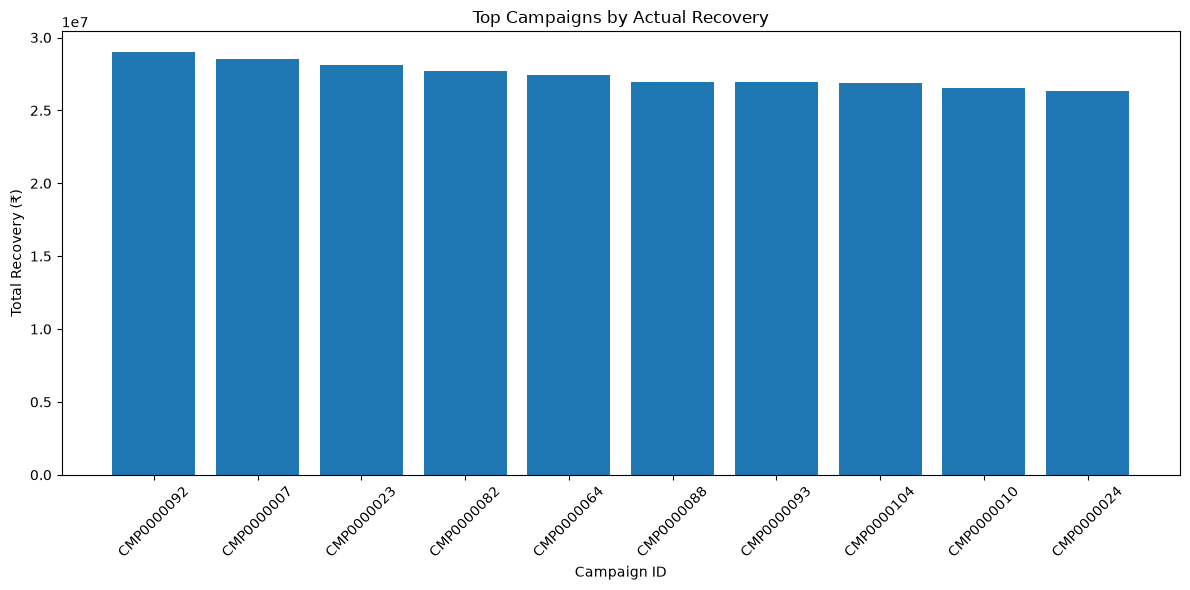

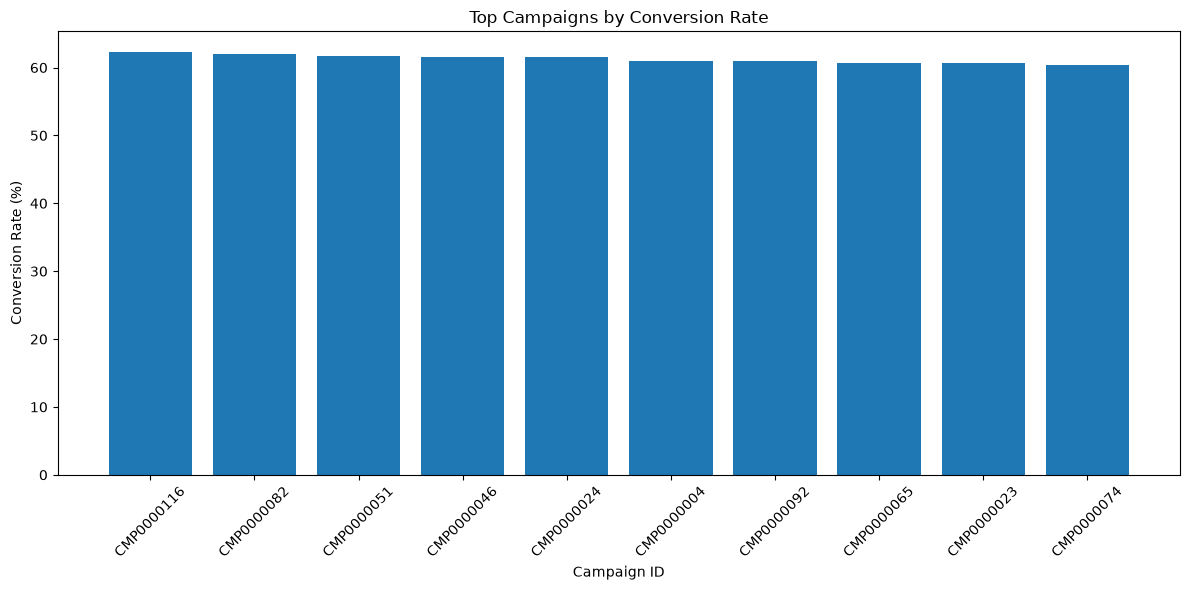

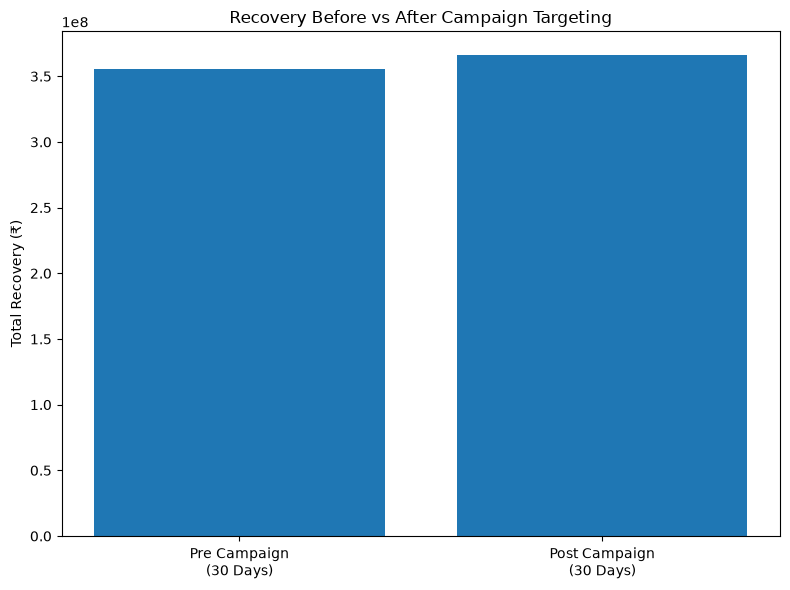

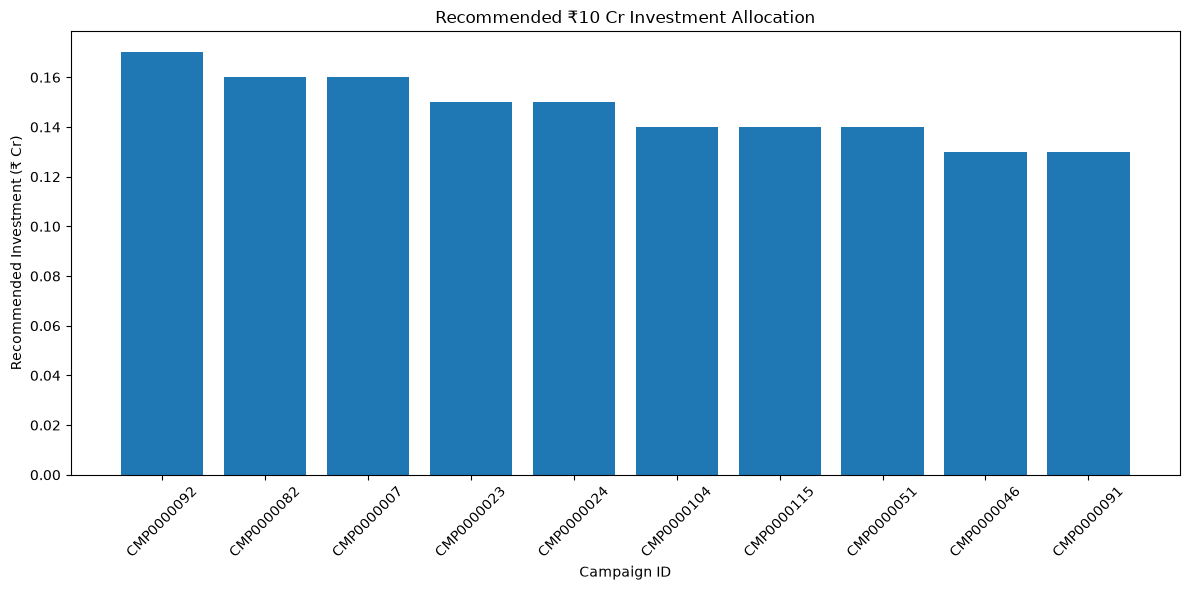

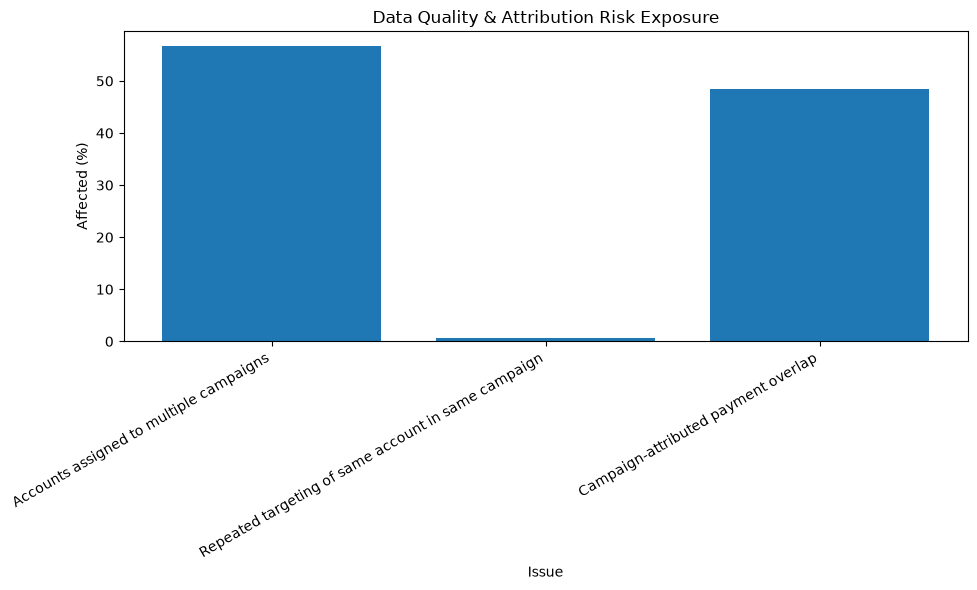

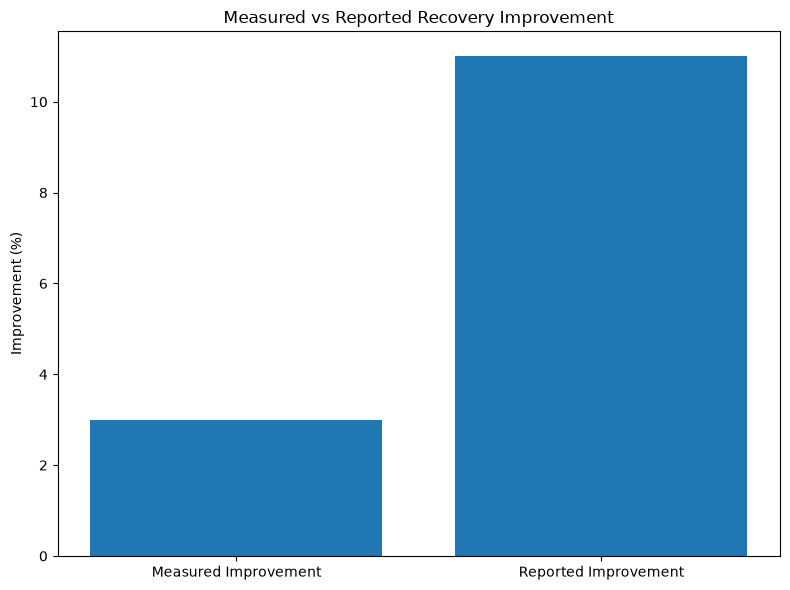


ALL EXECUTIVE CHARTS GENERATED SUCCESSFULLY


In [117]:
# ============================================================
# FAST-TRACK BLOCK 5
# EXECUTIVE VISUALIZATIONS
# ============================================================

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print("=" * 100)
print("FAST-TRACK BLOCK 5 - EXECUTIVE VISUALIZATIONS")
print("=" * 100)


# ============================================================
# 1. TOP CAMPAIGNS BY ACTUAL RECOVERY
# ============================================================

plot_df = (
    campaign_performance
    .sort_values(
        "total_recovered",
        ascending=False
    )
    .head(10)
    .copy()
)

plt.figure(figsize=(12, 6))

plt.bar(
    plot_df["campaign_id"].astype(str),
    plot_df["total_recovered"]
)

plt.title(
    "Top Campaigns by Actual Recovery"
)

plt.xlabel("Campaign ID")

plt.ylabel("Total Recovery (₹)")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()


# ============================================================
# 2. CAMPAIGN CONVERSION RATE
# ============================================================

plot_df = (
    campaign_performance
    .sort_values(
        "conversion_rate_pct",
        ascending=False
    )
    .head(10)
    .copy()
)

plt.figure(figsize=(12, 6))

plt.bar(
    plot_df["campaign_id"].astype(str),
    plot_df["conversion_rate_pct"]
)

plt.title(
    "Top Campaigns by Conversion Rate"
)

plt.xlabel("Campaign ID")

plt.ylabel("Conversion Rate (%)")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()


# ============================================================
# 3. PRE VS POST RECOVERY
# ============================================================

plt.figure(figsize=(8, 6))

comparison_labels = [
    "Pre Campaign\n(30 Days)",
    "Post Campaign\n(30 Days)"
]

comparison_values = [
    total_pre,
    total_post
]

plt.bar(
    comparison_labels,
    comparison_values
)

plt.title(
    "Recovery Before vs After Campaign Targeting"
)

plt.ylabel(
    "Total Recovery (₹)"
)

plt.tight_layout()

plt.show()


# ============================================================
# 4. TOP CAMPAIGNS - INVESTMENT ALLOCATION
# ============================================================

investment_plot = (
    final_investment_table
    .sort_values(
        "recommended_investment_cr",
        ascending=False
    )
    .head(10)
    .copy()
)

plt.figure(figsize=(12, 6))

plt.bar(
    investment_plot[
        "campaign_id"
    ].astype(str),

    investment_plot[
        "recommended_investment_cr"
    ]
)

plt.title(
    "Recommended ₹10 Cr Investment Allocation"
)

plt.xlabel(
    "Campaign ID"
)

plt.ylabel(
    "Recommended Investment (₹ Cr)"
)

plt.xticks(
    rotation=45
)

plt.tight_layout()

plt.show()


# ============================================================
# 5. DATA QUALITY RISK
# ============================================================

quality_plot = (
    data_quality_summary
    .copy()
)

plt.figure(figsize=(10, 6))

plt.bar(
    quality_plot[
        "issue"
    ],

    quality_plot[
        "affected_pct"
    ]
)

plt.title(
    "Data Quality & Attribution Risk Exposure"
)

plt.xlabel(
    "Issue"
)

plt.ylabel(
    "Affected (%)"
)

plt.xticks(
    rotation=30,
    ha="right"
)

plt.tight_layout()

plt.show()


# ============================================================
# 6. FINAL 11% VALIDATION VISUAL
# ============================================================

validation_plot = pd.DataFrame({

    "Metric": [
        "Measured Improvement",
        "Reported Improvement"
    ],

    "Improvement (%)": [
        overall_improvement_pct,
        11.0
    ]
})


plt.figure(figsize=(8, 6))

plt.bar(
    validation_plot[
        "Metric"
    ],

    validation_plot[
        "Improvement (%)"
    ]
)

plt.title(
    "Measured vs Reported Recovery Improvement"
)

plt.ylabel(
    "Improvement (%)"
)

plt.tight_layout()

plt.show()


print("\n" + "=" * 100)
print("ALL EXECUTIVE CHARTS GENERATED SUCCESSFULLY")
print("=" * 100)

In [118]:
# ============================================================
# FAST-TRACK BLOCK 6
# SAVE FINAL ANALYSIS OUTPUTS
# ============================================================

from pathlib import Path

# Create output directory
output_dir = Path("../reports/final_outputs")
output_dir.mkdir(
    parents=True,
    exist_ok=True
)


# ------------------------------------------------------------
# 1. SAVE CAMPAIGN PERFORMANCE
# ------------------------------------------------------------

campaign_performance.to_csv(
    output_dir / "campaign_performance.csv",
    index=False
)


# ------------------------------------------------------------
# 2. SAVE 11% VALIDATION
# ------------------------------------------------------------

validation_summary.to_csv(
    output_dir / "improvement_validation.csv",
    index=False
)


# ------------------------------------------------------------
# 3. SAVE CAMPAIGN PRE VS POST RESULTS
# ------------------------------------------------------------

campaign_pre_post.to_csv(
    output_dir / "campaign_pre_post_performance.csv",
    index=False
)


# ------------------------------------------------------------
# 4. SAVE DATA QUALITY ANALYSIS
# ------------------------------------------------------------

data_quality_summary.to_csv(
    output_dir / "data_quality_summary.csv",
    index=False
)


# ------------------------------------------------------------
# 5. SAVE ₹10 CR INVESTMENT RECOMMENDATION
# ------------------------------------------------------------

final_investment_table.to_csv(
    output_dir / "investment_recommendation.csv",
    index=False
)


# ------------------------------------------------------------
# 6. SAVE EXECUTIVE METRICS
# ------------------------------------------------------------

executive_metrics.to_csv(
    output_dir / "executive_metrics.csv",
    index=False
)


# ------------------------------------------------------------
# 7. SAVE ACTUAL CLEAN PAYMENTS
# ------------------------------------------------------------

clean_payments.to_csv(
    output_dir / "clean_payments.csv",
    index=False
)


# ------------------------------------------------------------
# FINAL CHECK
# ------------------------------------------------------------

print("=" * 80)
print("FINAL OUTPUT FILES SAVED SUCCESSFULLY")
print("=" * 80)

for file in sorted(output_dir.glob("*")):
    print(file.name)

FINAL OUTPUT FILES SAVED SUCCESSFULLY
campaign_performance.csv
campaign_pre_post_performance.csv
clean_payments.csv
data_quality_summary.csv
executive_metrics.csv
improvement_validation.csv
investment_recommendation.csv


In [119]:
# ============================================================
# GOLDEN DATASET CREATION
# ============================================================

from pathlib import Path
import pandas as pd
import numpy as np

print("=" * 100)
print("BUILDING GOLDEN DATASETS")
print("=" * 100)


# ------------------------------------------------------------
# 1. CREATE GOLDEN DIRECTORY
# ------------------------------------------------------------

golden_dir = Path("../data/golden")

golden_dir.mkdir(
    parents=True,
    exist_ok=True
)


# ------------------------------------------------------------
# 2. ACCOUNT-LEVEL RECOVERY DATASET
# ------------------------------------------------------------

golden_account_recovery = (
    account_recovery
    .copy()
)

golden_account_recovery.to_csv(
    golden_dir / "golden_account_recovery.csv",
    index=False
)


# ------------------------------------------------------------
# 3. CLEAN PAYMENT EVENTS
# ------------------------------------------------------------

golden_payments = (
    clean_payments
    .copy()
)

golden_payments.to_csv(
    golden_dir / "golden_payments.csv",
    index=False
)


# ------------------------------------------------------------
# 4. CAMPAIGN PERFORMANCE DATASET
# ------------------------------------------------------------

golden_campaign_performance = (
    campaign_performance
    .copy()
)

golden_campaign_performance.to_csv(
    golden_dir / "golden_campaign_performance.csv",
    index=False
)


# ------------------------------------------------------------
# 5. PRE VS POST CAMPAIGN PERFORMANCE
# ------------------------------------------------------------

golden_campaign_pre_post = (
    campaign_pre_post
    .copy()
)

golden_campaign_pre_post.to_csv(
    golden_dir / "golden_campaign_pre_post.csv",
    index=False
)


# ------------------------------------------------------------
# 6. INVESTMENT RECOMMENDATION
# ------------------------------------------------------------

golden_investment_recommendation = (
    final_investment_table
    .copy()
)

golden_investment_recommendation.to_csv(
    golden_dir / "golden_investment_recommendation.csv",
    index=False
)


# ------------------------------------------------------------
# 7. DATA QUALITY SUMMARY
# ------------------------------------------------------------

golden_data_quality = (
    data_quality_summary
    .copy()
)

golden_data_quality.to_csv(
    golden_dir / "golden_data_quality_summary.csv",
    index=False
)


# ------------------------------------------------------------
# 8. EXECUTIVE METRICS
# ------------------------------------------------------------

golden_executive_metrics = (
    executive_metrics
    .copy()
)

golden_executive_metrics.to_csv(
    golden_dir / "golden_executive_metrics.csv",
    index=False
)


# ------------------------------------------------------------
# 9. CREATE DATASET CATALOG
# ------------------------------------------------------------

dataset_catalog = pd.DataFrame({

    "dataset": [
        "golden_account_recovery",
        "golden_payments",
        "golden_campaign_performance",
        "golden_campaign_pre_post",
        "golden_investment_recommendation",
        "golden_data_quality_summary",
        "golden_executive_metrics"
    ],

    "grain": [
        "One row per paying account",
        "One row per valid payment event",
        "One row per campaign",
        "One row per campaign",
        "One row per campaign",
        "One row per data quality issue",
        "One row per executive metric"
    ],

    "purpose": [
        "Actual account-level recovery analysis",
        "Clean source of payment truth",
        "Campaign recovery and conversion performance",
        "Before vs after improvement validation",
        "₹10 Cr allocation recommendation",
        "Attribution and data quality risks",
        "Executive-level KPI reporting"
    ]
})


dataset_catalog.to_csv(
    golden_dir / "golden_dataset_catalog.csv",
    index=False
)


# ------------------------------------------------------------
# 10. FINAL VALIDATION
# ------------------------------------------------------------

print("\nGolden datasets created:\n")

for file in sorted(golden_dir.glob("*.csv")):
    
    file_df = pd.read_csv(file)
    
    print(
        f"✓ {file.name}"
        f" → {file_df.shape[0]:,} rows × "
        f"{file_df.shape[1]} columns"
    )


print("\n" + "=" * 100)
print("GOLDEN DATASET PIPELINE COMPLETED SUCCESSFULLY")
print("=" * 100)

BUILDING GOLDEN DATASETS

Golden datasets created:

✓ golden_account_recovery.csv → 16,934 rows × 5 columns
✓ golden_campaign_performance.csv → 120 rows × 7 columns
✓ golden_campaign_pre_post.csv → 120 rows × 6 columns
✓ golden_data_quality_summary.csv → 3 rows × 5 columns
✓ golden_dataset_catalog.csv → 7 rows × 3 columns
✓ golden_executive_metrics.csv → 11 rows × 2 columns
✓ golden_investment_recommendation.csv → 120 rows × 9 columns
✓ golden_payments.csv → 25,000 rows × 3 columns

GOLDEN DATASET PIPELINE COMPLETED SUCCESSFULLY


In [120]:
# ============================================================
# FINAL DATA QUALITY REPORT
# ============================================================

from pathlib import Path

dq_report = data_quality_summary.copy()


# ------------------------------------------------------------
# ADD RECOMMENDED ACTION
# ------------------------------------------------------------

action_mapping = {

    "Accounts assigned to multiple campaigns":
        (
            "Implement deterministic attribution. "
            "Each payment should be assigned to one campaign "
            "using a defined attribution window and priority rule."
        ),

    "Repeated targeting of same account in same campaign":
        (
            "Deduplicate repeated targeting records or explicitly "
            "track exposure frequency separately."
        ),

    "Campaign-attributed payment overlap":
        (
            "Do not sum campaign recovery as total business recovery. "
            "Use unique account-level payments as the source of truth."
        )
}


dq_report["recommended_action"] = (
    dq_report["issue"]
    .map(action_mapping)
    .fillna(
        "Investigate root cause and implement automated validation."
    )
)


# ------------------------------------------------------------
# SORT BY RISK
# ------------------------------------------------------------

risk_order = {
    "HIGH": 1,
    "MEDIUM": 2,
    "LOW": 3
}


dq_report["risk_order"] = (
    dq_report["risk"]
    .map(risk_order)
)


dq_report = (
    dq_report
    .sort_values("risk_order")
    .drop(columns="risk_order")
    .reset_index(drop=True)
)


# ------------------------------------------------------------
# SAVE FINAL REPORT
# ------------------------------------------------------------

reports_dir = Path("../reports")

reports_dir.mkdir(
    parents=True,
    exist_ok=True
)


dq_report.to_csv(
    reports_dir / "data_quality_report.csv",
    index=False
)


# ------------------------------------------------------------
# DISPLAY
# ------------------------------------------------------------

print("=" * 100)
print("FINAL DATA QUALITY REPORT")
print("=" * 100)

display(dq_report)

print("\nSaved successfully:")
print("../reports/data_quality_report.csv")

FINAL DATA QUALITY REPORT


,issue,affected_count,affected_pct,risk,impact,recommended_action
0,Accounts assigned to multiple campaigns,1.323500e+04,56.695511,HIGH,Same payment may be attributed to multiple cam...,Implement deterministic attribution. Each paym...
1,Campaign-attributed payment overlap,9.121659e+08,48.548070,HIGH,If campaign-attributed recovery exceeds actual...,Do not sum campaign recovery as total business...
2,Repeated targeting of same account in same cam...,2.820000e+02,0.630661,MEDIUM,Repeated exposure makes a simple before/after ...,Deduplicate repeated targeting records or expl...



Saved successfully:
../reports/data_quality_report.csv


In [121]:
# ============================================================
# FINAL NUMBERS FOR EXECUTIVE MEMO
# ============================================================

print("=" * 100)
print("FINAL NUMBERS FOR EXECUTIVE MEMO")
print("=" * 100)


# ------------------------------------------------------------
# 1. EXECUTIVE METRICS
# ------------------------------------------------------------

print("\nEXECUTIVE METRICS:")
display(executive_metrics)


# ------------------------------------------------------------
# 2. IMPROVEMENT VALIDATION
# ------------------------------------------------------------

print("\n11% IMPROVEMENT VALIDATION:")
display(validation_summary)


# ------------------------------------------------------------
# 3. TOP CAMPAIGNS
# ------------------------------------------------------------

print("\nTOP 10 CAMPAIGNS BY RECOVERY:")

display(
    campaign_performance
    .sort_values(
        "total_recovered",
        ascending=False
    )
    .head(10)
)


# ------------------------------------------------------------
# 4. INVESTMENT RECOMMENDATION
# ------------------------------------------------------------

print("\n₹10 CR INVESTMENT RECOMMENDATION:")

display(
    final_investment_table
    .sort_values(
        "recommended_investment_cr",
        ascending=False
    )
    .head(10)
)


# ------------------------------------------------------------
# 5. DATA QUALITY RISKS
# ------------------------------------------------------------

print("\nDATA QUALITY RISKS:")

display(
    data_quality_summary
)


print("\n" + "=" * 100)
print("COPY / SCREENSHOT THESE RESULTS FOR THE FINAL MEMO")
print("=" * 100)

FINAL NUMBERS FOR EXECUTIVE MEMO

EXECUTIVE METRICS:


,metric,value
0,Total accounts targeted,2.334400e+04
1,Total actual recovery,1.878892e+09
2,Campaign-attributed recovery,2.791058e+09
3,Recovery inflation ratio,1.485481e+00
4,Measured improvement (%),2.986552e+00
5,Reported improvement (%),1.100000e+01
6,Accounts in multiple campaigns,1.323500e+04
7,Multiple campaign assignment (%),5.669551e+01
8,Repeat targeting relationships,2.820000e+02
9,Repeat targeting (%),6.306609e-01



11% IMPROVEMENT VALIDATION:


,metric,value
0,Total recovery - 30 days before,3.553049e+08
1,Total recovery - 30 days after,3.659163e+08
2,Absolute recovery uplift,1.061137e+07
3,Measured improvement (%),2.986552e+00
4,Reported improvement (%),1.100000e+01
5,Difference from reported claim (percentage poi...,-8.013448e+00
6,Accounts analysed,6.579000e+03



TOP 10 CAMPAIGNS BY RECOVERY:


...


₹10 CR INVESTMENT RECOMMENDATION:


,campaign_id,targeted_accounts,paying_accounts,conversion_rate_pct,total_recovered,avg_recovery_per_target,investment_score,priority,recommended_investment_cr
0,CMP0000092,392,239,60.969388,28976009.23,73918.390893,0.934944,HIGH,0.17
2,CMP0000082,402,249,61.940299,27676884.27,68847.970821,0.864409,HIGH,0.16
1,CMP0000007,380,228,60.000000,28503414.58,75008.985737,0.903772,HIGH,0.16
3,CMP0000023,417,253,60.671463,28106731.28,67402.233285,0.803326,HIGH,0.15
4,CMP0000024,390,240,61.538462,26313490.18,67470.487641,0.796638,HIGH,0.15
5,CMP0000104,365,211,57.808219,26883718.03,73654.022000,0.761867,HIGH,0.14
6,CMP0000115,358,211,58.938547,25869310.14,72260.642849,0.760567,HIGH,0.14
7,CMP0000051,384,237,61.718750,25071278.69,65289.788255,0.741586,HIGH,0.14
14,CMP0000046,385,237,61.558442,24665841.88,64067.121766,0.707350,HIGH,0.13
17,CMP0000091,377,224,59.416446,25319224.12,67159.745676,0.687778,HIGH,0.13



DATA QUALITY RISKS:


,issue,affected_count,affected_pct,risk,impact
0,Accounts assigned to multiple campaigns,1.323500e+04,56.695511,HIGH,Same payment may be attributed to multiple cam...
1,Repeated targeting of same account in same cam...,2.820000e+02,0.630661,MEDIUM,Repeated exposure makes a simple before/after ...
2,Campaign-attributed payment overlap,9.121659e+08,48.548070,HIGH,If campaign-attributed recovery exceeds actual...



COPY / SCREENSHOT THESE RESULTS FOR THE FINAL MEMO
